# COS40007 Artificial Intelligence for Engineering

## Design Project  
### Theme 3: Smart Government - State-Level School Completion Rate Prediction Using Random Forest Regression

**Student Name:** Samuel Chang Hao Jun  
**Student ID:** 102775957

## Appendix A: Generative AI Use Declaration
[Declare your AI tool usage and provide conversation link here.]

## Appendix B: Project Folder Summary

This notebook creates an `outputs` folder during execution. The folder contains audit files, modelling tables, visual evidence, a saved model file, and final summary files generated from the raw CSV datasets.

The project folder is available at this link: [COS40007 Project Folder - add link here]

## Prerequisites

This section sets up the notebook environment, fixed settings, folder paths, and helper utilities used throughout the Random Forest Regression workflow.

#### Environment Setup and Library Imports

This subsection records the runtime setup and imports the libraries used for data checking, preprocessing, Random Forest Regression training, evaluation, visualisation, feature importance checking, and model saving.

In [1]:
from pathlib import Path
import json
import warnings
import joblib
import sys
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
    median_absolute_error,
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:.4f}".format)

plt.rcParams["figure.figsize"] = (8, 5)

environment_versions_df = pd.DataFrame(
    {
        "Component": [
            "Python",
            "Platform",
            "NumPy",
            "pandas",
            "Matplotlib",
            "scikit-learn",
            "joblib",
        ],
        "Version": [
            platform.python_version(),
            platform.platform(),
            np.__version__,
            pd.__version__,
            plt.matplotlib.__version__,
            sklearn.__version__,
            joblib.__version__,
        ],
    }
)

display(environment_versions_df)

print("Environment ready for Random Forest Regression modelling.")

,Component,Version
0,Python,3.12.13
1,Platform,Linux-6.6.122+-x86_64-with-glibc2.35
2,NumPy,2.0.2
3,pandas,2.2.2
4,Matplotlib,3.10.0
5,scikit-learn,1.6.1
6,joblib,1.5.3


Environment ready for Random Forest Regression modelling.


#### Google Drive Access and Project Folder Setup

This subsection mounts Google Drive, defines the project folder, and prepares the raw-data and output folder paths used throughout the notebook.

In [2]:
from google.colab import drive

drive.mount("/content/drive")

PROJECT_FOLDER = "COS40007_Project"

drive_root = Path("/content/drive/MyDrive")
PROJECT_DIR = drive_root / PROJECT_FOLDER
RAW_DATA_DIR = PROJECT_DIR / "raw_data"

OUTPUT_DIR = PROJECT_DIR / "sam" / "outputs"
CHECK_OUTPUT_DIR = OUTPUT_DIR / "checks"
TABLE_OUTPUT_DIR = OUTPUT_DIR / "tables"
FIGURE_OUTPUT_DIR = OUTPUT_DIR / "figures"
MODEL_OUTPUT_DIR = OUTPUT_DIR / "models"
ARTIFACT_OUTPUT_DIR = OUTPUT_DIR / "artifacts"

for output_path in [
    OUTPUT_DIR,
    CHECK_OUTPUT_DIR,
    TABLE_OUTPUT_DIR,
    FIGURE_OUTPUT_DIR,
    MODEL_OUTPUT_DIR,
    ARTIFACT_OUTPUT_DIR,
]:
    output_path.mkdir(parents=True, exist_ok=True)

path_registry_df = pd.DataFrame(
    [
        ("Drive root", drive_root),
        ("Project directory", PROJECT_DIR),
        ("Raw data directory", RAW_DATA_DIR),
        ("Output directory", OUTPUT_DIR),
        ("Check output directory", CHECK_OUTPUT_DIR),
        ("Table output directory", TABLE_OUTPUT_DIR),
        ("Figure output directory", FIGURE_OUTPUT_DIR),
        ("Model output directory", MODEL_OUTPUT_DIR),
        ("Artifact output directory", ARTIFACT_OUTPUT_DIR),
    ],
    columns=["Folder", "Path"],
)

path_registry_df["Exists"] = path_registry_df["Path"].apply(lambda path: path.exists())
path_registry_df["Path"] = path_registry_df["Path"].astype(str)

display(path_registry_df)

print("Google Drive and project folder paths are ready.")

Mounted at /content/drive


,Folder,Path,Exists
0,Drive root,/content/drive/MyDrive,True
1,Project directory,/content/drive/MyDrive/COS40007_Project,True
2,Raw data directory,/content/drive/MyDrive/COS40007_Project/raw_data,False
3,Output directory,/content/drive/MyDrive/COS40007_Project/sam/ou...,True
4,Check output directory,/content/drive/MyDrive/COS40007_Project/sam/ou...,True
5,Table output directory,/content/drive/MyDrive/COS40007_Project/sam/ou...,True
6,Figure output directory,/content/drive/MyDrive/COS40007_Project/sam/ou...,True
7,Model output directory,/content/drive/MyDrive/COS40007_Project/sam/ou...,True
8,Artifact output directory,/content/drive/MyDrive/COS40007_Project/sam/ou...,True


Google Drive and project folder paths are ready.


#### Locked Constants and Reusable Helper Utilities

This subsection defines the fixed raw filenames, target columns, year settings, regression metrics, output filenames, and reusable helper functions used consistently throughout the notebook.

In [3]:
RANDOM_STATE = 42

RAW_CSV_FILENAMES = [
    "completion_school_state.csv",
    "schools_district.csv",
    "enrolment_school_district.csv",
    "teachers_district.csv",
    "fertility_state.csv",
    "population_state.csv",
    "hh_lq_state.csv",
    "hh_income_state.csv",
    "hh_poverty_state.csv",
]

TARGET_COL = "next_year_completion_rate"
SECONDARY_TARGET_COL = "next_year_completion_gap_from_malaysia"
COMPLETION_RATE_COL = "completion_rate"
MALAYSIA_RATE_COL = "malaysia_completion_rate"
GAP_COL = "completion_gap_from_malaysia"
TARGET_DELTA_COL = "target_delta"

TRAIN_INPUT_YEARS = [2017, 2018, 2019, 2020]
TEST_INPUT_YEAR = 2021
FORECAST_CANDIDATE_INPUT_YEAR = 2022

STATE_COL = "state"
STAGE_COL = "stage"
SEX_COL = "sex"
YEAR_COL = "year"
TARGET_YEAR_COL = "target_year"

ACCEPTED_MAIN_SEX_VALUES = ["male", "female"]
REGRESSION_METRIC_NAMES = ["MAE", "RMSE", "R2", "Median_AE"]


def fail_if(condition, message):
    if condition:
        raise ValueError(message)


def save_table(df, path, index=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=index)
    return path


def save_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as file:
        json.dump(data, file, indent=2, ensure_ascii=False)
    return path


def save_plot(path, close=True):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, bbox_inches="tight", dpi=150)
    if close:
        plt.close()
    return path


def clean_text_value(value):
    if pd.isna(value):
        return value
    return str(value).strip().lower().replace("\u00a0", " ")


def require_columns(df, required_cols, df_name):
    missing_cols = [col for col in required_cols if col not in df.columns]
    fail_if(missing_cols, f"{df_name} is missing required columns: {missing_cols}")


def safe_divide(numerator, denominator):
    return np.where(np.asarray(denominator) == 0, np.nan, np.asarray(numerator) / np.asarray(denominator))


def regression_metrics(y_true, y_pred, model_name):
    _ = model_name
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "Median_AE": median_absolute_error(y_true, y_pred),
    }


# Additional visual-evidence helpers.
expanded_visual_records = []


def register_visual_figure(figure_name, filename, source_table, purpose):
    path = FIGURE_OUTPUT_DIR / filename
    save_plot(path, close=False)
    plt.show()
    plt.close()

    expanded_visual_records.append(
        {
            "Figure Name": figure_name,
            "Figure Filename": filename,
            "Full Saved Path": str(path),
            "Source Table": source_table,
            "Purpose": purpose,
        }
    )
    return path


def set_axis_labels(axis, title=None, xlabel=None, ylabel=None):
    if title:
        axis.set_title(title)
    if xlabel:
        axis.set_xlabel(xlabel)
    if ylabel:
        axis.set_ylabel(ylabel)
    return axis


def annotate_bars(axis, decimals=2):
    for patch in axis.patches:
        width = patch.get_width()
        height = patch.get_height()
        if np.isfinite(width):
            axis.text(
                width,
                patch.get_y() + height / 2,
                f" {width:.{decimals}f}",
                va="center",
            )
    return axis


def numeric_heatmap(data, row_labels, col_labels, title, xlabel, ylabel, filename, source_table, purpose, value_format=".2f"):
    matrix = np.asarray(data, dtype=float)
    fig, ax = plt.subplots(figsize=(max(8, 0.7 * len(col_labels)), max(5, 0.35 * len(row_labels))))
    image = ax.imshow(matrix, aspect="auto")
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels(col_labels, rotation=45, ha="right")
    ax.set_yticklabels(row_labels)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    fig.colorbar(image, ax=ax)

    if matrix.size <= 180:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                if np.isfinite(matrix[i, j]):
                    ax.text(j, i, format(matrix[i, j], value_format), ha="center", va="center", fontsize=8)

    register_visual_figure(title, filename, source_table, purpose)
    return fig, ax


modelling_constants_df = pd.DataFrame(
    {
        "Item": [
            "Target",
            "Secondary target",
            "Training input years",
            "Test input year",
            "Forecast-candidate input year",
            "Regression metrics",
        ],
        "Value": [
            TARGET_COL,
            SECONDARY_TARGET_COL,
            TRAIN_INPUT_YEARS,
            TEST_INPUT_YEAR,
            FORECAST_CANDIDATE_INPUT_YEAR,
            REGRESSION_METRIC_NAMES,
        ],
    }
)

display(modelling_constants_df)

print("Locked constants and reusable helper utilities are ready.")

,Item,Value
0,Target,next_year_completion_rate
1,Secondary target,next_year_completion_gap_from_malaysia
2,Training input years,"[2017, 2018, 2019, 2020]"
3,Test input year,2021
4,Forecast-candidate input year,2022
5,Regression metrics,"[MAE, RMSE, R2, Median_AE]"


Locked constants and reusable helper utilities are ready.


## Objective

This notebook develops a Random Forest Regression workflow for state-level next-year school completion-rate prediction using Malaysian public-sector datasets. The modelling target is `next_year_completion_rate`, which is a numeric regression target.

The workflow starts from the shared preprocessed panel, evaluates baseline methods, trains and tunes Random Forest candidates using chronological validation, and evaluates the selected model on a held-out future-year test set.

The notebook also produces practical error diagnostics, grouped error analysis, model-comparison visualisations, feature-importance evidence, a representative prediction demonstrator, and a forecast preview for rows where the next-year target is unavailable.

Main modelling contract:

```text
Main target: next_year_completion_rate
Secondary policy context: next_year_completion_gap_from_malaysia
Model: Random Forest Regression (ensemble of decision trees)
Main row unit: state-stage-sex-year using male and female rows
Aggregate check: both-only rows are kept separate from the main model
Metrics: MAE, RMSE, R², median absolute error, residual direction, and tolerance coverage
Validation: chronological validation and held-out future-year testing
Comparison methods: mean baseline, persistence baseline, historical baselines, recent-history baselines, and Ridge Regression
```

## Step 1 - Project Scope and Supervised Regression Framing

### Step 1.1 - Smart Government Education-Planning Context

In [4]:
project_context_df = pd.DataFrame(
    [
        ("Theme", "Smart Government"),
        ("Public-sector data source type", "Malaysia public-sector open datasets"),
        ("Analytical objective", "Predict state-level school completion outcomes for planning support"),
        ("Supervised learning task", "Regression"),
        ("Main prediction target", TARGET_COL),
        ("Secondary policy context", SECONDARY_TARGET_COL),
        ("Row-unit direction", "State, school stage, sex, and input year"),
        ("Model family", "Random Forest Regression"),
        ("Evaluation direction", "Lower MAE/RMSE/Median_AE and higher R2 indicate better predictive fit"),
        ("Policy relevance", "Identify completion-rate pressure patterns for education planning review"),
    ],
    columns=["Context Item", "Notebook Evidence"],
)

display(project_context_df)
print("Smart Government context is ready.")

,Context Item,Notebook Evidence
0,Theme,Smart Government
1,Public-sector data source type,Malaysia public-sector open datasets
2,Analytical objective,Predict state-level school completion outcomes...
3,Supervised learning task,Regression
4,Main prediction target,next_year_completion_rate
5,Secondary policy context,next_year_completion_gap_from_malaysia
6,Row-unit direction,"State, school stage, sex, and input year"
7,Model family,Random Forest Regression
8,Evaluation direction,Lower MAE/RMSE/Median_AE and higher R2 indicat...
9,Policy relevance,Identify completion-rate pressure patterns for...


Smart Government context is ready.


### Step 1.2 - Supervised Regression Framing

In [5]:
supervised_regression_framing_df = pd.DataFrame(
    [
        ("Learning task", "Supervised regression"),
        ("Target type", "Numeric school completion-rate prediction"),
        ("Main target", TARGET_COL),
        ("Secondary policy context", SECONDARY_TARGET_COL),
        ("Why Random Forest", "Ensemble tree method; handles non-linear relationships, small data, mixed features; provides native feature importance"),
        ("Why not classification", "Target is a continuous percentage value, not a discrete label"),
        ("Comparison notebook", "Alex Zechariah SVR notebook uses identical row unit, target, split design, and metric set for direct comparison"),
    ],
    columns=["Framing Item", "Notebook Evidence"],
)

display(supervised_regression_framing_df)
print("Supervised regression framing is ready.")

,Framing Item,Notebook Evidence
0,Learning task,Supervised regression
1,Target type,Numeric school completion-rate prediction
2,Main target,next_year_completion_rate
3,Secondary policy context,next_year_completion_gap_from_malaysia
4,Why Random Forest,Ensemble tree method; handles non-linear relat...
5,Why not classification,"Target is a continuous percentage value, not a..."
6,Comparison notebook,Alex Zechariah SVR notebook uses identical row...


Supervised regression framing is ready.


## Step 2 - Shared Panel Loading

This step loads the preprocessed supervised modelling panel shared by the group. The panel was constructed from the nine raw Malaysian public-sector datasets and contains all feature engineering already applied.

### Step 2.1 - Load Shared Preprocessed Panel

In [6]:
# ── Step 2.1: Build supervised modelling panel from raw CSVs ──

RAW_DATA_DIR = Path("/content/drive/MyDrive/raw_data")
fail_if(not RAW_DATA_DIR.exists(), f"Raw data folder not found: {RAW_DATA_DIR}")

# ── Load all raw CSVs ──
raw_dfs = {}
for filename in RAW_CSV_FILENAMES:
    path = RAW_DATA_DIR / filename
    fail_if(not path.exists(), f"Missing raw file: {path}")
    key = Path(filename).stem
    raw_dfs[key] = pd.read_csv(path)
    print(f"Loaded {key}: {raw_dfs[key].shape}")

# ── Completion: base panel ──
completion = raw_dfs["completion_school_state"].copy()
completion["year"] = pd.to_datetime(completion["date"]).dt.year
completion = completion.drop(columns=["date"]).rename(columns={"completion": "completion_rate"})

states_only = completion[completion["state"] != "Malaysia"].copy()
main_sex = states_only[states_only["sex"].isin(ACCEPTED_MAIN_SEX_VALUES)].copy()

malaysia_benchmark = completion[
    (completion["state"] == "Malaysia") & (completion["sex"] == "both")
].copy()
malaysia_benchmark = malaysia_benchmark.rename(
    columns={"completion_rate": "malaysia_completion_rate"}
)[["stage", "year", "malaysia_completion_rate"]]

panel = main_sex.merge(malaysia_benchmark, on=["stage", "year"], how="left")
panel["completion_gap_from_malaysia"] = panel["completion_rate"] - panel["malaysia_completion_rate"]
panel = panel.sort_values(["state", "stage", "sex", "year"]).reset_index(drop=True)

# ── Target construction ──
panel[TARGET_COL] = panel.groupby(["state", "stage", "sex"])["completion_rate"].shift(-1)
panel[SECONDARY_TARGET_COL] = panel.groupby(["state", "stage", "sex"])["completion_gap_from_malaysia"].shift(-1)
panel[TARGET_YEAR_COL] = panel["year"] + 1
panel[TARGET_DELTA_COL] = panel[TARGET_COL] - panel["completion_rate"]

# ── Autoregressive lag and rolling features ──
panel["lag1_completion_rate"] = panel.groupby(["state", "stage", "sex"])["completion_rate"].shift(1)
panel["lag1_completion_gap_from_malaysia"] = panel.groupby(["state", "stage", "sex"])["completion_gap_from_malaysia"].shift(1)
panel["completion_rate_change_1y"] = panel["completion_rate"] - panel["lag1_completion_rate"]
panel["gap_change_1y"] = panel["completion_gap_from_malaysia"] - panel["lag1_completion_gap_from_malaysia"]
panel["rolling2_completion_mean"] = panel.groupby(["state", "stage", "sex"])["completion_rate"].transform(
    lambda x: x.shift(1).rolling(2).mean()
)
panel["rolling2_gap_mean"] = panel.groupby(["state", "stage", "sex"])["completion_gap_from_malaysia"].transform(
    lambda x: x.shift(1).rolling(2).mean()
)

# ── Education capacity features (state-level aggregate) ──
schools = raw_dfs["schools_district"].copy()
schools["year"] = pd.to_datetime(schools["date"]).dt.year
schools = (
    schools[schools["district"] == "All Districts"]
    .groupby(["state", "stage", "year"])["schools"]
    .sum().reset_index().rename(columns={"schools": "schools_total"})
)

enrolment = raw_dfs["enrolment_school_district"].copy()
enrolment["year"] = pd.to_datetime(enrolment["date"]).dt.year
enrolment = (
    enrolment[(enrolment["district"] == "All Districts") & (enrolment["sex"] == "both")]
    .groupby(["state", "stage", "year"])["students"]
    .sum().reset_index().rename(columns={"students": "students_total"})
)

teachers = raw_dfs["teachers_district"].copy()
teachers["year"] = pd.to_datetime(teachers["date"]).dt.year
teachers = (
    teachers[(teachers["district"] == "All Districts") & (teachers["sex"] == "both")]
    .groupby(["state", "stage", "year"])["teachers"]
    .sum().reset_index().rename(columns={"teachers": "teachers_total"})
)

edu = (
    schools
    .merge(enrolment, on=["state", "stage", "year"], how="outer")
    .merge(teachers, on=["state", "stage", "year"], how="outer")
)
edu["students_per_teacher"] = edu["students_total"] / edu["teachers_total"]
edu["students_per_school"] = edu["students_total"] / edu["schools_total"]
edu["teachers_per_school"] = edu["teachers_total"] / edu["schools_total"]
edu["schools_growth_1y"] = edu.groupby(["state", "stage"])["schools_total"].pct_change()
edu["students_growth_1y"] = edu.groupby(["state", "stage"])["students_total"].pct_change()
edu["teachers_growth_1y"] = edu.groupby(["state", "stage"])["teachers_total"].pct_change()

panel = panel.merge(edu, on=["state", "stage", "year"], how="left")

# ── Fertility (TFR only) ──
fertility = raw_dfs["fertility_state"].copy()
fertility["year"] = pd.to_datetime(fertility["date"]).dt.year
tfr = (
    fertility[fertility["age_group"] == "tfr"]
    [["state", "year", "fertility_rate"]]
    .rename(columns={"fertility_rate": "tfr"})
)
panel = panel.merge(tfr, on=["state", "year"], how="left")

# ── Population features ──
population = raw_dfs["population_state"].copy()
population["year"] = pd.to_datetime(population["date"]).dt.year

total_pop = population[
    (population["sex"] == "both") &
    (population["age"] == "overall") &
    (population["ethnicity"] == "overall")
][["state", "year", "population"]].rename(columns={"population": "total_state_population"})

sex_pop = population[
    (population["age"] == "overall") &
    (population["ethnicity"] == "overall") &
    (population["sex"].isin(ACCEPTED_MAIN_SEX_VALUES))
][["state", "year", "sex", "population"]].rename(columns={"population": "same_sex_total_population"})

school_age_pop = (
    population[
        (population["age"].isin(["5-9", "10-14", "15-19"])) &
        (population["ethnicity"] == "overall") &
        (population["sex"].isin(ACCEPTED_MAIN_SEX_VALUES))
    ]
    .groupby(["state", "year", "sex"])["population"]
    .sum().reset_index()
    .rename(columns={"population": "same_sex_school_age_population"})
)

panel = panel.merge(total_pop, on=["state", "year"], how="left")
panel = panel.merge(sex_pop, on=["state", "year", "sex"], how="left")
panel = panel.merge(school_age_pop, on=["state", "year", "sex"], how="left")
panel["same_sex_school_age_share"] = panel["same_sex_school_age_population"] / panel["total_state_population"]
panel["log_population_total"] = np.log1p(panel["total_state_population"])

wp_states = ["w.p. kuala lumpur", "w.p. putrajaya", "w.p. labuan"]
small_pop_states = ["perlis", "w.p. putrajaya", "w.p. labuan"]
panel["is_federal_territory"] = panel["state"].str.lower().isin(wp_states).astype(int)
panel["is_small_population_state"] = panel["state"].str.lower().isin(small_pop_states).astype(int)

# ── Household features ──
hh = raw_dfs["hh_lq_state"].copy()
hh["year"] = pd.to_datetime(hh["date"]).dt.year
hh = hh[["state", "year", "households", "living_quarters"]].copy()
hh["households_per_living_quarter"] = hh["households"] / hh["living_quarters"]
hh["living_quarters_per_household"] = hh["living_quarters"] / hh["households"]
hh["log_households"] = np.log1p(hh["households"])
panel = panel.merge(hh, on=["state", "year"], how="left")

# ── Income and poverty (forward-fill sparse survey years) ──
all_years = sorted(panel["year"].unique())
all_states = sorted(panel["state"].unique())

def ffill_sparse(sparse_df, value_cols, all_states, all_years):
    full_idx = pd.MultiIndex.from_product([all_states, all_years], names=["state", "year"])
    full_df = pd.DataFrame(index=full_idx).reset_index()
    merged = full_df.merge(sparse_df, on=["state", "year"], how="left")
    merged = merged.sort_values(["state", "year"])
    merged[value_cols] = merged.groupby("state")[value_cols].ffill()
    return merged

income = raw_dfs["hh_income_state"].copy()
income["year"] = pd.to_datetime(income["date"]).dt.year
income = income[["state", "year", "income_mean", "income_median"]]
income_filled = ffill_sparse(income, ["income_mean", "income_median"], all_states, all_years)
income_filled["income_data_age"] = income_filled.groupby("state").cumcount()

poverty = raw_dfs["hh_poverty_state"].copy()
poverty["year"] = pd.to_datetime(poverty["date"]).dt.year
poverty = poverty[["state", "year", "poverty_absolute", "poverty_hardcore", "poverty_relative"]]
poverty_filled = ffill_sparse(poverty, ["poverty_absolute", "poverty_hardcore", "poverty_relative"], all_states, all_years)
poverty_filled["poverty_data_age"] = poverty_filled.groupby("state").cumcount()

panel = panel.merge(income_filled, on=["state", "year"], how="left")
panel = panel.merge(poverty_filled, on=["state", "year"], how="left")

# ── Rename year column to match constants ──
panel = panel.rename(columns={"year": YEAR_COL})

supervised_modelling_panel_df = panel.copy()

# ── Audit ──
panel_load_audit_df = pd.DataFrame(
    [
        ("Raw data dir", str(RAW_DATA_DIR)),
        ("Row count", len(supervised_modelling_panel_df)),
        ("Column count", supervised_modelling_panel_df.shape[1]),
        ("Target column present", TARGET_COL in supervised_modelling_panel_df.columns),
        ("Year column present", YEAR_COL in supervised_modelling_panel_df.columns),
        ("State column present", STATE_COL in supervised_modelling_panel_df.columns),
        ("Years covered", str(sorted(supervised_modelling_panel_df[YEAR_COL].unique().tolist()))),
        ("Target missing rows (2022)", int(supervised_modelling_panel_df[TARGET_COL].isna().sum())),
    ],
    columns=["Check", "Value"],
)

save_table(supervised_modelling_panel_df, TABLE_OUTPUT_DIR / "supervised_modelling_panel.csv")
display(panel_load_audit_df)
display(supervised_modelling_panel_df.head(5))
print("Supervised modelling panel built successfully.")

Loaded completion_school_state: (1071, 5)
Loaded schools_district: (2993, 6)
Loaded enrolment_school_district: (8465, 6)
Loaded teachers_district: (5917, 6)
Loaded fertility_state: (2872, 4)
Loaded population_state: (263679, 6)
Loaded hh_lq_state: (297, 4)
Loaded hh_income_state: (303, 4)
Loaded hh_poverty_state: (294, 5)


,Check,Value
0,Raw data dir,/content/drive/MyDrive/raw_data
1,Row count,672
2,Column count,46
3,Target column present,True
4,Year column present,True
5,State column present,True
6,Years covered,"[2016, 2017, 2018, 2019, 2020, 2021, 2022]"
7,Target missing rows (2022),96


,state,stage,sex,completion_rate,year,malaysia_completion_rate,completion_gap_from_malaysia,next_year_completion_rate,next_year_completion_gap_from_malaysia,target_year,target_delta,lag1_completion_rate,lag1_completion_gap_from_malaysia,completion_rate_change_1y,gap_change_1y,rolling2_completion_mean,rolling2_gap_mean,schools_total,students_total,teachers_total,students_per_teacher,students_per_school,teachers_per_school,schools_growth_1y,students_growth_1y,teachers_growth_1y,tfr,total_state_population,same_sex_total_population,same_sex_school_age_population,same_sex_school_age_share,log_population_total,is_federal_territory,is_small_population_state,households,living_quarters,households_per_living_quarter,living_quarters_per_household,log_households,income_mean,income_median,income_data_age,poverty_absolute,poverty_hardcore,poverty_relative,poverty_data_age
0,Johor,primary,female,99.4800,2016,98.3700,1.1100,99.7100,1.6400,2017,0.2300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0900,3651.8000,1720.7000,438.7000,0.1201,8.2032,0,0,914700,1023400,0.8938,1.1188,13.7264,6928.0000,5652.0000,0,0.0000,0.0000,13.5000,0
1,Johor,primary,female,99.7100,2017,98.0700,1.6400,98.2000,0.5300,2018,-1.5100,99.4800,1.1100,0.2300,0.5300,NaN,NaN,906.0000,326709.0000,27087.0000,12.0615,360.6060,29.8974,NaN,NaN,NaN,2.1200,3697.0000,1744.5000,437.6000,0.1184,8.2155,0,0,932000,1039099,0.8969,1.1149,13.7451,6928.0000,5652.0000,1,0.0000,0.0000,13.5000,1
2,Johor,primary,female,98.2000,2018,97.6700,0.5300,98.2000,0.2000,2019,0.0000,99.7100,1.6400,-1.5100,-1.1100,99.5950,1.3750,907.0000,328093.0000,28311.0000,11.5889,361.7343,31.2139,0.0011,0.0042,0.0452,2.0900,3749.4000,1773.0000,439.0000,0.1171,8.2296,0,0,949100,1054700,0.8999,1.1113,13.7633,6928.0000,5652.0000,2,0.0000,0.0000,13.5000,2
3,Johor,primary,female,98.2000,2019,98.0000,0.2000,98.9000,0.5000,2020,0.7000,98.2000,0.5300,0.0000,-0.3300,98.9550,1.0850,907.0000,331130.0000,27640.0000,11.9801,365.0827,30.4741,0.0000,0.0093,-0.0237,2.0500,3761.2000,1786.6000,437.1000,0.1162,8.2328,0,0,966000,1070200,0.9026,1.1079,13.7809,8013.0000,6427.0000,3,3.9000,0.2000,15.3000,3
4,Johor,primary,female,98.9000,2020,98.4000,0.5000,99.7000,0.7000,2021,0.8000,98.2000,0.2000,0.7000,0.3000,98.2000,0.3650,906.0000,331190.0000,27795.0000,11.9155,365.5519,30.6788,-0.0011,0.0002,0.0056,1.9400,4009.7000,1868.4000,479.3000,0.1195,8.2967,0,0,1017727,1244935,0.8175,1.2233,13.8331,7264.0000,5690.0000,4,5.9000,0.6000,13.9000,4


Supervised modelling panel built successfully.


### Step 2.2 - Feature Column Selection

This subsection identifies numeric and categorical feature columns from the shared panel, mirroring the same feature groups used in the SVR notebook for a fair comparison.

In [7]:
# ── Exclude target-side and identifier columns ──
NON_FEATURE_COLS = [
    TARGET_COL,
    SECONDARY_TARGET_COL,
    TARGET_DELTA_COL,
    TARGET_YEAR_COL,
    YEAR_COL,
    STATE_COL,
    STAGE_COL,
    SEX_COL,
]

# Categorical features passed to OneHotEncoder.
categorical_feature_cols = [col for col in [STATE_COL, STAGE_COL, SEX_COL] if col in supervised_modelling_panel_df.columns]

# Numeric features: all remaining non-excluded numeric columns.
numeric_feature_cols = [
    col for col in supervised_modelling_panel_df.columns
    if col not in NON_FEATURE_COLS
    and supervised_modelling_panel_df[col].dtype in [np.float64, np.int64, float, int]
]

final_feature_cols = numeric_feature_cols + categorical_feature_cols

feature_audit_df = pd.DataFrame(
    [
        ("Numeric feature count", len(numeric_feature_cols)),
        ("Categorical feature count", len(categorical_feature_cols)),
        ("Total final feature count", len(final_feature_cols)),
        ("Numeric features", ", ".join(numeric_feature_cols[:10]) + (" ..." if len(numeric_feature_cols) > 10 else "")),
        ("Categorical features", ", ".join(categorical_feature_cols)),
    ],
    columns=["Item", "Value"],
)

display(feature_audit_df)
print("Feature columns identified.")

,Item,Value
0,Numeric feature count,38
1,Categorical feature count,3
2,Total final feature count,41
3,Numeric features,"completion_rate, malaysia_completion_rate, com..."
4,Categorical features,"state, stage, sex"


Feature columns identified.


## Step 3 - Panel Checks

This step audits the shared panel for missing values, year coverage, state coverage, and sex coverage before modelling.

In [8]:
# ── Missing-value audit ──
missing_audit_df = pd.DataFrame(
    {
        "Column": supervised_modelling_panel_df.columns,
        "Missing Count": supervised_modelling_panel_df.isna().sum().values,
        "Missing Percentage": (supervised_modelling_panel_df.isna().sum() / len(supervised_modelling_panel_df) * 100).round(2).values,
    }
).query("`Missing Count` > 0")

# ── Year/state/stage/sex coverage ──
coverage_audit_df = pd.DataFrame(
    [
        ("Year values", sorted(supervised_modelling_panel_df[YEAR_COL].dropna().astype(int).unique().tolist())),
        ("State count", supervised_modelling_panel_df[STATE_COL].nunique()),
        ("Stage count", supervised_modelling_panel_df[STAGE_COL].nunique()),
        ("Sex values", sorted(supervised_modelling_panel_df[SEX_COL].dropna().unique().tolist())),
        ("Total row count", len(supervised_modelling_panel_df)),
        ("Target missing rows", int(supervised_modelling_panel_df[TARGET_COL].isna().sum())),
    ],
    columns=["Coverage Item", "Value"],
)

save_table(missing_audit_df, CHECK_OUTPUT_DIR / "panel_missing_audit.csv")
save_table(coverage_audit_df, CHECK_OUTPUT_DIR / "panel_coverage_audit.csv")

display(coverage_audit_df)
if not missing_audit_df.empty:
    display(missing_audit_df)
else:
    print("No missing values found in panel columns.")

print("Panel checks are ready.")

,Coverage Item,Value
0,Year values,"[2016, 2017, 2018, 2019, 2020, 2021, 2022]"
1,State count,16
2,Stage count,3
3,Sex values,"[female, male]"
4,Total row count,672
5,Target missing rows,96


,Column,Missing Count,Missing Percentage
7,next_year_completion_rate,96,14.2900
8,next_year_completion_gap_from_malaysia,96,14.2900
10,target_delta,96,14.2900
11,lag1_completion_rate,96,14.2900
12,lag1_completion_gap_from_malaysia,96,14.2900
13,completion_rate_change_1y,96,14.2900
14,gap_change_1y,96,14.2900
15,rolling2_completion_mean,192,28.5700
16,rolling2_gap_mean,192,28.5700
17,schools_total,480,71.4300


Panel checks are ready.


## Step 4 - Chronological Split and Baselines

This step builds the chronological train/validation/test split and evaluates baseline models, mirroring the SVR notebook exactly for comparison.

### Step 4.1 - Chronological Train/Validation/Test Split

In [9]:
# ── Filter to main sex rows only (male/female; exclude aggregate 'both' rows) ──
main_panel_df = supervised_modelling_panel_df.loc[
    supervised_modelling_panel_df[SEX_COL].isin(ACCEPTED_MAIN_SEX_VALUES)
].copy()

# ── Held-out test and forecast-candidate splits ──
train_panel_df = main_panel_df.loc[main_panel_df[YEAR_COL].astype(int).isin(TRAIN_INPUT_YEARS)].copy()
test_panel_df = main_panel_df.loc[main_panel_df[YEAR_COL].astype(int) == TEST_INPUT_YEAR].copy()
forecast_candidate_panel_df = main_panel_df.loc[main_panel_df[YEAR_COL].astype(int) == FORECAST_CANDIDATE_INPUT_YEAR].copy()

# ── Expanding chronological validation folds ──
fold_configs = [
    ("fold_2018", [2017], 2018),
    ("fold_2019", [2017, 2018], 2019),
    ("fold_2020", [2017, 2018, 2019], 2020),
]

chronological_validation_folds = []
fold_rows = []

for fold_name, train_years, val_year in fold_configs:
    fold_train_df = main_panel_df.loc[main_panel_df[YEAR_COL].astype(int).isin(train_years)].copy()
    fold_val_df = main_panel_df.loc[main_panel_df[YEAR_COL].astype(int) == val_year].copy()

    chronological_validation_folds.append({
        "fold_name": fold_name,
        "train_years": train_years,
        "validation_year": val_year,
        "train_panel_df": fold_train_df,
        "validation_panel_df": fold_val_df,
    })

    fold_rows.append({
        "Fold Name": fold_name,
        "Train Years": train_years,
        "Validation Year": val_year,
        "Train Row Count": len(fold_train_df),
        "Validation Row Count": len(fold_val_df),
    })

chronological_validation_folds_df = pd.DataFrame(fold_rows)

split_integrity_check_df = pd.DataFrame(
    [
        ("Train row count", len(train_panel_df), "Pass"),
        ("Test row count", len(test_panel_df), "Pass"),
        ("Forecast-candidate row count", len(forecast_candidate_panel_df), "Pass"),
        ("Train year coverage", sorted(train_panel_df[YEAR_COL].astype(int).unique().tolist()), "Pass"),
        ("Test year coverage", sorted(test_panel_df[YEAR_COL].astype(int).unique().tolist()), "Pass"),
        ("Validation fold count", len(chronological_validation_folds), "Pass"),
    ],
    columns=["Check", "Value", "Status"],
)

save_table(train_panel_df, TABLE_OUTPUT_DIR / "train_panel.csv")
save_table(test_panel_df, TABLE_OUTPUT_DIR / "test_panel.csv")
save_table(forecast_candidate_panel_df, TABLE_OUTPUT_DIR / "forecast_candidate_2022_panel.csv")
save_table(chronological_validation_folds_df, TABLE_OUTPUT_DIR / "chronological_validation_folds.csv")
save_table(split_integrity_check_df, CHECK_OUTPUT_DIR / "split_integrity_check.csv")

display(split_integrity_check_df)
display(chronological_validation_folds_df)
print("Chronological train, validation, and test split is ready.")

,Check,Value,Status
0,Train row count,384,Pass
1,Test row count,96,Pass
2,Forecast-candidate row count,96,Pass
3,Train year coverage,"[2017, 2018, 2019, 2020]",Pass
4,Test year coverage,[2021],Pass
5,Validation fold count,3,Pass


,Fold Name,Train Years,Validation Year,Train Row Count,Validation Row Count
0,fold_2018,[2017],2018,96,96
1,fold_2019,"[2017, 2018]",2019,192,96
2,fold_2020,"[2017, 2018, 2019]",2020,288,96


Chronological train, validation, and test split is ready.


### Step 4.2 - Mean and Persistence Baselines

In [10]:
baseline_names = ["training_mean_baseline", "persistence_baseline"]

validation_prediction_rows = []
validation_metric_rows = []

for fold in chronological_validation_folds:
    fold_name = fold["fold_name"]
    fold_train_df = fold["train_panel_df"]
    fold_validation_df = fold["validation_panel_df"]
    fold_train_target_mean = fold_train_df[TARGET_COL].mean()

    fold_predictions = {
        "training_mean_baseline": np.full(len(fold_validation_df), fold_train_target_mean),
        "persistence_baseline": fold_validation_df[COMPLETION_RATE_COL].to_numpy(),
    }

    for baseline_name, y_pred in fold_predictions.items():
        y_true = fold_validation_df[TARGET_COL].to_numpy()
        residuals = y_true - y_pred

        fold_pred_df = fold_validation_df[[STATE_COL, STAGE_COL, SEX_COL, YEAR_COL, TARGET_YEAR_COL]].copy()
        fold_pred_df["Fold Name"] = fold_name
        fold_pred_df["Baseline Name"] = baseline_name
        fold_pred_df["Actual Target"] = y_true
        fold_pred_df["Predicted Target"] = y_pred
        fold_pred_df["Residual"] = residuals
        validation_prediction_rows.append(fold_pred_df)

        validation_metric_rows.append({
            "Fold Name": fold_name,
            "Baseline Name": baseline_name,
            **regression_metrics(y_true, y_pred, baseline_name),
        })

baseline_validation_metrics_df = pd.DataFrame(validation_metric_rows)

full_train_target_mean = train_panel_df[TARGET_COL].mean()

test_predictions_core = {
    "training_mean_baseline": np.full(len(test_panel_df), full_train_target_mean),
    "persistence_baseline": test_panel_df[COMPLETION_RATE_COL].to_numpy(),
}

test_pred_rows = []
test_metric_rows = []

for baseline_name, y_pred in test_predictions_core.items():
    y_true = test_panel_df[TARGET_COL].to_numpy()
    residuals = y_true - y_pred

    bpdf = test_panel_df[[STATE_COL, STAGE_COL, SEX_COL, YEAR_COL, TARGET_YEAR_COL, COMPLETION_RATE_COL]].copy()
    bpdf["Baseline Name"] = baseline_name
    bpdf["Actual Next-Year Completion Rate"] = y_true
    bpdf["Predicted Next-Year Completion Rate"] = y_pred
    bpdf["Residual"] = residuals
    bpdf["Absolute Error"] = np.abs(residuals)
    test_pred_rows.append(bpdf)

    test_metric_rows.append({
        "Baseline Name": baseline_name,
        **regression_metrics(y_true, y_pred, baseline_name),
    })

baseline_predictions_df = pd.concat(test_pred_rows, ignore_index=True)
baseline_metrics_df = pd.DataFrame(test_metric_rows)

save_table(baseline_validation_metrics_df, TABLE_OUTPUT_DIR / "baseline_validation_metrics.csv")
save_table(baseline_predictions_df, TABLE_OUTPUT_DIR / "baseline_predictions.csv")
save_table(baseline_metrics_df, TABLE_OUTPUT_DIR / "baseline_metrics.csv")

display(baseline_validation_metrics_df)
display(baseline_metrics_df)
print("Mean and persistence baseline predictions and metrics are ready.")

,Fold Name,Baseline Name,MAE,RMSE,R2,Median_AE
0,fold_2018,training_mean_baseline,2.7385,3.7819,-0.1154,2.2000
1,fold_2018,persistence_baseline,2.7184,4.8190,-0.8110,1.2291
2,fold_2019,training_mean_baseline,3.2083,4.5401,-0.0030,2.1655
3,fold_2019,persistence_baseline,2.9656,4.9631,-0.1986,1.1000
4,fold_2020,training_mean_baseline,2.9577,4.6519,-0.0463,1.9515
5,fold_2020,persistence_baseline,3.6490,5.4856,-0.4549,2.7500


,Baseline Name,MAE,RMSE,R2,Median_AE
0,training_mean_baseline,2.7124,3.3045,-0.9021,2.3038
1,persistence_baseline,3.0438,5.2326,-3.7693,1.7000


Mean and persistence baseline predictions and metrics are ready.


### Step 4.3 - Additional Rule-Based Baselines

In [11]:
def historical_group_mean_prediction(train_df, predict_df, group_cols, fallback_value):
    group_mean_df = (
        train_df.groupby(group_cols, dropna=False)[TARGET_COL]
        .mean()
        .reset_index()
        .rename(columns={TARGET_COL: "historical_group_mean_prediction"})
    )
    merged_df = predict_df[group_cols].merge(group_mean_df, on=group_cols, how="left")
    fallback_mask = merged_df["historical_group_mean_prediction"].isna()
    predictions = merged_df["historical_group_mean_prediction"].fillna(fallback_value).to_numpy()
    return predictions, int(fallback_mask.sum())


def additional_rule_predictions(train_df, predict_df):
    fallback_mean = float(train_df[TARGET_COL].mean())

    state_stage_sex_pred, s1fb = historical_group_mean_prediction(train_df, predict_df, [STATE_COL, STAGE_COL, SEX_COL], fallback_mean)
    stage_sex_pred, s2fb = historical_group_mean_prediction(train_df, predict_df, [STAGE_COL, SEX_COL], fallback_mean)
    rolling_pred = predict_df["rolling2_completion_mean"].to_numpy(dtype=float)
    trend_pred = predict_df[COMPLETION_RATE_COL].to_numpy(dtype=float) + predict_df["completion_rate_change_1y"].to_numpy(dtype=float)

    return {
        "historical_state_stage_sex_mean_baseline": {"predictions": state_stage_sex_pred, "fallback_count": s1fb},
        "stage_sex_mean_baseline": {"predictions": stage_sex_pred, "fallback_count": s2fb},
        "rolling2_completion_mean_baseline": {"predictions": rolling_pred, "fallback_count": 0},
        "previous_year_trend_baseline": {"predictions": trend_pred, "fallback_count": 0},
    }


additional_test_predictions = additional_rule_predictions(train_panel_df, test_panel_df)
additional_test_metric_rows = []
additional_test_pred_rows = []

for baseline_name, prediction_info in additional_test_predictions.items():
    y_true = test_panel_df[TARGET_COL].to_numpy(dtype=float)
    y_pred = prediction_info["predictions"]
    residuals = y_true - y_pred

    tpdf = test_panel_df[[STATE_COL, STAGE_COL, SEX_COL, YEAR_COL, TARGET_YEAR_COL, COMPLETION_RATE_COL]].copy()
    tpdf["Baseline Name"] = baseline_name
    tpdf["Actual Next-Year Completion Rate"] = y_true
    tpdf["Predicted Next-Year Completion Rate"] = y_pred
    tpdf["Residual"] = residuals
    tpdf["Absolute Error"] = np.abs(residuals)
    tpdf["Fallback Prediction Count"] = prediction_info["fallback_count"]
    additional_test_pred_rows.append(tpdf)

    additional_test_metric_rows.append({
        "Baseline Name": baseline_name,
        "Fallback Prediction Count": prediction_info["fallback_count"],
        **regression_metrics(y_true, y_pred, baseline_name),
    })

additional_rule_baseline_predictions_df = pd.concat(additional_test_pred_rows, ignore_index=True)
additional_rule_baseline_metrics_df = pd.DataFrame(additional_test_metric_rows)

save_table(additional_rule_baseline_predictions_df, TABLE_OUTPUT_DIR / "additional_rule_baseline_predictions.csv")
save_table(additional_rule_baseline_metrics_df, TABLE_OUTPUT_DIR / "additional_rule_baseline_metrics.csv")

display(additional_rule_baseline_metrics_df)
print("Additional rule-based baselines are ready.")

,Baseline Name,Fallback Prediction Count,MAE,RMSE,R2,Median_AE
0,historical_state_stage_sex_mean_baseline,0,2.6013,3.3000,-0.8969,1.9412
1,stage_sex_mean_baseline,0,2.8076,3.3933,-1.0056,2.4742
2,rolling2_completion_mean_baseline,0,2.8484,3.6001,-1.2576,2.2250
3,previous_year_trend_baseline,0,5.6385,9.5298,-14.8190,3.6500


Additional rule-based baselines are ready.


### Step 4.4 - Baseline Summary

In [12]:
from sklearn.linear_model import Ridge

# ── Ridge benchmark (simple linear comparison) ──
ridge_best_alpha = 1.0
ridge_best_scaler = "standard"

ridge_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
ridge_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
ridge_preprocessor = ColumnTransformer(transformers=[
    ("numeric", ridge_numeric_transformer, numeric_feature_cols),
    ("categorical", ridge_categorical_transformer, categorical_feature_cols),
], remainder="drop")

ridge_final_pipeline = Pipeline(steps=[
    ("preprocessor", ridge_preprocessor),
    ("model", Ridge(alpha=ridge_best_alpha)),
])
ridge_final_pipeline.fit(train_panel_df[final_feature_cols], train_panel_df[TARGET_COL])

ridge_test_y_true = test_panel_df[TARGET_COL].to_numpy(dtype=float)
ridge_test_y_pred = ridge_final_pipeline.predict(test_panel_df[final_feature_cols])
ridge_test_residuals = ridge_test_y_true - ridge_test_y_pred

ridge_test_predictions_df = test_panel_df[[STATE_COL, STAGE_COL, SEX_COL, YEAR_COL, TARGET_YEAR_COL, COMPLETION_RATE_COL]].copy()
ridge_test_predictions_df["Model Name"] = "ridge_benchmark"
ridge_test_predictions_df["Actual Next-Year Completion Rate"] = ridge_test_y_true
ridge_test_predictions_df["Predicted Next-Year Completion Rate"] = ridge_test_y_pred
ridge_test_predictions_df["Residual"] = ridge_test_residuals
ridge_test_predictions_df["Absolute Error"] = np.abs(ridge_test_residuals)

ridge_benchmark_metrics_df = pd.DataFrame([{
    "Model Name": "ridge_benchmark",
    "Model Type": "Ridge benchmark",
    **regression_metrics(ridge_test_y_true, ridge_test_y_pred, "ridge_benchmark"),
}])

# ── Combined pre-RF baseline summary ──
core_for_summary = baseline_metrics_df.rename(columns={"Baseline Name": "Model Name"}).assign(**{"Baseline Group": "Core baseline"})
additional_for_summary = additional_rule_baseline_metrics_df.rename(columns={"Baseline Name": "Model Name"}).assign(**{"Baseline Group": "Additional rule baseline"})
ridge_for_summary = ridge_benchmark_metrics_df.assign(**{"Baseline Group": "Ridge benchmark"})

all_baseline_metrics_pre_rf_df = pd.concat(
    [core_for_summary[["Model Name", "Baseline Group", "MAE", "RMSE", "R2", "Median_AE"]],
     additional_for_summary[["Model Name", "Baseline Group", "MAE", "RMSE", "R2", "Median_AE"]],
     ridge_for_summary[["Model Name", "Baseline Group", "MAE", "RMSE", "R2", "Median_AE"]]],
    ignore_index=True,
)

all_baseline_metrics_pre_rf_df["MAE Rank"] = all_baseline_metrics_pre_rf_df["MAE"].rank(method="min", ascending=True).astype(int)
all_baseline_metrics_pre_rf_df["RMSE Rank"] = all_baseline_metrics_pre_rf_df["RMSE"].rank(method="min", ascending=True).astype(int)
all_baseline_metrics_pre_rf_df["R2 Rank"] = all_baseline_metrics_pre_rf_df["R2"].rank(method="min", ascending=False).astype(int)
all_baseline_metrics_pre_rf_df = all_baseline_metrics_pre_rf_df.sort_values(["MAE Rank", "RMSE Rank", "R2 Rank"]).reset_index(drop=True)

save_table(all_baseline_metrics_pre_rf_df, TABLE_OUTPUT_DIR / "all_baseline_metrics_pre_rf.csv")
save_table(ridge_benchmark_metrics_df, TABLE_OUTPUT_DIR / "ridge_benchmark_metrics.csv")
save_table(ridge_test_predictions_df, TABLE_OUTPUT_DIR / "ridge_test_predictions.csv")

display(all_baseline_metrics_pre_rf_df)
print("Baseline summary and Ridge benchmark are ready.")

,Model Name,Baseline Group,MAE,RMSE,R2,Median_AE,MAE Rank,RMSE Rank,R2 Rank
0,historical_state_stage_sex_mean_baseline,Additional rule baseline,2.6013,3.3000,-0.8969,1.9412,1,1,1
1,training_mean_baseline,Core baseline,2.7124,3.3045,-0.9021,2.3038,2,2,2
2,stage_sex_mean_baseline,Additional rule baseline,2.8076,3.3933,-1.0056,2.4742,3,3,3
3,rolling2_completion_mean_baseline,Additional rule baseline,2.8484,3.6001,-1.2576,2.2250,4,4,4
4,persistence_baseline,Core baseline,3.0438,5.2326,-3.7693,1.7000,5,6,6
5,ridge_benchmark,Ridge benchmark,3.5099,4.5220,-2.5618,2.7159,6,5,5
6,previous_year_trend_baseline,Additional rule baseline,5.6385,9.5298,-14.8190,3.6500,7,7,7


Baseline summary and Ridge benchmark are ready.


## Step 5 - Random Forest Model Development

This step builds the Random Forest preprocessing pipeline, defines feature sets and candidate hyperparameter grid, runs chronological validation, and selects the final model using validation results only.

### Step 5.1 - RF Pipeline Factory and Hyperparameter Grid

In [13]:
def build_rf_pipeline(numeric_cols, categorical_cols, rf_params=None):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, list(numeric_cols)),
            ("categorical", categorical_transformer, list(categorical_cols)),
        ],
        remainder="drop",
    )
    params = {"random_state": RANDOM_STATE}
    if rf_params:
        params.update(rf_params)

    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(**params)),
    ])


# ── Feature sets (identical groups to SVR for comparison fairness) ──
autoregressive_features = [
    col for col in [
        COMPLETION_RATE_COL, GAP_COL,
        "lag1_completion_rate", "lag1_completion_gap_from_malaysia",
        "completion_rate_change_1y", "gap_change_1y",
        "rolling2_completion_mean", "rolling2_gap_mean",
    ] if col in final_feature_cols
]

education_features = [
    col for col in [
        "schools_total", "students_total", "teachers_total",
        "students_per_teacher", "students_per_school", "teachers_per_school",
        "schools_growth_1y", "students_growth_1y", "teachers_growth_1y",
    ] if col in final_feature_cols
]

fertility_features = [col for col in ["tfr"] if col in final_feature_cols]

population_features = [
    col for col in [
        "total_state_population", "same_sex_total_population",
        "same_sex_school_age_population", "same_sex_school_age_share",
        "log_population_total", "is_federal_territory", "is_small_population_state",
    ] if col in final_feature_cols
]

household_features = [
    col for col in [
        "households", "living_quarters", "households_per_living_quarter",
        "living_quarters_per_household", "log_households",
    ] if col in final_feature_cols
]

feature_set_definitions = [
    ("autoregressive_only", autoregressive_features, []),
    ("autoregressive_plus_categorical", autoregressive_features, categorical_feature_cols),
    ("autoregressive_categorical_education", autoregressive_features + education_features, categorical_feature_cols),
    ("full_without_economic",
     autoregressive_features + education_features + fertility_features + population_features + household_features,
     categorical_feature_cols),
    ("full_feature_set", numeric_feature_cols, categorical_feature_cols),
]

feature_set_rows = []
for fs_name, num_cols, cat_cols in feature_set_definitions:
    feature_set_rows.append({
        "Feature Set": fs_name,
        "Numeric Feature Count": len(num_cols),
        "Categorical Feature Count": len(cat_cols),
        "Total Feature Count": len(num_cols) + len(cat_cols),
        "Numeric Features": ", ".join(num_cols),
        "Categorical Features": ", ".join(cat_cols),
    })
feature_set_registry_df = pd.DataFrame(feature_set_rows)

# ── Candidate grid ──
candidate_rows = []
for n_est in [100, 200, 500]:
    for max_depth in [None, 5, 10]:
        for min_samples_leaf in [1, 2, 5]:
            candidate_rows.append({
                "Candidate Name": f"rf_n{n_est}_d{max_depth}_leaf{min_samples_leaf}",
                "n_estimators": n_est,
                "max_depth": max_depth,
                "min_samples_leaf": min_samples_leaf,
            })

rf_candidate_registry_df = pd.DataFrame(candidate_rows).drop_duplicates("Candidate Name").reset_index(drop=True)

rf_pipeline_readiness_df = pd.DataFrame(
    [
        ("Train rows", len(train_panel_df)),
        ("Test rows", len(test_panel_df)),
        ("Forecast rows", len(forecast_candidate_panel_df)),
        ("Feature-set count", len(feature_set_registry_df)),
        ("RF candidate count", len(rf_candidate_registry_df)),
        ("Readiness status", "Ready for chronological RF tuning"),
    ],
    columns=["Item", "Value"],
)

save_table(feature_set_registry_df, TABLE_OUTPUT_DIR / "feature_set_registry.csv")
save_table(rf_candidate_registry_df, TABLE_OUTPUT_DIR / "rf_candidate_registry.csv")
save_table(rf_pipeline_readiness_df, CHECK_OUTPUT_DIR / "rf_pipeline_readiness.csv")

display(rf_pipeline_readiness_df)
display(feature_set_registry_df)
print("RF inputs, pipeline factory, feature sets, and candidate grid are ready.")

,Item,Value
0,Train rows,384
1,Test rows,96
2,Forecast rows,96
3,Feature-set count,5
4,RF candidate count,27
5,Readiness status,Ready for chronological RF tuning


,Feature Set,Numeric Feature Count,Categorical Feature Count,Total Feature Count,Numeric Features,Categorical Features
0,autoregressive_only,8,0,8,"completion_rate, completion_gap_from_malaysia,...",
1,autoregressive_plus_categorical,8,3,11,"completion_rate, completion_gap_from_malaysia,...","state, stage, sex"
2,autoregressive_categorical_education,17,3,20,"completion_rate, completion_gap_from_malaysia,...","state, stage, sex"
3,full_without_economic,30,3,33,"completion_rate, completion_gap_from_malaysia,...","state, stage, sex"
4,full_feature_set,38,3,41,"completion_rate, malaysia_completion_rate, com...","state, stage, sex"


RF inputs, pipeline factory, feature sets, and candidate grid are ready.


### Step 5.2 - Chronological RF Validation

In [14]:
rf_validation_rows = []

for fs_name, num_cols, cat_cols in feature_set_definitions:
    feature_cols = cat_cols + num_cols

    missing = [c for c in feature_cols if c not in train_panel_df.columns]
    fail_if(missing, f"{fs_name} has feature(s) missing from train_panel_df: {missing}")

    for _, cand_row in rf_candidate_registry_df.iterrows():
        cand_name = cand_row["Candidate Name"]
        rf_params = {
            "n_estimators": int(cand_row["n_estimators"]),
            "max_depth": cand_row["max_depth"] if pd.notna(cand_row["max_depth"]) else None,
            "min_samples_leaf": int(cand_row["min_samples_leaf"]),
        }

        for fold in chronological_validation_folds:
            fold_name = fold["fold_name"]
            fold_train_df = fold["train_panel_df"]
            fold_val_df = fold["validation_panel_df"]

            try:
                pipeline = build_rf_pipeline(num_cols, cat_cols, rf_params)
                pipeline.fit(fold_train_df[feature_cols], fold_train_df[TARGET_COL])
                y_true = fold_val_df[TARGET_COL].to_numpy(dtype=float)
                y_pred = pipeline.predict(fold_val_df[feature_cols])

                rf_validation_rows.append({
                    "Feature Set": fs_name,
                    "Candidate Name": cand_name,
                    "n_estimators": rf_params["n_estimators"],
                    "max_depth": str(rf_params["max_depth"]),
                    "min_samples_leaf": rf_params["min_samples_leaf"],
                    "Fold Name": fold_name,
                    "Fit Status": "success",
                    **regression_metrics(y_true, y_pred, cand_name),
                })
            except Exception as err:
                rf_validation_rows.append({
                    "Feature Set": fs_name, "Candidate Name": cand_name,
                    "Fold Name": fold_name, "Fit Status": "error",
                    "MAE": np.nan, "RMSE": np.nan, "R2": np.nan, "Median_AE": np.nan,
                })

rf_validation_results_df = pd.DataFrame(rf_validation_rows)

rf_validation_summary_df = (
    rf_validation_results_df
    .loc[rf_validation_results_df["Fit Status"] == "success"]
    .groupby(["Feature Set", "Candidate Name", "n_estimators", "max_depth", "min_samples_leaf"], as_index=False)
    .agg(
        Mean_MAE=("MAE", "mean"),
        Mean_RMSE=("RMSE", "mean"),
        Mean_R2=("R2", "mean"),
        Mean_Median_AE=("Median_AE", "mean"),
        Std_MAE=("MAE", "std"),
        Fold_Count=("Fold Name", "nunique"),
    )
)
rf_validation_summary_df["Std_MAE"] = rf_validation_summary_df["Std_MAE"].fillna(0.0)

rf_validation_summary_df["Ranking Score"] = (
    rf_validation_summary_df["Mean_MAE"].rank(method="min", ascending=True)
    + 0.01 * rf_validation_summary_df["Mean_RMSE"].rank(method="min", ascending=True)
    + 0.001 * rf_validation_summary_df["Mean_R2"].rank(method="min", ascending=False)
    + 0.0001 * rf_validation_summary_df["Std_MAE"].rank(method="min", ascending=True)
)
rf_validation_summary_df = rf_validation_summary_df.sort_values(
    ["Ranking Score", "Mean_MAE", "Mean_RMSE", "Std_MAE", "Mean_R2"],
    ascending=[True, True, True, True, False],
).reset_index(drop=True)
rf_validation_summary_df["Rank"] = np.arange(1, len(rf_validation_summary_df) + 1)

save_table(rf_validation_results_df, TABLE_OUTPUT_DIR / "rf_validation_results.csv")
save_table(rf_validation_summary_df, TABLE_OUTPUT_DIR / "rf_validation_summary.csv")

display(rf_validation_summary_df.head(20))
print("Chronological RF validation is ready.")

,Feature Set,Candidate Name,n_estimators,max_depth,min_samples_leaf,Mean_MAE,Mean_RMSE,Mean_R2,Mean_Median_AE,Std_MAE,Fold_Count,Ranking Score,Rank
0,autoregressive_categorical_education,rf_n100_dNone_leaf5,100.0000,None,5.0000,2.6810,4.3864,-0.0830,1.6717,0.3641,3,1.0131,1
1,autoregressive_categorical_education,rf_n200_dNone_leaf5,200.0000,None,5.0000,2.6896,4.3963,-0.0874,1.7064,0.3590,3,2.0450,2
2,autoregressive_categorical_education,rf_n500_dNone_leaf5,500.0000,None,5.0000,2.6911,4.3868,-0.0829,1.6934,0.3643,3,3.0222,3
3,autoregressive_plus_categorical,rf_n100_dNone_leaf5,100.0000,None,5.0000,2.6914,4.3971,-0.0881,1.6624,0.3757,3,4.0568,4
4,autoregressive_plus_categorical,rf_n500_dNone_leaf5,500.0000,None,5.0000,2.6975,4.3944,-0.0862,1.7027,0.3726,3,5.0345,5
5,autoregressive_plus_categorical,rf_n200_dNone_leaf5,200.0000,None,5.0000,2.6988,4.4060,-0.0919,1.7061,0.3696,3,6.0674,6
6,full_feature_set,rf_n500_dNone_leaf5,500.0000,None,5.0000,2.7295,4.4423,-0.1187,1.6657,0.3198,3,7.0776,7
7,full_feature_set,rf_n200_dNone_leaf5,200.0000,None,5.0000,2.7325,4.4571,-0.1264,1.6902,0.3215,3,8.0887,8
8,full_feature_set,rf_n100_dNone_leaf5,100.0000,None,5.0000,2.7541,4.4668,-0.1327,1.7173,0.3418,3,9.1119,9
9,full_without_economic,rf_n500_dNone_leaf5,500.0000,None,5.0000,2.7579,4.4659,-0.1293,1.7268,0.3735,3,10.1016,10


Chronological RF validation is ready.


### Step 5.3 - Final RF Selection and Model Saving

In [15]:
selected_row = rf_validation_summary_df.iloc[0]

selected_feature_set = selected_row["Feature Set"]
selected_candidate_name = str(selected_row["Candidate Name"])
selected_n_estimators = int(selected_row["n_estimators"])
selected_max_depth = None if str(selected_row["max_depth"]) == "None" else int(selected_row["max_depth"])
selected_min_samples_leaf = int(selected_row["min_samples_leaf"])

fs_lookup = {fs_name: (num_cols, cat_cols) for fs_name, num_cols, cat_cols in feature_set_definitions}
selected_numeric_cols, selected_cat_cols = fs_lookup[selected_feature_set]
selected_feature_cols = selected_cat_cols + selected_numeric_cols

final_rf_pipeline = build_rf_pipeline(
    selected_numeric_cols, selected_cat_cols,
    {
        "n_estimators": selected_n_estimators,
        "max_depth": selected_max_depth,
        "min_samples_leaf": selected_min_samples_leaf,
    }
)
final_rf_pipeline.fit(train_panel_df[selected_feature_cols], train_panel_df[TARGET_COL])

best_rf_params = {
    "selection_source": "training_period_chronological_validation",
    "feature_set": selected_feature_set,
    "candidate_name": selected_candidate_name,
    "n_estimators": selected_n_estimators,
    "max_depth": selected_max_depth,
    "min_samples_leaf": selected_min_samples_leaf,
    "numeric_features": selected_numeric_cols,
    "categorical_features": selected_cat_cols,
    "selected_features": selected_feature_cols,
    "validation_mean_mae": float(selected_row["Mean_MAE"]),
    "validation_mean_rmse": float(selected_row["Mean_RMSE"]),
    "validation_mean_r2": float(selected_row["Mean_R2"]),
    "validation_mean_median_ae": float(selected_row["Mean_Median_AE"]),
    "validation_std_mae": float(selected_row["Std_MAE"]),
    "fold_count": int(selected_row["Fold_Count"]),
}

final_selected_rf_config_df = pd.DataFrame([{
    "Selected Feature Set": selected_feature_set,
    "Selected Candidate": selected_candidate_name,
    "n_estimators": selected_n_estimators,
    "max_depth": selected_max_depth,
    "min_samples_leaf": selected_min_samples_leaf,
    "Validation MAE": selected_row["Mean_MAE"],
    "Validation RMSE": selected_row["Mean_RMSE"],
    "Validation R2": selected_row["Mean_R2"],
    "Validation Median_AE": selected_row["Mean_Median_AE"],
    "Validation Std MAE": selected_row["Std_MAE"],
    "Fold Count": selected_row["Fold_Count"],
    "Numeric Feature Count": len(selected_numeric_cols),
    "Categorical Feature Count": len(selected_cat_cols),
    "Selected Feature List": ", ".join(selected_feature_cols),
    "Selection Note": "Selected using training-period validation only; held-out test target was not used.",
}])

model_output_path = MODEL_OUTPUT_DIR / "final_selected_rf_pipeline.joblib"
artifact_model_path = ARTIFACT_OUTPUT_DIR / "final_selected_rf_pipeline.joblib"
joblib.dump(final_rf_pipeline, model_output_path)
joblib.dump(final_rf_pipeline, artifact_model_path)

save_table(final_selected_rf_config_df, TABLE_OUTPUT_DIR / "final_selected_rf_config.csv")
save_json(best_rf_params, ARTIFACT_OUTPUT_DIR / "best_rf_params.json")

display(final_selected_rf_config_df)
print("Final validation-selected RF pipeline saved.")

,Selected Feature Set,Selected Candidate,n_estimators,max_depth,min_samples_leaf,Validation MAE,Validation RMSE,Validation R2,Validation Median_AE,Validation Std MAE,Fold Count,Numeric Feature Count,Categorical Feature Count,Selected Feature List,Selection Note
0,autoregressive_categorical_education,rf_n100_dNone_leaf5,100,None,5,2.6810,4.3864,-0.0830,1.6717,0.3641,3,17,3,"state, stage, sex, completion_rate, completion...",Selected using training-period validation only...


Final validation-selected RF pipeline saved.


## Step 6 - Held-Out Evaluation and Model Comparison

### Step 6.1 - Held-Out Test Prediction and Regression Metrics

In [16]:
X_final_test = test_panel_df[selected_feature_cols].copy()
y_final_test = test_panel_df[TARGET_COL].copy()

rf_test_pred = final_rf_pipeline.predict(X_final_test)
test_residual = y_final_test.to_numpy() - rf_test_pred

test_predictions_df = test_panel_df[[
    STATE_COL, STAGE_COL, SEX_COL, YEAR_COL, TARGET_YEAR_COL,
    COMPLETION_RATE_COL, GAP_COL, TARGET_COL, SECONDARY_TARGET_COL, TARGET_DELTA_COL,
]].copy()

test_predictions_df["Selected Feature Set"] = selected_feature_set
test_predictions_df["Selected Candidate Name"] = selected_candidate_name
test_predictions_df["Predicted Next-Year Completion Rate"] = rf_test_pred
test_predictions_df["Residual"] = test_residual
test_predictions_df["Absolute Error"] = np.abs(test_residual)
test_predictions_df["Squared Error"] = test_residual ** 2

test_predictions_df = test_predictions_df.rename(columns={
    YEAR_COL: "Input Year",
    TARGET_YEAR_COL: "Target Year",
    COMPLETION_RATE_COL: "Current Completion Rate",
    GAP_COL: "Current Completion Gap",
    TARGET_COL: "Actual Next-Year Completion Rate",
    SECONDARY_TARGET_COL: "Actual Next-Year Gap",
    TARGET_DELTA_COL: "Target Delta",
})

rf_metric_values = regression_metrics(y_final_test, rf_test_pred, selected_candidate_name)

final_rf_metrics_df = pd.DataFrame([{
    "Model Name": "selected_rf",
    "Model Type": "Random Forest",
    "Selected Feature Set": selected_feature_set,
    "Selected Candidate Name": selected_candidate_name,
    "n_estimators": selected_n_estimators,
    "max_depth": selected_max_depth,
    "min_samples_leaf": selected_min_samples_leaf,
    "Train Row Count": len(train_panel_df),
    "Test Row Count": len(test_panel_df),
    "Test Year": TEST_INPUT_YEAR,
    **rf_metric_values,
}])

save_table(test_predictions_df, TABLE_OUTPUT_DIR / "test_predictions.csv")
save_table(final_rf_metrics_df, TABLE_OUTPUT_DIR / "final_rf_metrics.csv")

display(final_rf_metrics_df)
display(test_predictions_df.head(20))
print("Held-out RF prediction and regression metrics are ready.")

,Model Name,Model Type,Selected Feature Set,Selected Candidate Name,n_estimators,max_depth,min_samples_leaf,Train Row Count,Test Row Count,Test Year,MAE,RMSE,R2,Median_AE
0,selected_rf,Random Forest,autoregressive_categorical_education,rf_n100_dNone_leaf5,100,None,5,384,96,2021,3.1795,3.8492,-1.5808,2.7302


,state,stage,sex,Input Year,Target Year,Current Completion Rate,Current Completion Gap,Actual Next-Year Completion Rate,Actual Next-Year Gap,Target Delta,Selected Feature Set,Selected Candidate Name,Predicted Next-Year Completion Rate,Residual,Absolute Error,Squared Error
5,Johor,primary,female,2021,2022,99.7000,0.7000,99.3000,0.0000,-0.4000,autoregressive_categorical_education,rf_n100_dNone_leaf5,99.4234,-0.1234,0.1234,0.0152
12,Johor,primary,male,2021,2022,91.8000,-7.2000,98.7000,-0.6000,6.9000,autoregressive_categorical_education,rf_n100_dNone_leaf5,95.4165,3.2835,3.2835,10.7813
19,Johor,secondary_lower,female,2021,2022,98.4000,-1.4000,97.6000,-1.4000,-0.8000,autoregressive_categorical_education,rf_n100_dNone_leaf5,95.9909,1.6091,1.6091,2.5891
26,Johor,secondary_lower,male,2021,2022,97.4000,-2.4000,102.5000,3.5000,5.1000,autoregressive_categorical_education,rf_n100_dNone_leaf5,96.8397,5.6603,5.6603,32.0388
33,Johor,secondary_upper,female,2021,2022,97.2000,-0.6000,98.5000,-0.7000,1.3000,autoregressive_categorical_education,rf_n100_dNone_leaf5,95.4412,3.0588,3.0588,9.3562
40,Johor,secondary_upper,male,2021,2022,96.8000,-1.0000,97.8000,-1.4000,1.0000,autoregressive_categorical_education,rf_n100_dNone_leaf5,96.3353,1.4647,1.4647,2.1455
47,Kedah,primary,female,2021,2022,99.3000,0.3000,102.4000,3.1000,3.1000,autoregressive_categorical_education,rf_n100_dNone_leaf5,98.9920,3.4080,3.4080,11.6145
54,Kedah,primary,male,2021,2022,95.3000,-3.7000,99.8000,0.5000,4.5000,autoregressive_categorical_education,rf_n100_dNone_leaf5,97.7393,2.0607,2.0607,4.2467
61,Kedah,secondary_lower,female,2021,2022,100.9000,1.1000,99.2000,0.2000,-1.7000,autoregressive_categorical_education,rf_n100_dNone_leaf5,99.8241,-0.6241,0.6241,0.3895
68,Kedah,secondary_lower,male,2021,2022,99.7000,-0.1000,99.6000,0.6000,-0.1000,autoregressive_categorical_education,rf_n100_dNone_leaf5,95.3492,4.2508,4.2508,18.0693


Held-out RF prediction and regression metrics are ready.


### Step 6.2 - Practical Error Diagnostics and Tolerance Coverage

In [17]:
actual_values = test_predictions_df["Actual Next-Year Completion Rate"].to_numpy()
predicted_values = test_predictions_df["Predicted Next-Year Completion Rate"].to_numpy()
overall_metrics = regression_metrics(actual_values, predicted_values, "selected_rf")

mean_residual = test_predictions_df["Residual"].mean()
bias_direction = (
    "Underprediction bias" if mean_residual > 0
    else "Overprediction bias" if mean_residual < 0
    else "No mean residual bias"
)

residual_summary_df = pd.DataFrame([{
    "Test Row Count": len(test_predictions_df),
    "Mean Actual Target": test_predictions_df["Actual Next-Year Completion Rate"].mean(),
    "Mean Predicted Target": test_predictions_df["Predicted Next-Year Completion Rate"].mean(),
    "Mean Residual": mean_residual,
    "Median Residual": test_predictions_df["Residual"].median(),
    "Residual Standard Deviation": test_predictions_df["Residual"].std(),
    "Minimum Residual": test_predictions_df["Residual"].min(),
    "Maximum Residual": test_predictions_df["Residual"].max(),
    "MAE": overall_metrics["MAE"],
    "RMSE": overall_metrics["RMSE"],
    "Median Absolute Error": overall_metrics["Median_AE"],
    "Underprediction Percentage": (test_predictions_df["Residual"] > 0).mean() * 100,
    "Overprediction Percentage": (test_predictions_df["Residual"] < 0).mean() * 100,
    "Within 1 Percentage Point": (test_predictions_df["Absolute Error"] <= 1).mean() * 100,
    "Within 2 Percentage Points": (test_predictions_df["Absolute Error"] <= 2).mean() * 100,
    "Within 5 Percentage Points": (test_predictions_df["Absolute Error"] <= 5).mean() * 100,
    "Bias Direction": bias_direction,
    "Residual Sign Convention": "Residual = actual minus predicted; positive means underprediction.",
}])

save_table(residual_summary_df, TABLE_OUTPUT_DIR / "residual_summary.csv")

display(residual_summary_df)
print("Practical error diagnostics and tolerance coverage are ready.")

,Test Row Count,Mean Actual Target,Mean Predicted Target,Mean Residual,Median Residual,Residual Standard Deviation,Minimum Residual,Maximum Residual,MAE,RMSE,Median Absolute Error,Underprediction Percentage,Overprediction Percentage,Within 1 Percentage Point,Within 2 Percentage Points,Within 5 Percentage Points,Bias Direction,Residual Sign Convention
0,96,99.4719,96.7107,2.7612,2.5737,2.6959,-3.5072,9.6975,3.1795,3.8492,2.7302,84.3750,15.6250,15.6250,34.3750,78.1250,Underprediction bias,Residual = actual minus predicted; positive me...


Practical error diagnostics and tolerance coverage are ready.


### Step 6.3 - Expanded Baseline Comparison

In [18]:
comparison_cols = ["Model Name", "Baseline Group", "MAE", "RMSE", "R2", "Median_AE"]

rf_for_comparison = final_rf_metrics_df[["Model Name", "MAE", "RMSE", "R2", "Median_AE"]].copy()
rf_for_comparison["Baseline Group"] = "Random Forest (selected)"

expanded_model_comparison_metrics_df = pd.concat(
    [all_baseline_metrics_pre_rf_df[comparison_cols], rf_for_comparison[comparison_cols]],
    ignore_index=True,
)

expanded_model_comparison_metrics_df["MAE Rank"] = expanded_model_comparison_metrics_df["MAE"].rank(method="min", ascending=True).astype(int)
expanded_model_comparison_metrics_df["RMSE Rank"] = expanded_model_comparison_metrics_df["RMSE"].rank(method="min", ascending=True).astype(int)
expanded_model_comparison_metrics_df["R2 Rank"] = expanded_model_comparison_metrics_df["R2"].rank(method="min", ascending=False).astype(int)
expanded_model_comparison_metrics_df = expanded_model_comparison_metrics_df.sort_values(["MAE Rank", "RMSE Rank", "R2 Rank"]).reset_index(drop=True)

rf_selected_mae = float(final_rf_metrics_df.loc[0, "MAE"])
rf_selected_rmse = float(final_rf_metrics_df.loc[0, "RMSE"])

delta_rows = []
for _, cmp_row in expanded_model_comparison_metrics_df.loc[
    expanded_model_comparison_metrics_df["Model Name"] != "selected_rf"
].iterrows():
    delta_rows.append({
        "Compared Model": cmp_row["Model Name"],
        "MAE Improvement": float(cmp_row["MAE"]) - rf_selected_mae,
        "RMSE Improvement": float(cmp_row["RMSE"]) - rf_selected_rmse,
        "R2 Difference": rf_metric_values["R2"] - float(cmp_row["R2"]),
        "RF Beats Compared Model on MAE": rf_selected_mae < float(cmp_row["MAE"]),
        "RF Beats Compared Model on RMSE": rf_selected_rmse < float(cmp_row["RMSE"]),
    })
expanded_baseline_vs_rf_delta_df = pd.DataFrame(delta_rows)

rf_result_summary_df = pd.DataFrame([{
    "Selected RF Model": "selected_rf",
    "Compared Model Count": len(delta_rows),
    "RF Beats All Compared Models on MAE": bool(expanded_baseline_vs_rf_delta_df["RF Beats Compared Model on MAE"].all()),
    "RF Beats All Compared Models on RMSE": bool(expanded_baseline_vs_rf_delta_df["RF Beats Compared Model on RMSE"].all()),
    "RF R2 Positive": bool(rf_metric_values["R2"] > 0),
}])

save_table(expanded_model_comparison_metrics_df, TABLE_OUTPUT_DIR / "expanded_model_comparison_metrics.csv")
save_table(expanded_baseline_vs_rf_delta_df, TABLE_OUTPUT_DIR / "expanded_baseline_vs_rf_delta.csv")
save_table(rf_result_summary_df, TABLE_OUTPUT_DIR / "rf_result_summary.csv")

display(expanded_model_comparison_metrics_df)
display(rf_result_summary_df)
print("Expanded baseline comparison is ready.")

,Model Name,Baseline Group,MAE,RMSE,R2,Median_AE,MAE Rank,RMSE Rank,R2 Rank
0,historical_state_stage_sex_mean_baseline,Additional rule baseline,2.6013,3.3000,-0.8969,1.9412,1,1,1
1,training_mean_baseline,Core baseline,2.7124,3.3045,-0.9021,2.3038,2,2,2
2,stage_sex_mean_baseline,Additional rule baseline,2.8076,3.3933,-1.0056,2.4742,3,3,3
3,rolling2_completion_mean_baseline,Additional rule baseline,2.8484,3.6001,-1.2576,2.2250,4,4,4
4,persistence_baseline,Core baseline,3.0438,5.2326,-3.7693,1.7000,5,7,7
5,selected_rf,Random Forest (selected),3.1795,3.8492,-1.5808,2.7302,6,5,5
6,ridge_benchmark,Ridge benchmark,3.5099,4.5220,-2.5618,2.7159,7,6,6
7,previous_year_trend_baseline,Additional rule baseline,5.6385,9.5298,-14.8190,3.6500,8,8,8


,Selected RF Model,Compared Model Count,RF Beats All Compared Models on MAE,RF Beats All Compared Models on RMSE,RF R2 Positive
0,selected_rf,7,False,False,False


Expanded baseline comparison is ready.


### Step 6.4 - Grouped Error Analysis by State, Stage, and Sex

In [19]:
def grouped_error_summary(df, group_cols):
    grouped_rows = []
    for group_key, group_df in df.groupby(group_cols, dropna=False):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)
        group_actual = group_df["Actual Next-Year Completion Rate"].to_numpy()
        group_predicted = group_df["Predicted Next-Year Completion Rate"].to_numpy()
        group_metrics = regression_metrics(group_actual, group_predicted, "selected_rf")
        row = {col: val for col, val in zip(group_cols, group_key)}
        row.update({
            "Row Count": len(group_df),
            "Mean Actual Target": group_df["Actual Next-Year Completion Rate"].mean(),
            "Mean Predicted Target": group_df["Predicted Next-Year Completion Rate"].mean(),
            "Mean Residual": group_df["Residual"].mean(),
            "MAE": group_metrics["MAE"],
            "RMSE": group_metrics["RMSE"],
            "Median Absolute Error": group_metrics["Median_AE"],
            "Maximum Absolute Error": group_df["Absolute Error"].max(),
            "Within 2 Percentage Points": (group_df["Absolute Error"] <= 2).mean() * 100,
        })
        grouped_rows.append(row)
    return pd.DataFrame(grouped_rows).sort_values(["MAE", "Maximum Absolute Error"], ascending=[False, False]).reset_index(drop=True)


error_by_state_df = grouped_error_summary(test_predictions_df, [STATE_COL])
error_by_stage_df = grouped_error_summary(test_predictions_df, [STAGE_COL])
error_by_sex_df = grouped_error_summary(test_predictions_df, [SEX_COL])
error_by_state_stage_sex_df = grouped_error_summary(test_predictions_df, [STATE_COL, STAGE_COL, SEX_COL])

worst_prediction_rows_df = test_predictions_df[[
    STATE_COL, STAGE_COL, SEX_COL, "Input Year", "Target Year",
    "Actual Next-Year Completion Rate", "Predicted Next-Year Completion Rate",
    "Residual", "Absolute Error",
]].sort_values("Absolute Error", ascending=False).head(20).reset_index(drop=True)

save_table(residual_summary_df, TABLE_OUTPUT_DIR / "residual_summary.csv")
save_table(error_by_state_df, TABLE_OUTPUT_DIR / "error_by_state.csv")
save_table(error_by_stage_df, TABLE_OUTPUT_DIR / "error_by_stage.csv")
save_table(error_by_sex_df, TABLE_OUTPUT_DIR / "error_by_sex.csv")
save_table(error_by_state_stage_sex_df, TABLE_OUTPUT_DIR / "error_by_state_stage_sex.csv")
save_table(worst_prediction_rows_df, TABLE_OUTPUT_DIR / "worst_prediction_rows.csv")

display(residual_summary_df)
display(error_by_state_df)
display(error_by_stage_df)
display(error_by_sex_df)
display(worst_prediction_rows_df)
print("Error analysis by state, stage, sex, and worst prediction rows is ready.")

,Test Row Count,Mean Actual Target,Mean Predicted Target,Mean Residual,Median Residual,Residual Standard Deviation,Minimum Residual,Maximum Residual,MAE,RMSE,Median Absolute Error,Underprediction Percentage,Overprediction Percentage,Within 1 Percentage Point,Within 2 Percentage Points,Within 5 Percentage Points,Bias Direction,Residual Sign Convention
0,96,99.4719,96.7107,2.7612,2.5737,2.6959,-3.5072,9.6975,3.1795,3.8492,2.7302,84.3750,15.6250,15.6250,34.3750,78.1250,Underprediction bias,Residual = actual minus predicted; positive me...


,state,Row Count,Mean Actual Target,Mean Predicted Target,Mean Residual,MAE,RMSE,Median Absolute Error,Maximum Absolute Error,Within 2 Percentage Points
0,W.P. Putrajaya,6,102.6500,96.0762,6.5738,6.5738,6.9247,7.0398,9.6975,0.0000
1,Perlis,6,101.0500,95.9575,5.0925,5.0925,5.6156,3.8334,9.0564,0.0000
2,Pulau Pinang,6,99.3167,95.5705,3.7461,3.7461,4.0647,3.4048,5.8815,16.6667
3,Negeri Sembilan,6,100.6167,96.9040,3.7127,3.7127,4.5114,2.8610,7.7656,33.3333
4,Sabah,6,99.9167,96.3291,3.5875,3.5875,3.8260,3.0826,5.8784,0.0000
5,W.P. Labuan,6,98.2000,95.6424,2.5576,3.4974,4.0434,3.7459,5.7248,33.3333
6,Perak,6,99.8333,96.5553,3.2780,3.3555,4.3007,2.1928,7.4272,50.0000
7,Melaka,6,98.7167,95.8120,2.9047,2.9047,3.1086,2.9628,4.4299,16.6667
8,Kedah,6,99.8833,97.3787,2.5046,2.7127,2.9417,2.9662,4.2508,16.6667
9,Selangor,6,98.6500,96.4461,2.2039,2.6885,3.4527,1.4271,5.9988,66.6667


,stage,Row Count,Mean Actual Target,Mean Predicted Target,Mean Residual,MAE,RMSE,Median Absolute Error,Maximum Absolute Error,Within 2 Percentage Points
0,secondary_upper,32,99.2875,95.0938,4.1937,4.2851,4.7081,4.4304,7.7656,18.7500
1,primary,32,99.5187,97.3972,2.1215,2.6711,3.5804,2.2611,9.6975,43.7500
2,secondary_lower,32,99.6094,97.6411,1.9683,2.5822,3.0761,2.5151,6.9598,40.6250


,sex,Row Count,Mean Actual Target,Mean Predicted Target,Mean Residual,MAE,RMSE,Median Absolute Error,Maximum Absolute Error,Within 2 Percentage Points
0,male,48,99.1250,96.0522,3.0728,3.3996,3.9988,3.0294,9.0564,27.0833
1,female,48,99.8187,97.3692,2.4495,2.9593,3.6935,2.4625,9.6975,41.6667


,state,stage,sex,Input Year,Target Year,Actual Next-Year Completion Rate,Predicted Next-Year Completion Rate,Residual,Absolute Error
0,W.P. Putrajaya,primary,female,2021,2022,104.9000,95.2025,9.6975,9.6975
1,Perlis,primary,male,2021,2022,103.9000,94.8436,9.0564,9.0564
2,Negeri Sembilan,secondary_upper,male,2021,2022,100.9000,93.1344,7.7656,7.7656
3,W.P. Putrajaya,secondary_upper,male,2021,2022,104.0000,96.2746,7.7254,7.7254
4,Perlis,primary,female,2021,2022,107.2000,99.5982,7.6018,7.6018
5,Perak,secondary_upper,male,2021,2022,100.7000,93.2728,7.4272,7.4272
6,W.P. Putrajaya,primary,male,2021,2022,101.1000,93.9801,7.1199,7.1199
7,W.P. Putrajaya,secondary_lower,female,2021,2022,105.9000,98.9402,6.9598,6.9598
8,Perak,secondary_upper,female,2021,2022,99.9000,93.2942,6.6058,6.6058
9,Negeri Sembilan,secondary_upper,female,2021,2022,99.8000,93.2629,6.5371,6.5371


Error analysis by state, stage, sex, and worst prediction rows is ready.


### Step 6.5 - Prediction Fit and Residual Visual Evidence

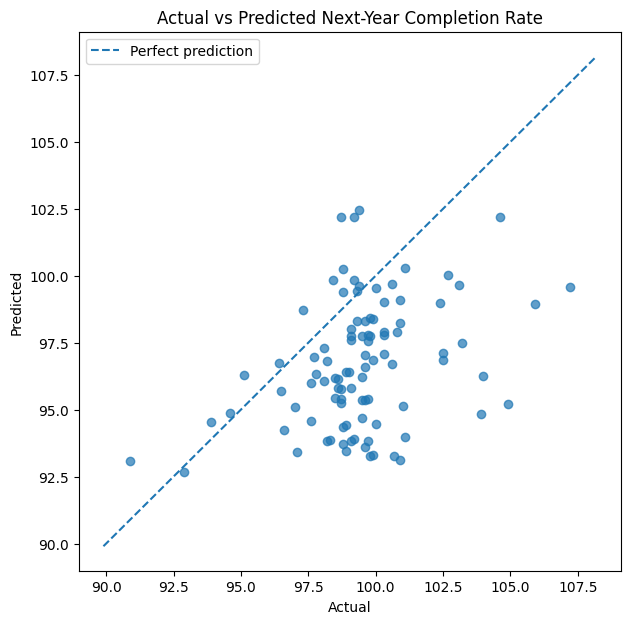

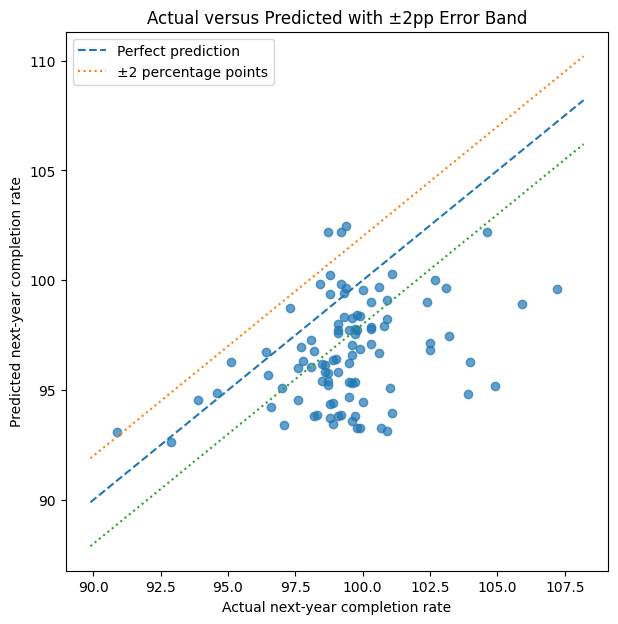

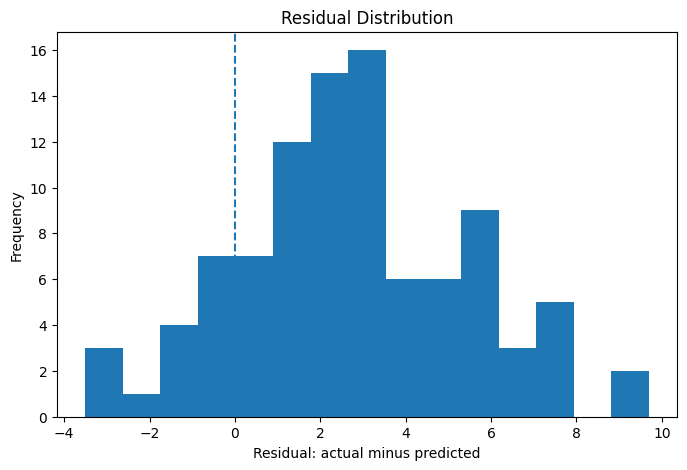

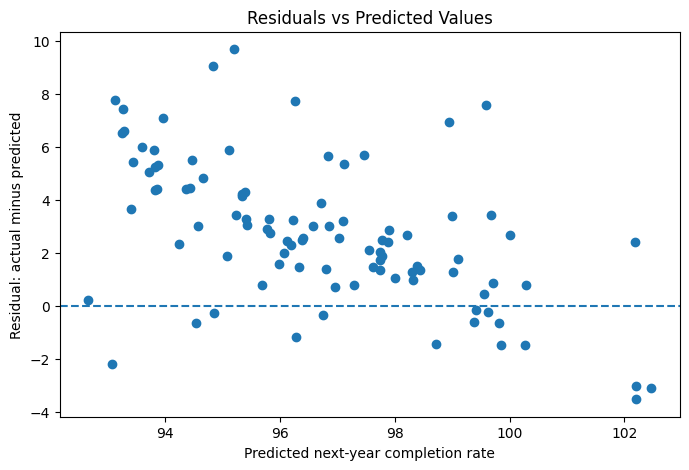

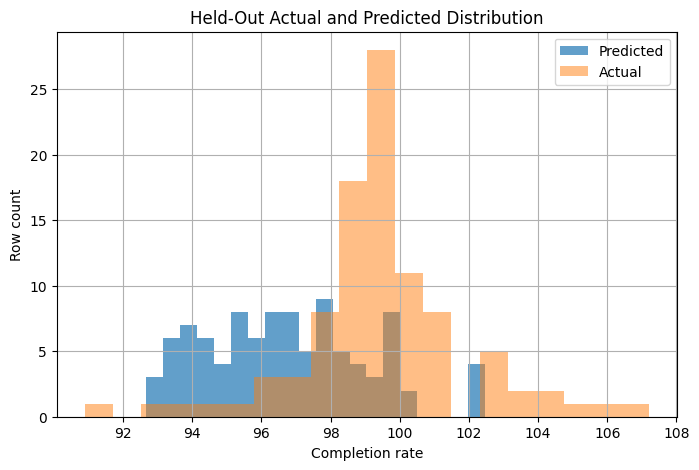

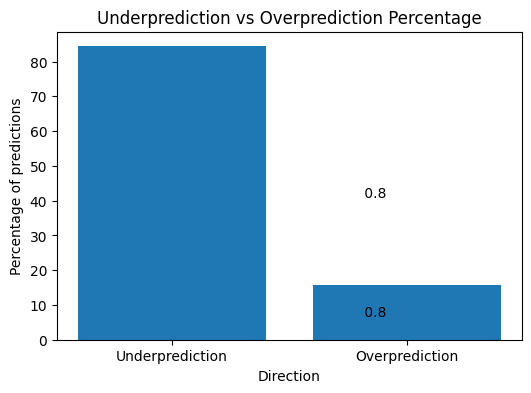

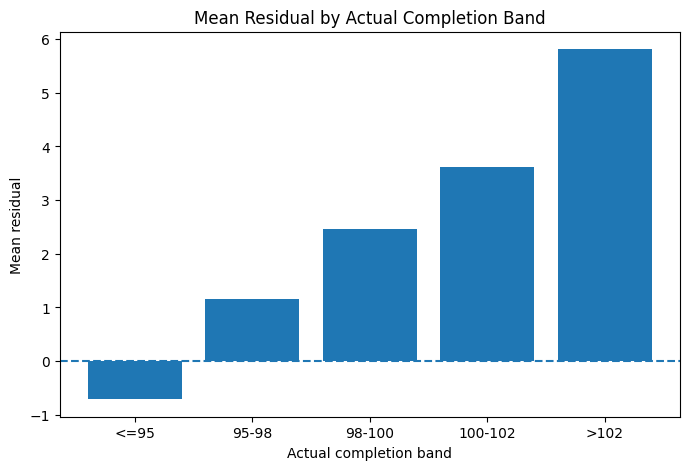

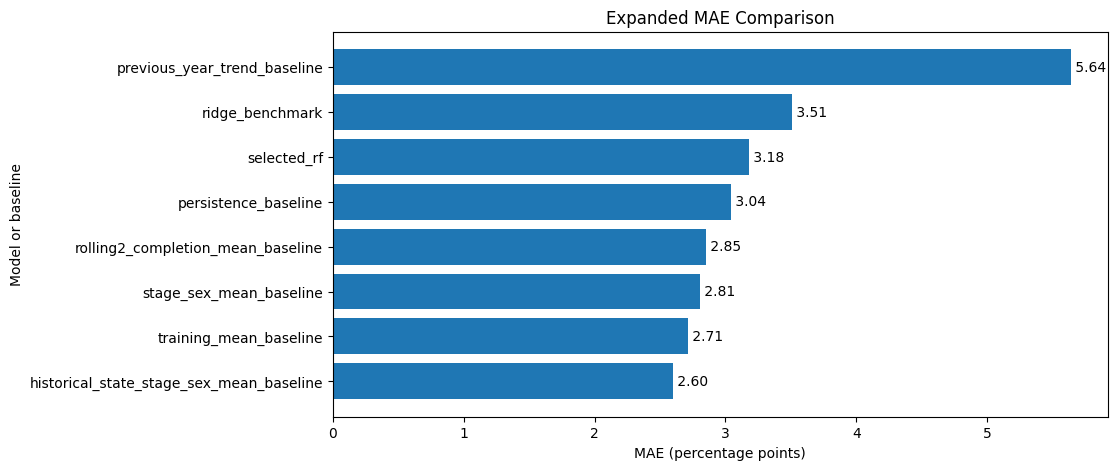

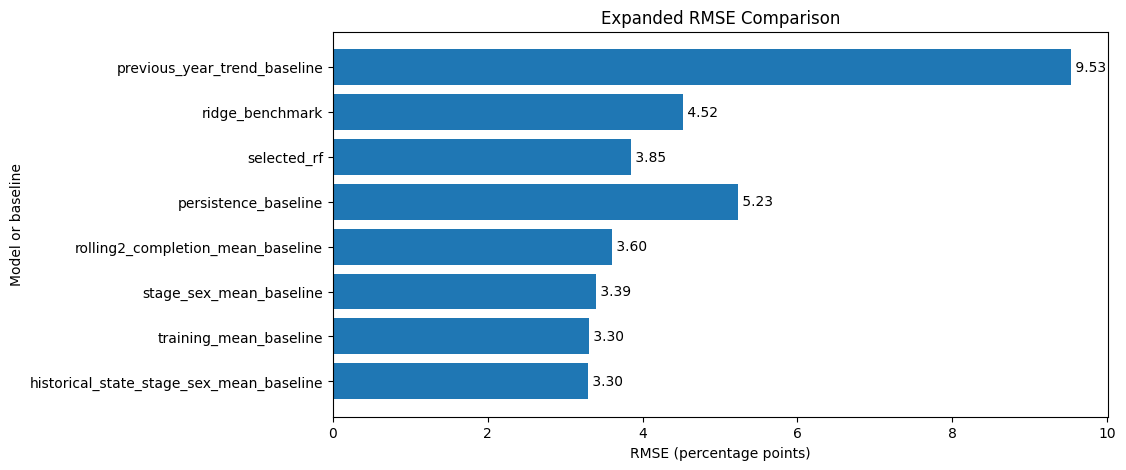

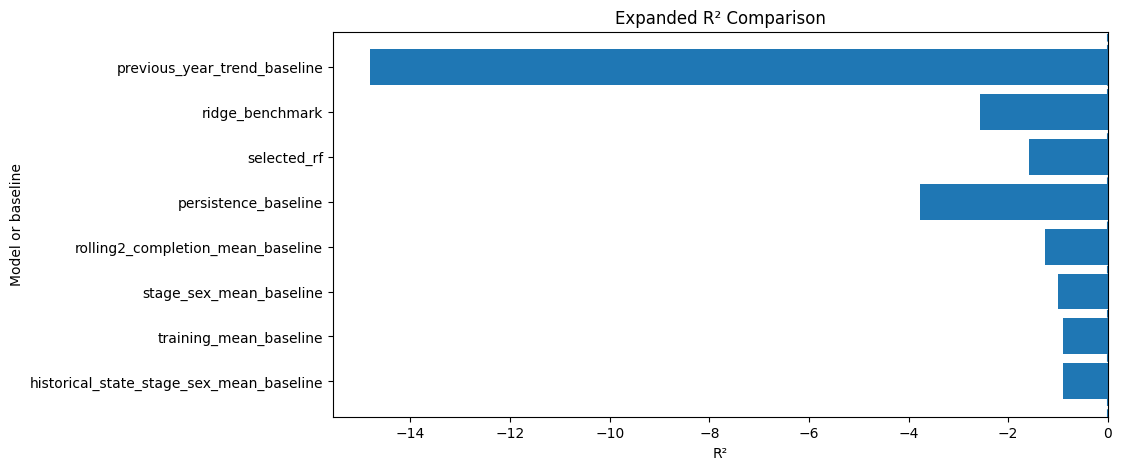

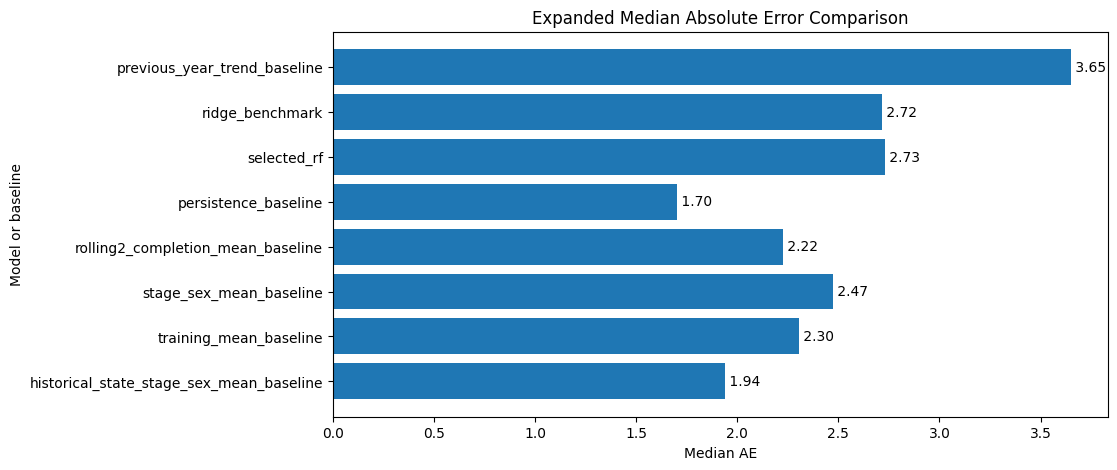

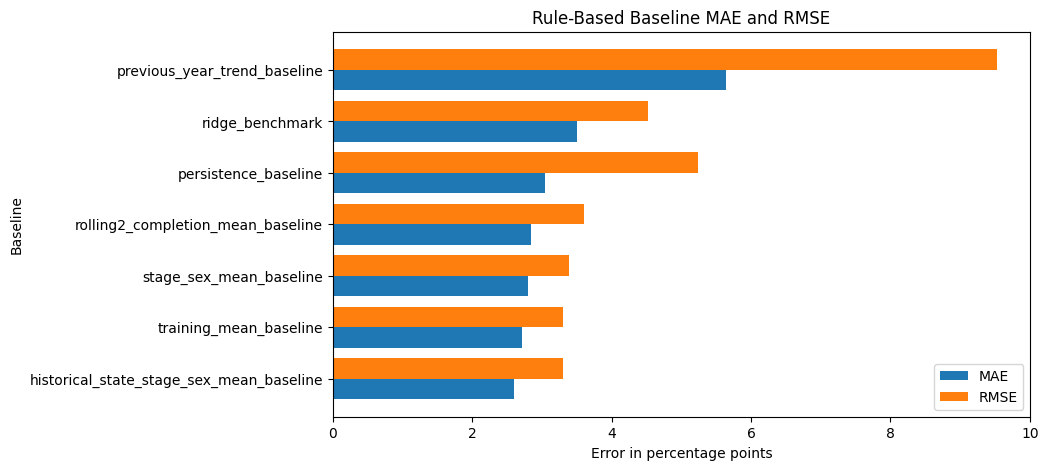

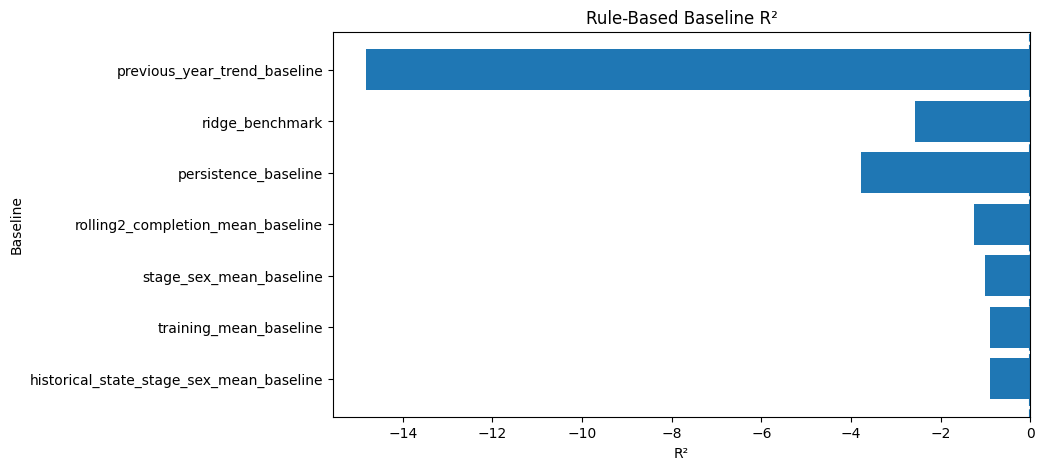

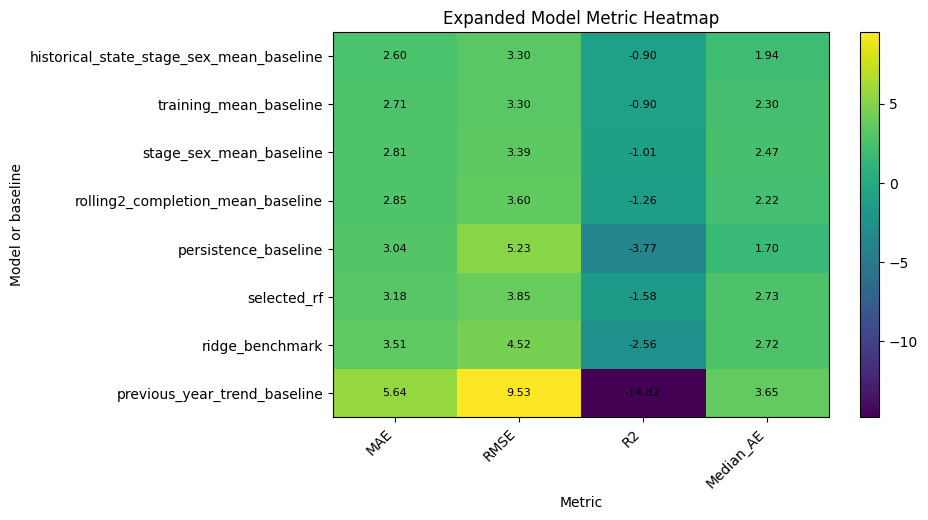

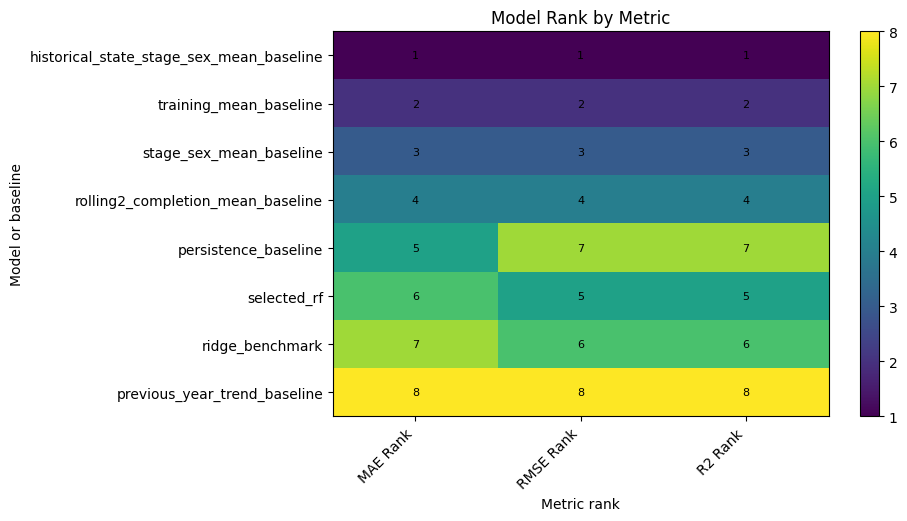

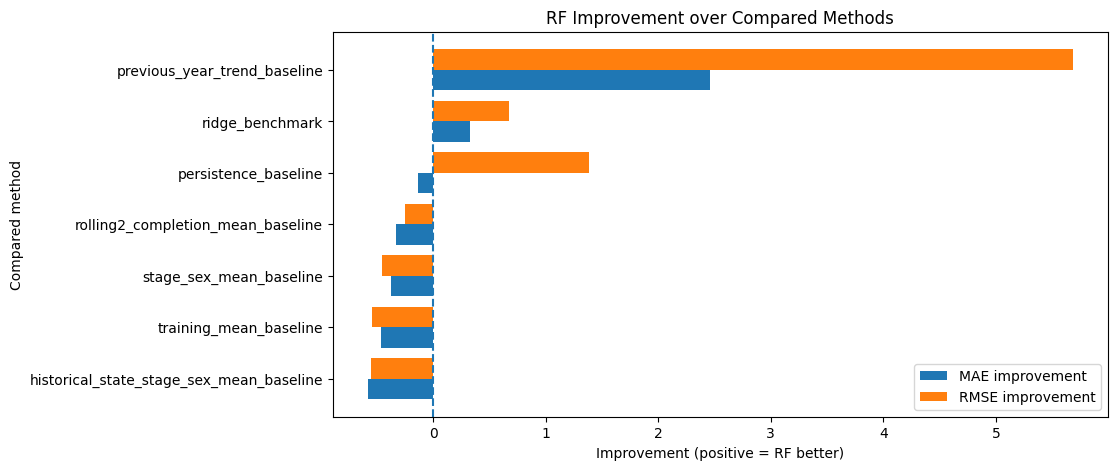

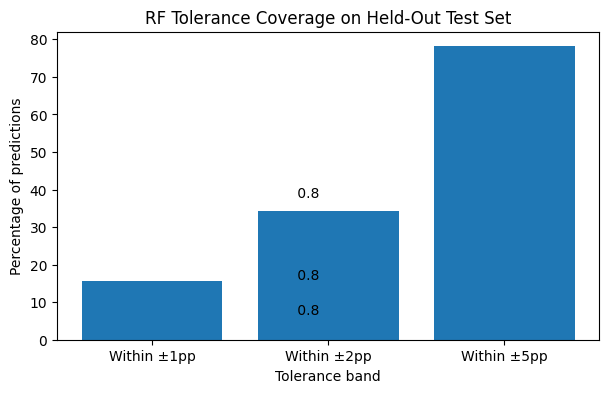

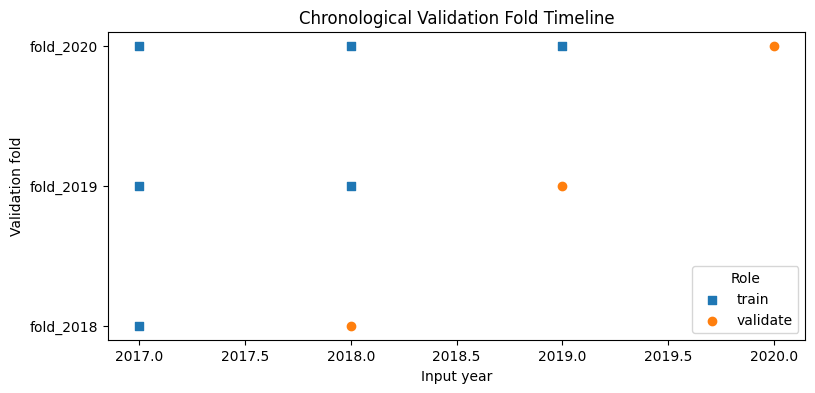

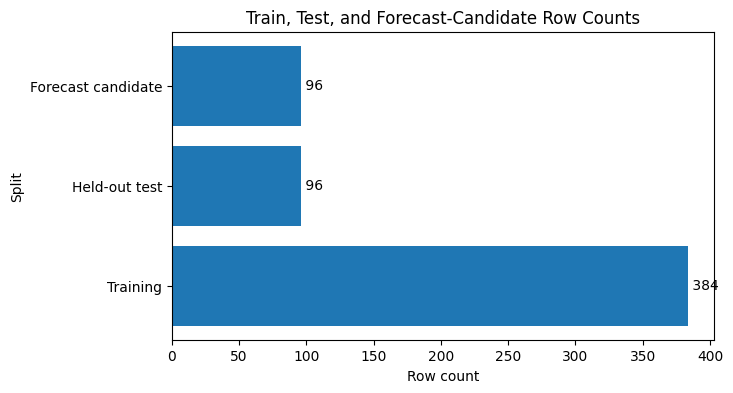

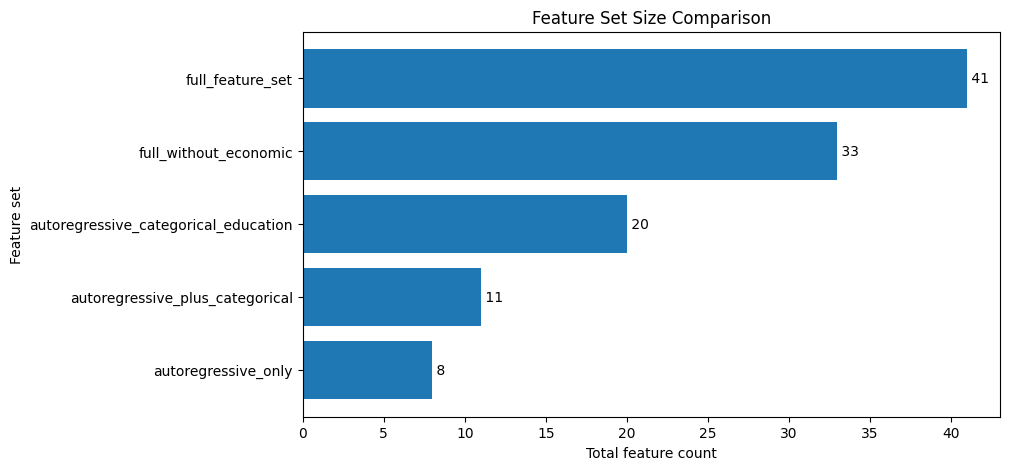

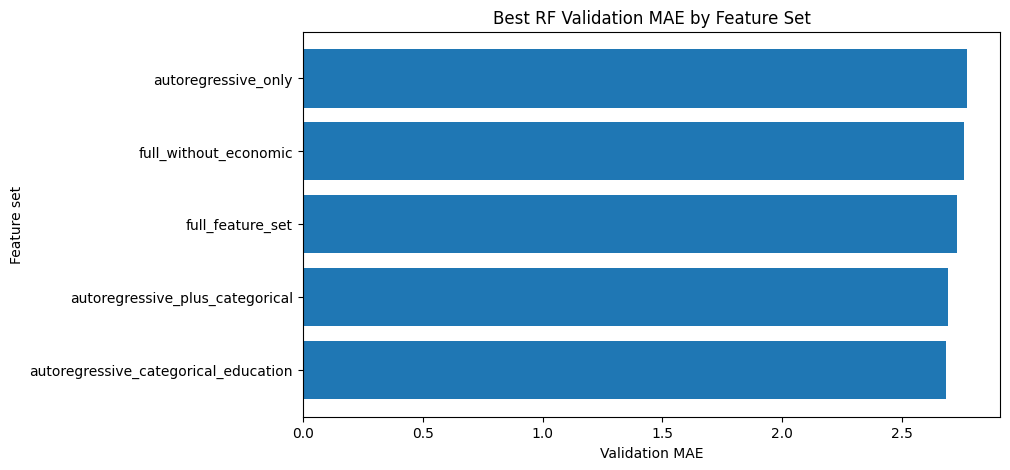

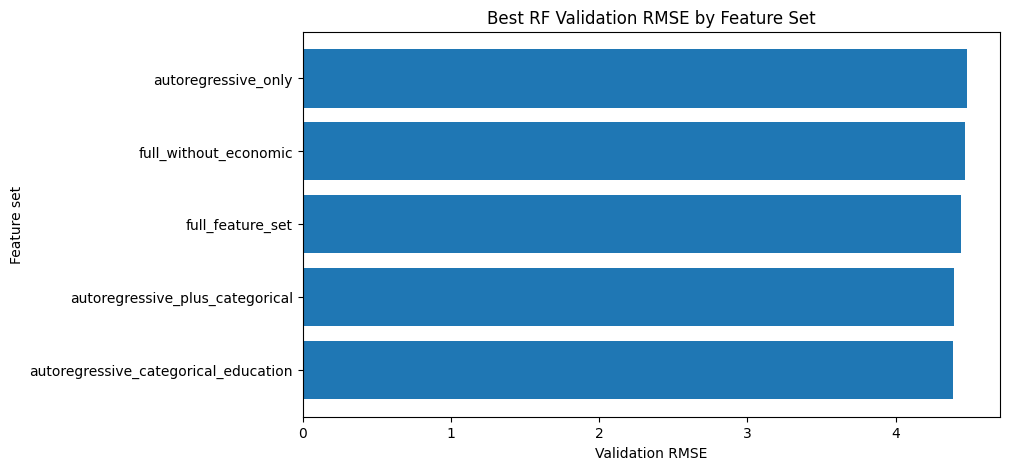

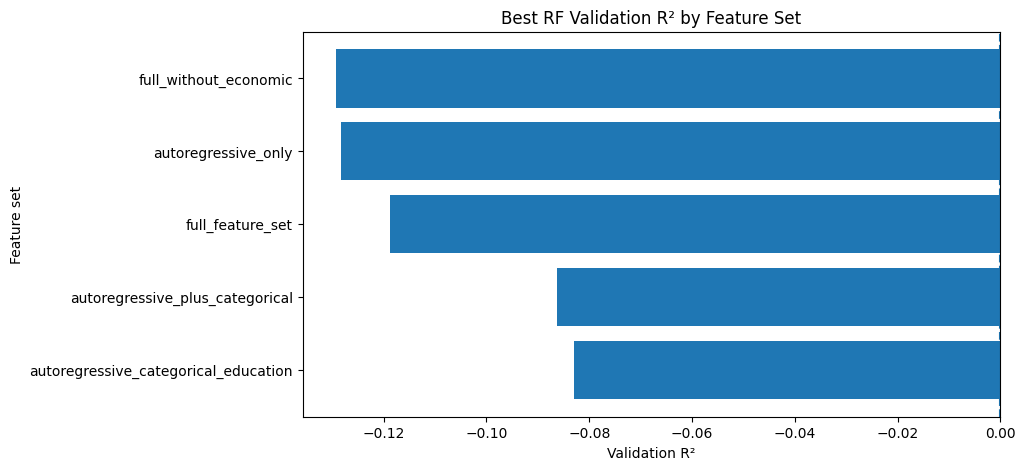

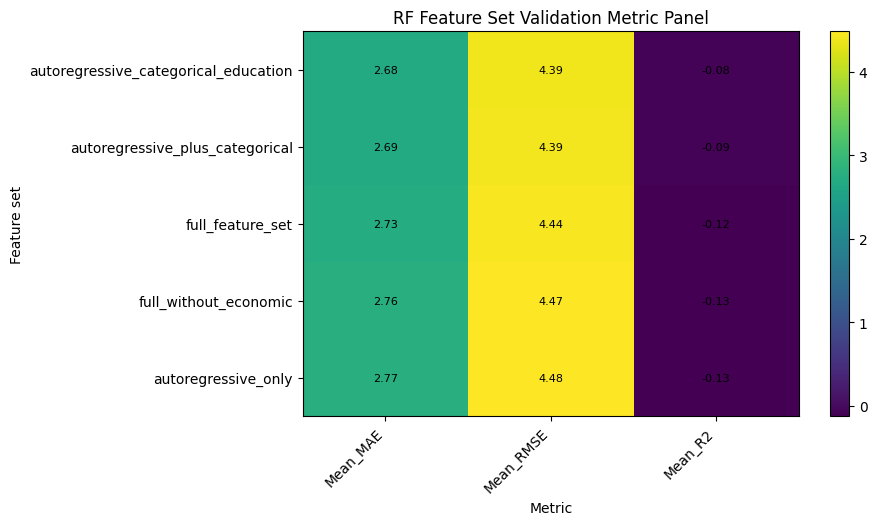

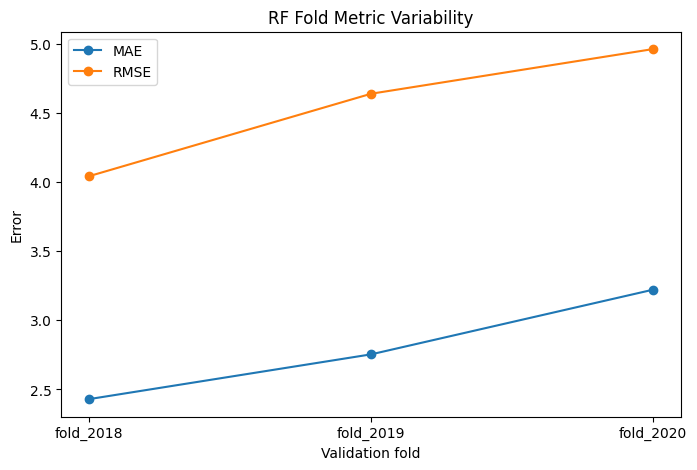

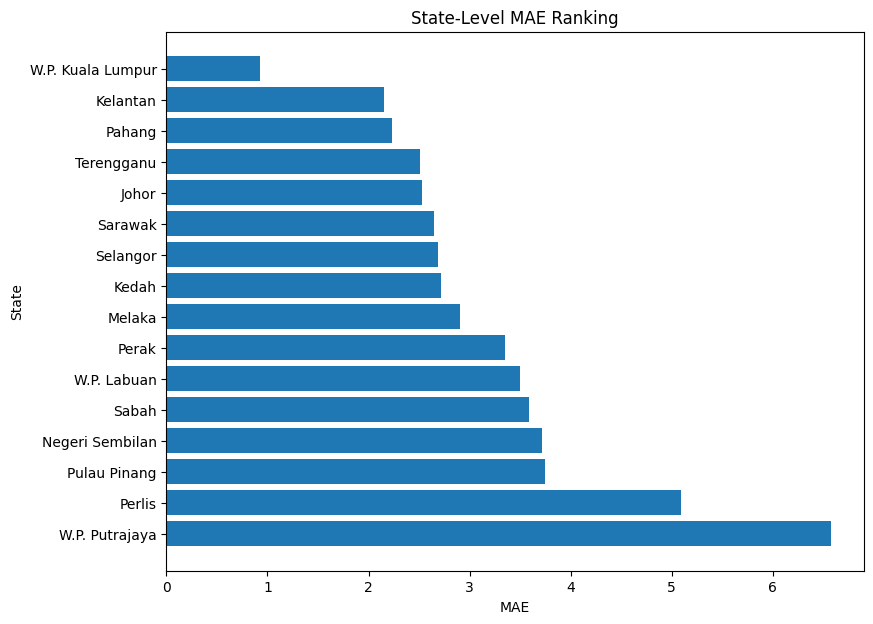

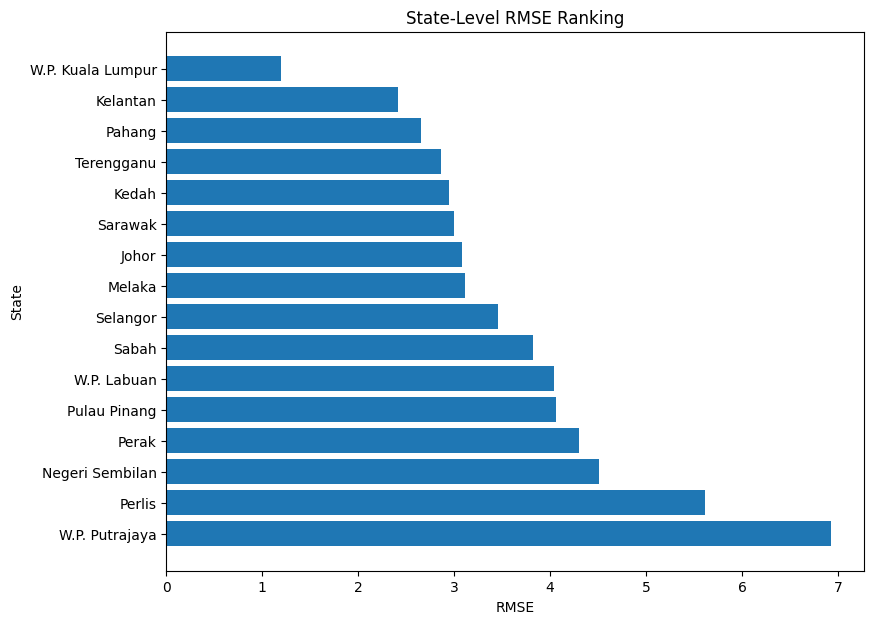

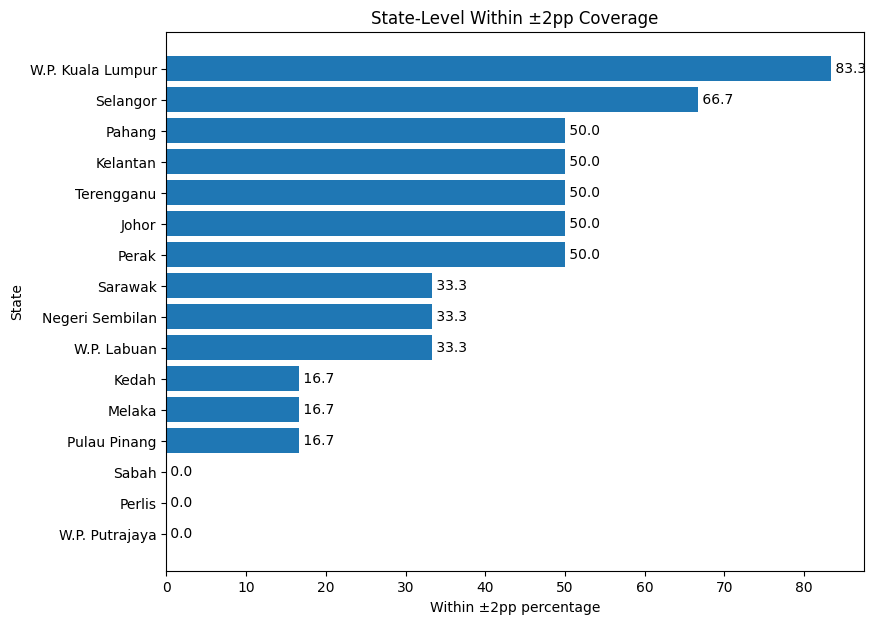

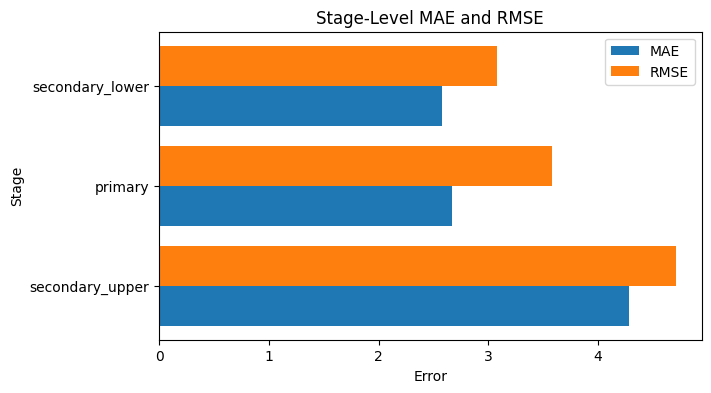

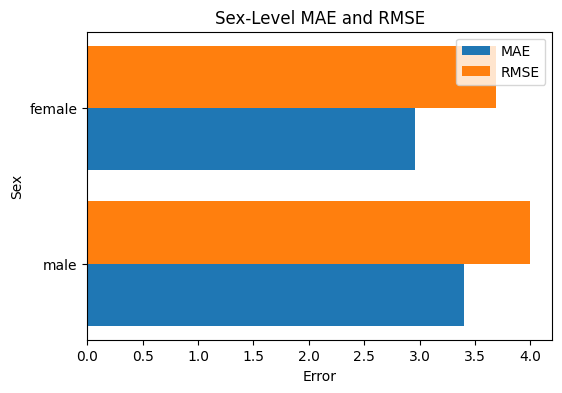

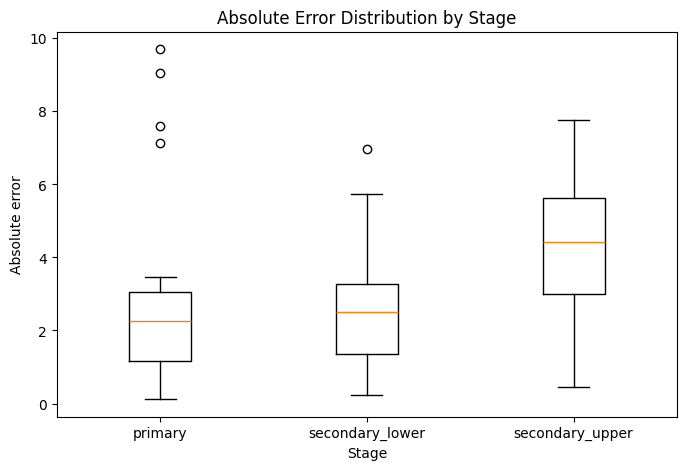

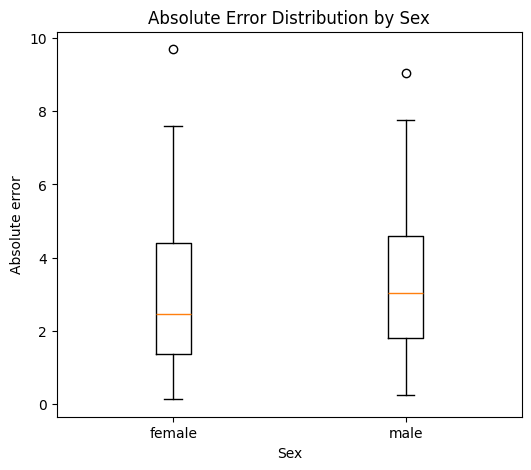

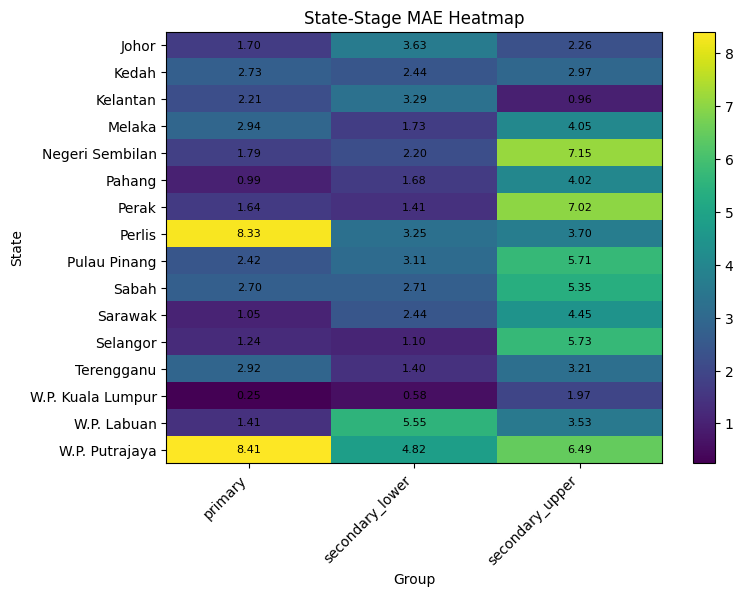

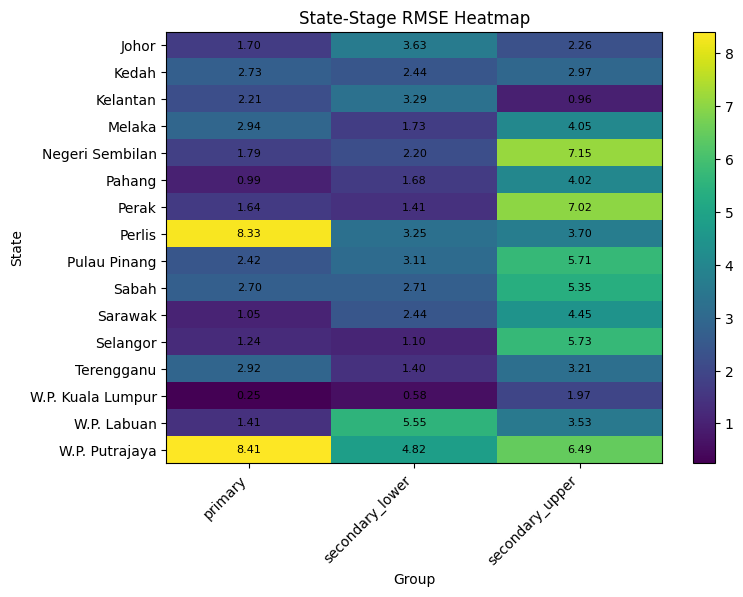

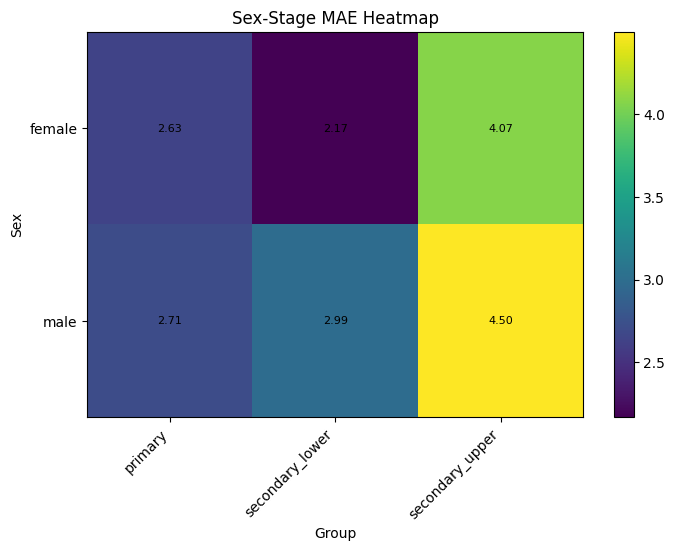

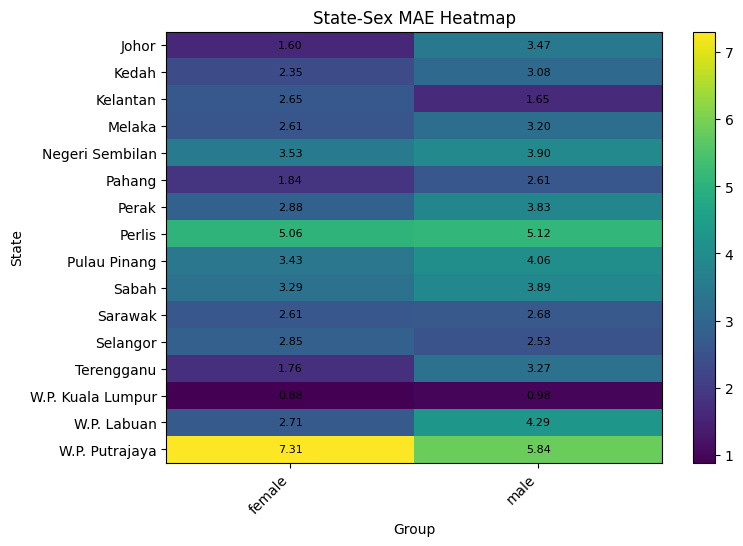

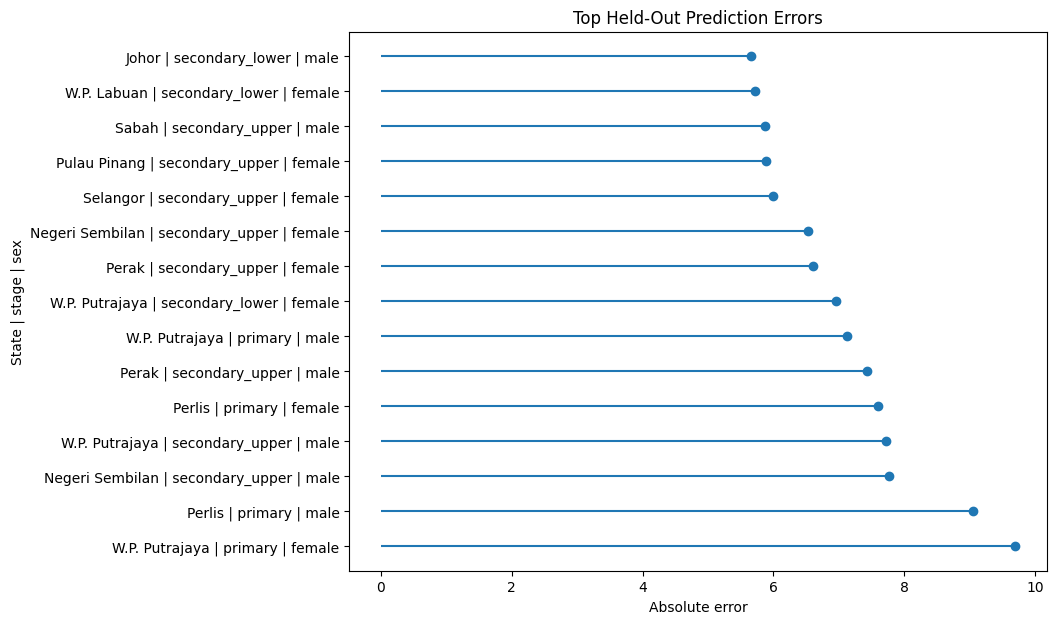

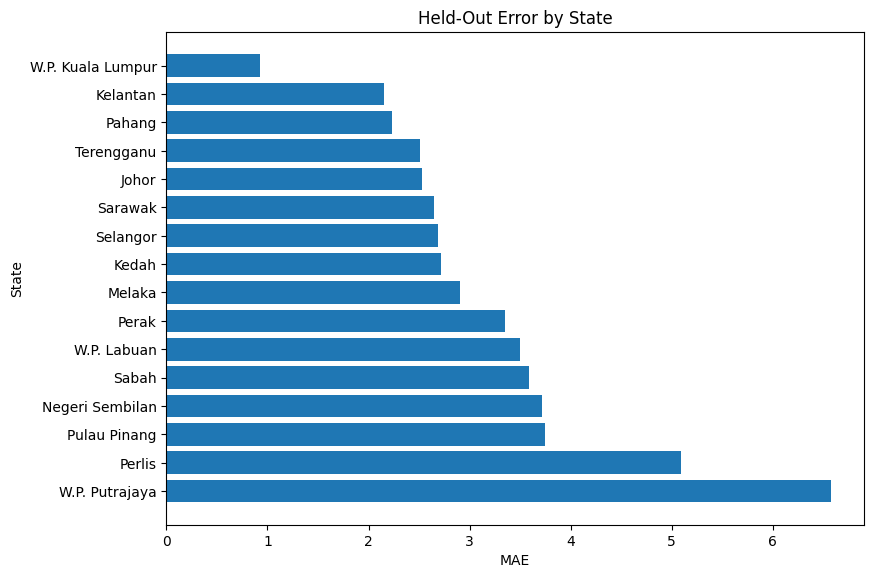

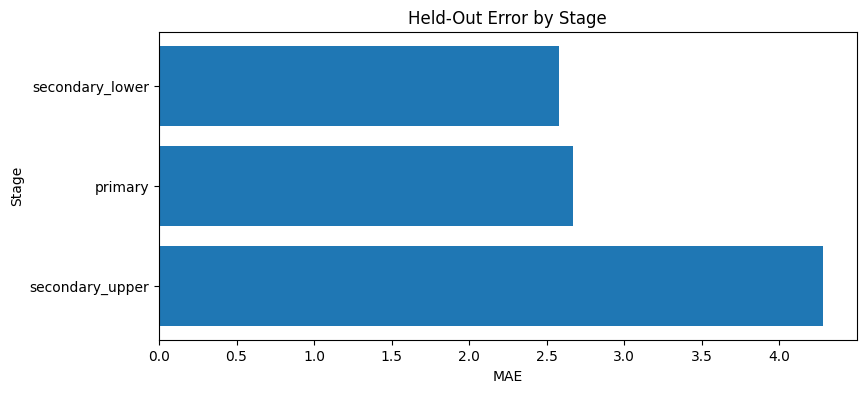

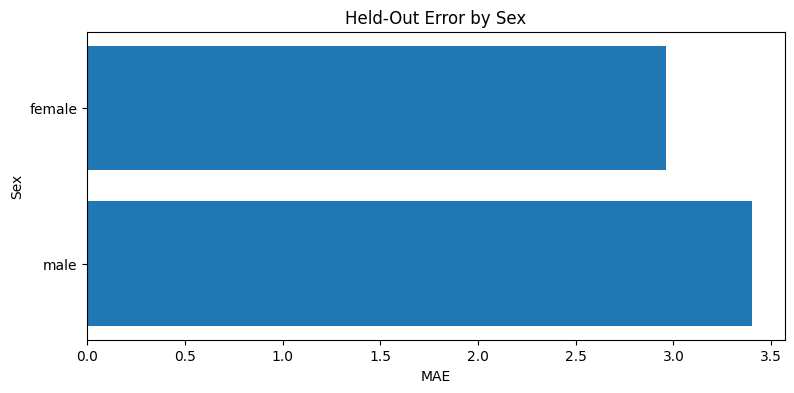

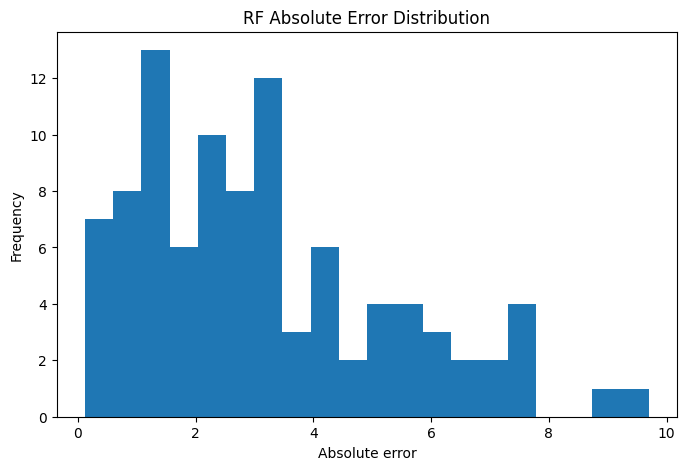

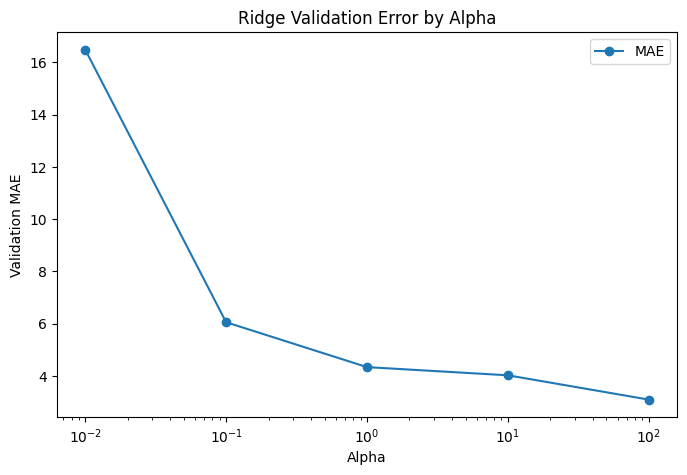

Step 6.5 visual evidence complete.


In [20]:
# ── Step 6.5 - Prediction Fit, Residual, and Comparison Visual Evidence ──

# Actual vs Predicted scatter (simple)
actual = test_predictions_df["Actual Next-Year Completion Rate"]
predicted = test_predictions_df["Predicted Next-Year Completion Rate"]
axis_min = min(actual.min(), predicted.min()) - 1
axis_max = max(actual.max(), predicted.max()) + 1

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(actual, predicted, alpha=0.7)
ax.plot([axis_min, axis_max], [axis_min, axis_max], linestyle="--", label="Perfect prediction")
set_axis_labels(ax, "Actual vs Predicted Next-Year Completion Rate", "Actual", "Predicted")
ax.legend()
register_visual_figure("Actual vs Predicted", "actual_vs_predicted.png", "test_predictions_df", "Compare held-out actual and predicted completion-rate values.")

# Actual vs Predicted with ±2pp error band
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(actual, predicted, alpha=0.7)
ax.plot([axis_min, axis_max], [axis_min, axis_max], linestyle="--", label="Perfect prediction")
ax.plot([axis_min, axis_max], [axis_min + 2, axis_max + 2], linestyle=":", label="±2 percentage points")
ax.plot([axis_min, axis_max], [axis_min - 2, axis_max - 2], linestyle=":")
set_axis_labels(ax, "Actual versus Predicted with ±2pp Error Band", "Actual next-year completion rate", "Predicted next-year completion rate")
ax.legend()
register_visual_figure("Actual versus Predicted with ±2pp Error Band", "actual_vs_predicted_with_error_bands.png", "test_predictions_df", "Shows prediction fit and a practical ±2pp error band.")

# Residual distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(test_predictions_df["Residual"], bins=15)
ax.axvline(0, linestyle="--")
set_axis_labels(ax, "Residual Distribution", "Residual: actual minus predicted", "Frequency")
register_visual_figure("Residual Distribution", "residual_distribution.png", "test_predictions_df", "Review held-out residual spread and direction.")

# Residuals vs Predicted
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(test_predictions_df["Predicted Next-Year Completion Rate"], test_predictions_df["Residual"])
ax.axhline(0, linestyle="--")
set_axis_labels(ax, "Residuals vs Predicted Values", "Predicted next-year completion rate", "Residual: actual minus predicted")
register_visual_figure("Residuals vs Predicted", "residuals_vs_predicted.png", "test_predictions_df", "Check whether residuals vary with predicted values.")

# Test prediction distribution (actual vs predicted histogram)
fig, ax = plt.subplots(figsize=(8, 5))
test_predictions_df["Predicted Next-Year Completion Rate"].hist(bins=20, alpha=0.7, ax=ax, label="Predicted")
test_predictions_df["Actual Next-Year Completion Rate"].hist(bins=20, alpha=0.5, ax=ax, label="Actual")
set_axis_labels(ax, "Held-Out Actual and Predicted Distribution", "Completion rate", "Row count")
ax.legend()
register_visual_figure("Held-Out Actual and Predicted Distribution", "test_prediction_distribution.png", "test_predictions_df", "Compares actual and predicted target distributions on the held-out test set.")

# Underprediction vs Overprediction bar
under_pct = (test_predictions_df["Residual"] > 0).mean() * 100
over_pct = (test_predictions_df["Residual"] < 0).mean() * 100
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Underprediction", "Overprediction"], [under_pct, over_pct])
set_axis_labels(ax, "Underprediction vs Overprediction Percentage", "Direction", "Percentage of predictions")
annotate_bars(ax, decimals=1)
register_visual_figure("Underprediction vs Overprediction", "underprediction_overprediction_bar.png", "residual_summary_df", "Shows proportion of under- and over-predictions.")

# Residuals by actual completion band
band_df = test_predictions_df.copy()
band_df["Actual Completion Band"] = pd.cut(
    band_df["Actual Next-Year Completion Rate"],
    bins=[-np.inf, 95, 98, 100, 102, np.inf],
    labels=["<=95", "95-98", "98-100", "100-102", ">102"],
)
band_summary_df = band_df.groupby("Actual Completion Band", dropna=False).agg(
    Row_Count=("Residual", "size"),
    Mean_Residual=("Residual", "mean"),
    MAE=("Absolute Error", "mean"),
).reset_index()
save_table(band_summary_df, TABLE_OUTPUT_DIR / "residuals_by_actual_completion_band.csv")
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(band_summary_df["Actual Completion Band"].astype(str), band_summary_df["Mean_Residual"])
ax.axhline(0, linestyle="--")
set_axis_labels(ax, "Mean Residual by Actual Completion Band", "Actual completion band", "Mean residual")
register_visual_figure("Mean Residual by Actual Completion Band", "residuals_by_actual_completion_band.png", "residuals_by_actual_completion_band.csv", "Shows whether residual bias changes across actual completion-rate bands.")

# Expanded comparison - MAE
comp_plot_df = expanded_model_comparison_metrics_df.sort_values("MAE", ascending=True).copy()
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(comp_plot_df["Model Name"], comp_plot_df["MAE"])
set_axis_labels(ax, "Expanded MAE Comparison", "MAE (percentage points)", "Model or baseline")
annotate_bars(ax, decimals=2)
register_visual_figure("Expanded MAE Comparison", "expanded_mae_comparison.png", "expanded_model_comparison_metrics_df", "Compares MAE across all evaluated methods.")

# Expanded comparison - RMSE
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(comp_plot_df["Model Name"], comp_plot_df["RMSE"])
set_axis_labels(ax, "Expanded RMSE Comparison", "RMSE (percentage points)", "Model or baseline")
annotate_bars(ax, decimals=2)
register_visual_figure("Expanded RMSE Comparison", "expanded_rmse_comparison.png", "expanded_model_comparison_metrics_df", "Compares RMSE across all evaluated methods.")

# Expanded comparison - R²
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(comp_plot_df["Model Name"], comp_plot_df["R2"])
ax.axvline(0, linestyle="--")
set_axis_labels(ax, "Expanded R² Comparison", "R²", "Model or baseline")
register_visual_figure("Expanded R² Comparison", "expanded_r2_comparison.png", "expanded_model_comparison_metrics_df", "Compares R² across all evaluated methods.")

# Expanded comparison - Median AE
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(comp_plot_df["Model Name"], comp_plot_df["Median_AE"])
set_axis_labels(ax, "Expanded Median Absolute Error Comparison", "Median AE", "Model or baseline")
annotate_bars(ax, decimals=2)
register_visual_figure("Expanded Median AE Comparison", "expanded_median_ae_comparison.png", "expanded_model_comparison_metrics_df", "Compares Median AE across all evaluated methods.")

# Baseline MAE+RMSE side-by-side (pre-RF)
baseline_plot_df = all_baseline_metrics_pre_rf_df.sort_values("MAE", ascending=True).copy()
fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(baseline_plot_df))
ax.barh(y - 0.2, baseline_plot_df["MAE"], height=0.4, label="MAE")
ax.barh(y + 0.2, baseline_plot_df["RMSE"], height=0.4, label="RMSE")
ax.set_yticks(y)
ax.set_yticklabels(baseline_plot_df["Model Name"])
set_axis_labels(ax, "Rule-Based Baseline MAE and RMSE", "Error in percentage points", "Baseline")
ax.legend()
register_visual_figure("Rule-Based Baseline MAE and RMSE", "all_baseline_mae_rmse_comparison.png", "all_baseline_metrics_pre_rf_df", "Shows core and rule-based baseline performance before RF comparison.")

# Baseline R²
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(baseline_plot_df["Model Name"], baseline_plot_df["R2"])
ax.axvline(0, linestyle="--")
set_axis_labels(ax, "Rule-Based Baseline R²", "R²", "Baseline")
register_visual_figure("Rule-Based Baseline R²", "all_baseline_r2_comparison.png", "all_baseline_metrics_pre_rf_df", "Shows baseline explanatory performance before RF comparison.")

# Full metric heatmap
metric_cols = ["MAE", "RMSE", "R2", "Median_AE"]
metric_matrix_df = comp_plot_df.set_index("Model Name")[metric_cols]
numeric_heatmap(
    metric_matrix_df.values,
    metric_matrix_df.index.tolist(),
    metric_matrix_df.columns.tolist(),
    "Expanded Model Metric Heatmap", "Metric", "Model or baseline",
    "expanded_model_metric_heatmap.png",
    "expanded_model_comparison_metrics_df",
    "Shows all major regression metrics for RF, baselines, and Ridge in one visual.",
)

# Model rank by metric heatmap
comp_plot_df["MAE Rank"] = comp_plot_df["MAE"].rank(method="min", ascending=True).astype(int)
comp_plot_df["RMSE Rank"] = comp_plot_df["RMSE"].rank(method="min", ascending=True).astype(int)
comp_plot_df["R2 Rank"] = comp_plot_df["R2"].rank(method="min", ascending=False).astype(int)
rank_cols = ["MAE Rank", "RMSE Rank", "R2 Rank"]
rank_df = comp_plot_df.set_index("Model Name")[rank_cols]
numeric_heatmap(
    rank_df.values,
    rank_df.index.tolist(),
    rank_df.columns.tolist(),
    "Model Rank by Metric", "Metric rank", "Model or baseline",
    "model_rank_by_metric.png",
    "expanded_model_comparison_metrics_df",
    "Shows rank consistency across core comparison metrics.",
    value_format=".0f",
)

# RF improvement over baselines bar
fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(expanded_baseline_vs_rf_delta_df))
mae_imp = expanded_baseline_vs_rf_delta_df["MAE Improvement"]
rmse_imp = expanded_baseline_vs_rf_delta_df["RMSE Improvement"]
ax.barh(y - 0.2, mae_imp, height=0.4, label="MAE improvement")
ax.barh(y + 0.2, rmse_imp, height=0.4, label="RMSE improvement")
ax.set_yticks(y)
ax.set_yticklabels(expanded_baseline_vs_rf_delta_df["Compared Model"])
ax.axvline(0, linestyle="--")
set_axis_labels(ax, "RF Improvement over Compared Methods", "Improvement (positive = RF better)", "Compared method")
ax.legend()
register_visual_figure("RF Improvement over Compared Methods", "rf_improvement_over_baselines.png", "expanded_baseline_vs_rf_delta_df", "Shows how much RF improves over each baseline and Ridge benchmark.")

# Tolerance coverage comparison table and chart
tolerance_rows = []
for _, row in comp_plot_df.iterrows():
    model_name = row["Model Name"]
    if model_name == "selected_rf":
        preds_df = test_predictions_df.copy()
        preds_df["Absolute Error"] = preds_df["Absolute Error"]
    else:
        # pull from combined diagnostics if available
        continue
    tolerance_rows.append({
        "Model Name": model_name,
        "Within 1pp": (preds_df["Absolute Error"] <= 1).mean() * 100,
        "Within 2pp": (preds_df["Absolute Error"] <= 2).mean() * 100,
        "Within 5pp": (preds_df["Absolute Error"] <= 5).mean() * 100,
    })

rf_tolerance_summary_df = pd.DataFrame([{
    "Model Name": "selected_rf",
    "Within 1pp": (test_predictions_df["Absolute Error"] <= 1).mean() * 100,
    "Within 2pp": (test_predictions_df["Absolute Error"] <= 2).mean() * 100,
    "Within 5pp": (test_predictions_df["Absolute Error"] <= 5).mean() * 100,
}])
save_table(rf_tolerance_summary_df, TABLE_OUTPUT_DIR / "rf_tolerance_summary.csv")

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(3)
ax.bar(x, [rf_tolerance_summary_df["Within 1pp"].iloc[0],
           rf_tolerance_summary_df["Within 2pp"].iloc[0],
           rf_tolerance_summary_df["Within 5pp"].iloc[0]])
ax.set_xticks(x)
ax.set_xticklabels(["Within ±1pp", "Within ±2pp", "Within ±5pp"])
set_axis_labels(ax, "RF Tolerance Coverage on Held-Out Test Set", "Tolerance band", "Percentage of predictions")
annotate_bars(ax, decimals=1)
register_visual_figure("RF Tolerance Coverage", "rf_tolerance_coverage.png", "rf_tolerance_summary_df", "Shows percentage of predictions within practical tolerance bands.")

# Chronological split timeline
fold_plot_rows = []
for fold in chronological_validation_folds:
    for yr in fold["train_years"]:
        fold_plot_rows.append({"Fold": fold["fold_name"], "Year": yr, "Role": "train"})
    fold_plot_rows.append({"Fold": fold["fold_name"], "Year": fold["validation_year"], "Role": "validate"})
fold_timeline_df = pd.DataFrame(fold_plot_rows)
save_table(fold_timeline_df, TABLE_OUTPUT_DIR / "chronological_split_timeline_source.csv")

fig, ax = plt.subplots(figsize=(9, 4))
for role, marker in {"train": "s", "validate": "o"}.items():
    role_df = fold_timeline_df.loc[fold_timeline_df["Role"] == role]
    ax.scatter(role_df["Year"], role_df["Fold"], marker=marker, label=role)
set_axis_labels(ax, "Chronological Validation Fold Timeline", "Input year", "Validation fold")
ax.legend(title="Role")
register_visual_figure("Chronological Validation Fold Timeline", "chronological_split_timeline.png", "chronological_validation_folds_df", "Shows that validation years occur after their training years.")

# Train/test/forecast row count bar
split_count_df = pd.DataFrame([
    {"Split": "Training", "Row Count": len(train_panel_df)},
    {"Split": "Held-out test", "Row Count": len(test_panel_df)},
    {"Split": "Forecast candidate", "Row Count": len(forecast_candidate_panel_df)},
])
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(split_count_df["Split"], split_count_df["Row Count"])
set_axis_labels(ax, "Train, Test, and Forecast-Candidate Row Counts", "Row count", "Split")
annotate_bars(ax, decimals=0)
register_visual_figure("Train, Test, and Forecast-Candidate Row Counts", "train_test_forecast_row_count_bar.png", "split_count_df", "Shows supervised row allocation for fitting, evaluation, and forecast preview.")

# Feature set size comparison
feature_size_df = feature_set_registry_df.sort_values("Total Feature Count", ascending=True).copy()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(feature_size_df["Feature Set"], feature_size_df["Total Feature Count"])
set_axis_labels(ax, "Feature Set Size Comparison", "Total feature count", "Feature set")
annotate_bars(ax, decimals=0)
register_visual_figure("Feature Set Size Comparison", "feature_set_size_comparison.png", "feature_set_registry_df", "Shows feature-set complexity before validation.")

# RF validation MAE/RMSE/R2 by feature set
rf_feature_df = (
    rf_validation_summary_df
    .groupby("Feature Set", as_index=False)
    .agg(Mean_MAE=("Mean_MAE", "min"), Mean_RMSE=("Mean_RMSE", "min"), Mean_R2=("Mean_R2", "max"))
    .sort_values("Mean_MAE")
    .reset_index(drop=True)
)
save_table(rf_feature_df, TABLE_OUTPUT_DIR / "rf_feature_set_best_metric_summary.csv")

for metric_col, filename, title, xlabel in [
    ("Mean_MAE", "rf_validation_mae_by_feature_set.png", "Best RF Validation MAE by Feature Set", "Validation MAE"),
    ("Mean_RMSE", "rf_validation_rmse_by_feature_set.png", "Best RF Validation RMSE by Feature Set", "Validation RMSE"),
    ("Mean_R2", "rf_validation_r2_by_feature_set.png", "Best RF Validation R² by Feature Set", "Validation R²"),
]:
    plot_df = rf_feature_df.sort_values(metric_col, ascending=(metric_col != "Mean_R2"))
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(plot_df["Feature Set"], plot_df[metric_col])
    if metric_col == "Mean_R2":
        ax.axvline(0, linestyle="--")
    set_axis_labels(ax, title, xlabel, "Feature set")
    register_visual_figure(title, filename, "rf_validation_summary_df", f"Shows feature-set performance during chronological validation.")

# Feature set metric panel heatmap
metric_panel_df = rf_feature_df.set_index("Feature Set")[["Mean_MAE", "Mean_RMSE", "Mean_R2"]]
save_table(rf_feature_df, TABLE_OUTPUT_DIR / "feature_set_validation_metric_panel.csv")
numeric_heatmap(
    metric_panel_df.values,
    metric_panel_df.index.tolist(),
    metric_panel_df.columns.tolist(),
    "RF Feature Set Validation Metric Panel", "Metric", "Feature set",
    "feature_set_validation_metric_panel.png",
    "feature_set_validation_metric_panel.csv",
    "Summarises how feature sets compare across multiple validation metrics.",
)

# RF fold metric variability
fold_variability_df = rf_validation_results_df.groupby("Fold Name", as_index=False)[["MAE", "RMSE", "R2"]].mean()
save_table(fold_variability_df, TABLE_OUTPUT_DIR / "rf_fold_metric_variability.csv")
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fold_variability_df["Fold Name"], fold_variability_df["MAE"], marker="o", label="MAE")
ax.plot(fold_variability_df["Fold Name"], fold_variability_df["RMSE"], marker="o", label="RMSE")
set_axis_labels(ax, "RF Fold Metric Variability", "Validation fold", "Error")
ax.legend()
register_visual_figure("RF Fold Metric Variability", "rf_fold_metric_variability.png", "rf_fold_metric_variability_df", "Shows how validation error changes across chronological folds.")

# State error: RMSE ranked + within 2pp
state_plot_df = error_by_state_df.sort_values("MAE", ascending=False).copy()
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(state_plot_df[STATE_COL], state_plot_df["MAE"])
set_axis_labels(ax, "State-Level MAE Ranking", "MAE", "State")
register_visual_figure("State-Level MAE Ranking", "state_mae_ranked_bar.png", "error_by_state_df", "Shows states with highest held-out MAE.")

state_rmse_df = error_by_state_df.sort_values("RMSE", ascending=False).copy()
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(state_rmse_df[STATE_COL], state_rmse_df["RMSE"])
set_axis_labels(ax, "State-Level RMSE Ranking", "RMSE", "State")
register_visual_figure("State-Level RMSE Ranking", "state_rmse_ranked_bar.png", "error_by_state_df", "Shows states with highest held-out RMSE.")

state_2pp_df = error_by_state_df.sort_values("Within 2 Percentage Points", ascending=True).copy()
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(state_2pp_df[STATE_COL], state_2pp_df["Within 2 Percentage Points"])
set_axis_labels(ax, "State-Level Within ±2pp Coverage", "Within ±2pp percentage", "State")
annotate_bars(ax, decimals=1)
register_visual_figure("State-Level Within ±2pp Coverage", "state_within_2pp_rate_bar.png", "error_by_state_df", "Shows which states have the highest within-tolerance prediction rate.")

# Stage MAE/RMSE
y = np.arange(len(error_by_stage_df))
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(y - 0.2, error_by_stage_df["MAE"], height=0.4, label="MAE")
ax.barh(y + 0.2, error_by_stage_df["RMSE"], height=0.4, label="RMSE")
ax.set_yticks(y)
ax.set_yticklabels(error_by_stage_df[STAGE_COL])
set_axis_labels(ax, "Stage-Level MAE and RMSE", "Error", "Stage")
ax.legend()
register_visual_figure("Stage-Level MAE and RMSE", "stage_mae_rmse_comparison.png", "error_by_stage_df", "Compares errors across education stages.")

# Sex MAE/RMSE
y = np.arange(len(error_by_sex_df))
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(y - 0.2, error_by_sex_df["MAE"], height=0.4, label="MAE")
ax.barh(y + 0.2, error_by_sex_df["RMSE"], height=0.4, label="RMSE")
ax.set_yticks(y)
ax.set_yticklabels(error_by_sex_df[SEX_COL])
set_axis_labels(ax, "Sex-Level MAE and RMSE", "Error", "Sex")
ax.legend()
register_visual_figure("Sex-Level MAE and RMSE", "sex_mae_rmse_comparison.png", "error_by_sex_df", "Compares errors across male and female rows.")

# Error boxplots by stage and sex
stage_order = sorted(test_predictions_df[STAGE_COL].dropna().unique())
stage_abs_values = [test_predictions_df.loc[test_predictions_df[STAGE_COL] == s, "Absolute Error"].dropna() for s in stage_order]
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(stage_abs_values, tick_labels=stage_order)
set_axis_labels(ax, "Absolute Error Distribution by Stage", "Stage", "Absolute error")
register_visual_figure("Absolute Error Distribution by Stage", "stage_error_distribution_boxplot.png", "test_predictions_df", "Shows the spread of row-level errors by education stage.")

sex_order = sorted(test_predictions_df[SEX_COL].dropna().unique())
sex_abs_values = [test_predictions_df.loc[test_predictions_df[SEX_COL] == s, "Absolute Error"].dropna() for s in sex_order]
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(sex_abs_values, tick_labels=sex_order)
set_axis_labels(ax, "Absolute Error Distribution by Sex", "Sex", "Absolute error")
register_visual_figure("Absolute Error Distribution by Sex", "sex_error_distribution_boxplot.png", "test_predictions_df", "Shows the spread of row-level errors by sex.")

# State-stage, sex-stage, state-sex heatmaps
state_stage_mae_df = (
    error_by_state_stage_sex_df.groupby([STATE_COL, STAGE_COL], as_index=False)["MAE"]
    .mean().pivot(index=STATE_COL, columns=STAGE_COL, values="MAE")
)
state_stage_rmse_df = (
    error_by_state_stage_sex_df.groupby([STATE_COL, STAGE_COL], as_index=False)["RMSE"]
    .mean().pivot(index=STATE_COL, columns=STAGE_COL, values="RMSE")
)
sex_stage_mae_df = (
    error_by_state_stage_sex_df.groupby([SEX_COL, STAGE_COL], as_index=False)["MAE"]
    .mean().pivot(index=SEX_COL, columns=STAGE_COL, values="MAE")
)
state_sex_mae_df = (
    error_by_state_stage_sex_df.groupby([STATE_COL, SEX_COL], as_index=False)["MAE"]
    .mean().pivot(index=STATE_COL, columns=SEX_COL, values="MAE")
)

for heat_df, filename, title, ylabel in [
    (state_stage_mae_df, "state_stage_mae_heatmap.png", "State-Stage MAE Heatmap", "State"),
    (state_stage_rmse_df, "state_stage_rmse_heatmap.png", "State-Stage RMSE Heatmap", "State"),
    (sex_stage_mae_df, "sex_stage_mae_heatmap.png", "Sex-Stage MAE Heatmap", "Sex"),
    (state_sex_mae_df, "state_sex_mae_heatmap.png", "State-Sex MAE Heatmap", "State"),
]:
    numeric_heatmap(
        heat_df.fillna(np.nan).values,
        heat_df.index.astype(str).tolist(),
        heat_df.columns.astype(str).tolist(),
        title, "Group", ylabel, filename,
        "error_by_state_stage_sex_df",
        "Shows grouped prediction error at the row-unit level.",
    )

# Worst errors lollipop
lollipop_df = worst_prediction_rows_df.head(15).copy()
lollipop_df["Row Label"] = lollipop_df[STATE_COL] + " | " + lollipop_df[STAGE_COL] + " | " + lollipop_df[SEX_COL]
fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(lollipop_df))
ax.hlines(y=y, xmin=0, xmax=lollipop_df["Absolute Error"])
ax.scatter(lollipop_df["Absolute Error"], y)
ax.set_yticks(y)
ax.set_yticklabels(lollipop_df["Row Label"])
set_axis_labels(ax, "Top Held-Out Prediction Errors", "Absolute error", "State | stage | sex")
register_visual_figure("Top Held-Out Prediction Errors", "prediction_error_lollipop_top_errors.png", "test_predictions_df", "Shows the largest held-out prediction errors.")

# Error by state/stage/sex bar charts (simple)
for col_name, plot_df, fname, title in [
    (STATE_COL, error_by_state_df.sort_values("MAE", ascending=False), "error_by_state.png", "Held-Out Error by State"),
    (STAGE_COL, error_by_stage_df.sort_values("MAE", ascending=False), "error_by_stage.png", "Held-Out Error by Stage"),
    (SEX_COL, error_by_sex_df.sort_values("MAE", ascending=False), "error_by_sex.png", "Held-Out Error by Sex"),
]:
    fig, ax = plt.subplots(figsize=(9, max(4, len(plot_df) * 0.4)))
    ax.barh(plot_df[col_name], plot_df["MAE"])
    set_axis_labels(ax, title, "MAE", col_name.capitalize())
    register_visual_figure(title, fname, f"error_by_{col_name}_df", f"Shows {col_name}-level held-out MAE.")

# RF absolute error distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(test_predictions_df["Absolute Error"], bins=20)
set_axis_labels(ax, "RF Absolute Error Distribution", "Absolute error", "Frequency")
register_visual_figure("RF Absolute Error Distribution", "rf_absolute_error_distribution.png", "test_predictions_df", "Shows the distribution of absolute prediction errors.")

# Ridge validation alpha comparison
ridge_alpha_vals = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_alpha_metrics = []
for alpha in ridge_alpha_vals:
    ridge_pipeline_tmp = Pipeline(steps=[
        ("preprocessor", ColumnTransformer(transformers=[
            ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_feature_cols),
            ("categorical", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_feature_cols),
        ], remainder="drop")),
        ("model", Ridge(alpha=alpha)),
    ])
    mae_list = []
    for fold in chronological_validation_folds:
        ridge_pipeline_tmp.fit(fold["train_panel_df"][final_feature_cols], fold["train_panel_df"][TARGET_COL])
        y_p = ridge_pipeline_tmp.predict(fold["validation_panel_df"][final_feature_cols])
        mae_list.append(mean_absolute_error(fold["validation_panel_df"][TARGET_COL], y_p))
    ridge_alpha_metrics.append({"Alpha": alpha, "Mean_Validation_MAE": np.mean(mae_list)})
ridge_alpha_df = pd.DataFrame(ridge_alpha_metrics)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ridge_alpha_df["Alpha"], ridge_alpha_df["Mean_Validation_MAE"], marker="o", label="MAE")
ax.set_xscale("log")
set_axis_labels(ax, "Ridge Validation Error by Alpha", "Alpha", "Validation MAE")
ax.legend()
register_visual_figure("Ridge Validation Error by Alpha", "ridge_validation_alpha_comparison.png", "ridge_alpha_df", "Shows how the linear benchmark changes across regularisation strengths.")

print("Step 6.5 visual evidence complete.")


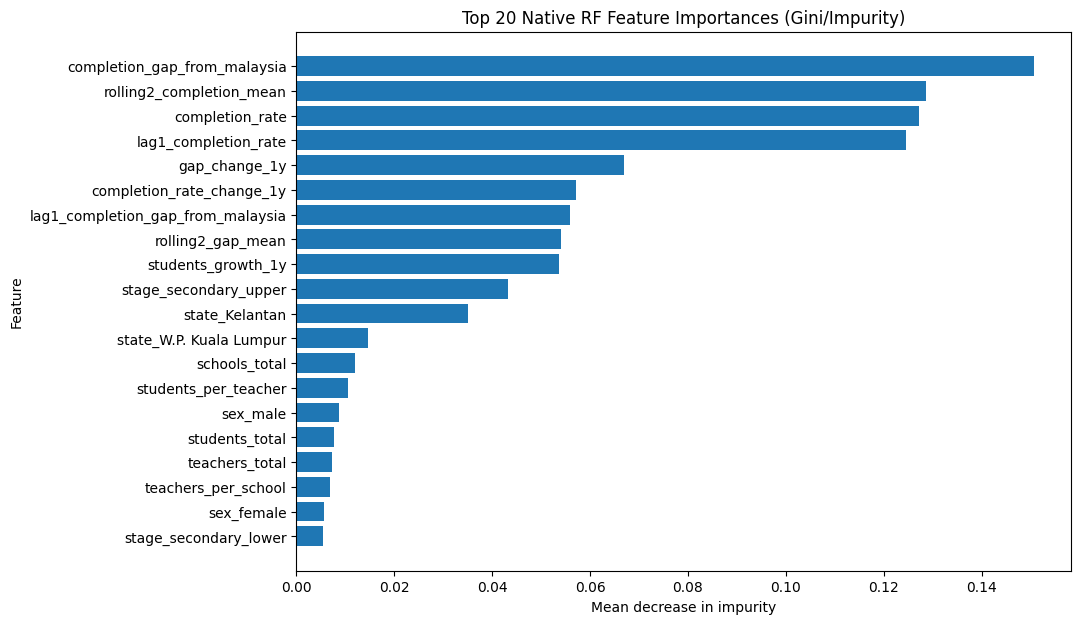

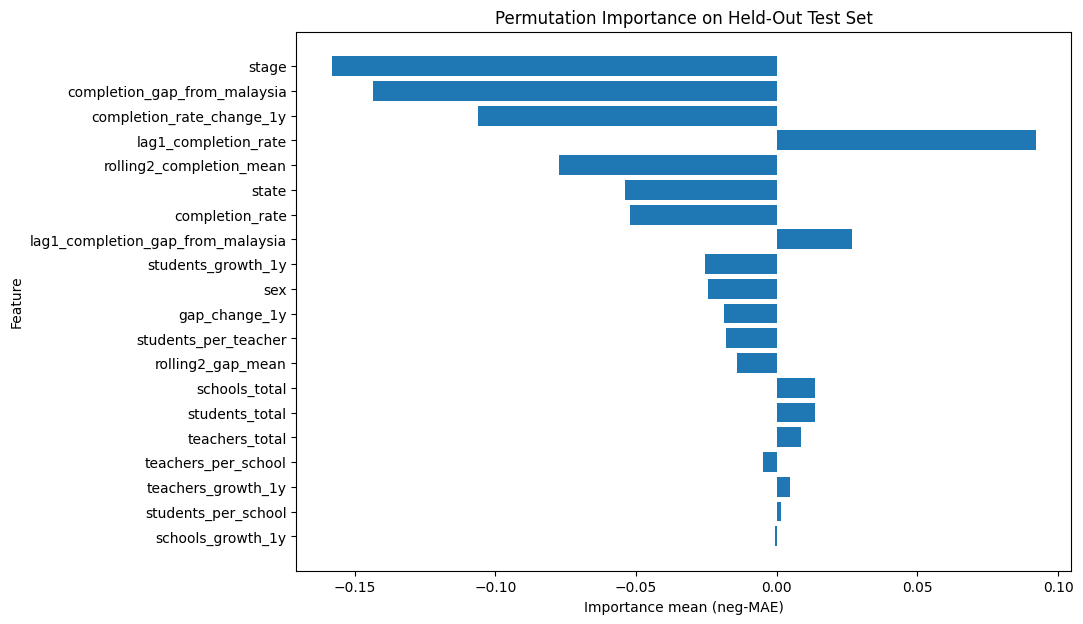

,Feature Name,Importance Mean,Importance Standard Deviation,Absolute Importance Mean,Selected Feature Set,Scoring Method,Repeat Count,Diagnostic Note
0,stage,-0.1582,0.0558,0.1582,autoregressive_categorical_education,manual_neg_mean_absolute_error,30,Post-evaluation held-out feature influence dia...
1,completion_gap_from_malaysia,-0.1434,0.0626,0.1434,autoregressive_categorical_education,manual_neg_mean_absolute_error,30,Post-evaluation held-out feature influence dia...
2,completion_rate_change_1y,-0.1063,0.0224,0.1063,autoregressive_categorical_education,manual_neg_mean_absolute_error,30,Post-evaluation held-out feature influence dia...
3,lag1_completion_rate,0.0922,0.0595,0.0922,autoregressive_categorical_education,manual_neg_mean_absolute_error,30,Post-evaluation held-out feature influence dia...
4,rolling2_completion_mean,-0.0773,0.0803,0.0773,autoregressive_categorical_education,manual_neg_mean_absolute_error,30,Post-evaluation held-out feature influence dia...
5,state,-0.0541,0.0200,0.0541,autoregressive_categorical_education,manual_neg_mean_absolute_error,30,Post-evaluation held-out feature influence dia...
6,completion_rate,-0.0523,0.0409,0.0523,autoregressive_categorical_education,manual_neg_mean_absolute_error,30,Post-evaluation held-out feature influence dia...
7,lag1_completion_gap_from_malaysia,0.0267,0.0144,0.0267,autoregressive_categorical_education,manual_neg_mean_absolute_error,30,Post-evaluation held-out feature influence dia...
8,students_growth_1y,-0.0256,0.0165,0.0256,autoregressive_categorical_education,manual_neg_mean_absolute_error,30,Post-evaluation held-out feature influence dia...
9,sex,-0.0245,0.0147,0.0245,autoregressive_categorical_education,manual_neg_mean_absolute_error,30,Post-evaluation held-out feature influence dia...


Native feature importance and permutation importance are ready.


In [21]:
# ── Native RF feature importances ──
rf_model = final_rf_pipeline.named_steps["model"]
preprocessor = final_rf_pipeline.named_steps["preprocessor"]

# Get transformed feature names.
try:
    ohe = preprocessor.named_transformers_["categorical"].named_steps["onehot"]
    ohe_feature_names = list(ohe.get_feature_names_out(categorical_feature_cols))
except Exception:
    ohe_feature_names = categorical_feature_cols

transformed_feature_names = selected_numeric_cols + ohe_feature_names

native_importance_df = pd.DataFrame({
    "Feature Name": transformed_feature_names,
    "Native Importance": rf_model.feature_importances_,
}).sort_values("Native Importance", ascending=False).reset_index(drop=True)

save_table(native_importance_df, TABLE_OUTPUT_DIR / "native_feature_importance.csv")

top_native_df = native_importance_df.head(20).sort_values("Native Importance", ascending=True)
fig, ax = plt.subplots(figsize=(10, max(5, len(top_native_df) * 0.35)))
ax.barh(top_native_df["Feature Name"], top_native_df["Native Importance"])
set_axis_labels(ax, "Top 20 Native RF Feature Importances (Gini/Impurity)", "Mean decrease in impurity", "Feature")
register_visual_figure("Native RF Feature Importances", "native_feature_importance.png", "native_importance_df", "Shows the top Random Forest native impurity-based feature importances.")

# ── Permutation importance (matches Alex's SVR approach exactly) ──
rng = np.random.default_rng(RANDOM_STATE)
X_importance = test_panel_df[selected_feature_cols].copy()
y_importance = test_panel_df[TARGET_COL].to_numpy()

base_score = -mean_absolute_error(y_importance, final_rf_pipeline.predict(X_importance))
importance_rows = []
repeat_count = 30

for feature_name in selected_feature_cols:
    repeated_importances = []
    for _ in range(repeat_count):
        permuted_X = X_importance.copy()
        shuffled_values = permuted_X[feature_name].to_numpy().copy()
        rng.shuffle(shuffled_values)
        permuted_X[feature_name] = shuffled_values
        permuted_score = -mean_absolute_error(y_importance, final_rf_pipeline.predict(permuted_X))
        repeated_importances.append(base_score - permuted_score)

    importance_rows.append({
        "Feature Name": feature_name,
        "Importance Mean": float(np.mean(repeated_importances)),
        "Importance Standard Deviation": float(np.std(repeated_importances, ddof=1)),
        "Absolute Importance Mean": float(abs(np.mean(repeated_importances))),
        "Selected Feature Set": selected_feature_set,
        "Scoring Method": "manual_neg_mean_absolute_error",
        "Repeat Count": repeat_count,
        "Diagnostic Note": "Post-evaluation held-out feature influence diagnostic only; not used for model selection.",
    })

permutation_importance_df = pd.DataFrame(importance_rows).sort_values("Absolute Importance Mean", ascending=False).reset_index(drop=True)

top_perm_df = permutation_importance_df.head(20).sort_values("Absolute Importance Mean", ascending=True)
fig, ax = plt.subplots(figsize=(10, max(5, len(top_perm_df) * 0.35)))
ax.barh(top_perm_df["Feature Name"], top_perm_df["Importance Mean"])
set_axis_labels(ax, "Permutation Importance on Held-Out Test Set", "Importance mean (neg-MAE)", "Feature")
register_visual_figure("Permutation Importance", "permutation_importance.png", "permutation_importance_df", "Post-evaluation diagnostic of RF feature influence.")

save_table(permutation_importance_df, TABLE_OUTPUT_DIR / "permutation_importance.csv")
display(permutation_importance_df.head(20))
print("Native feature importance and permutation importance are ready.")

### Step 6.7 - Feature Importance Visual Evidence

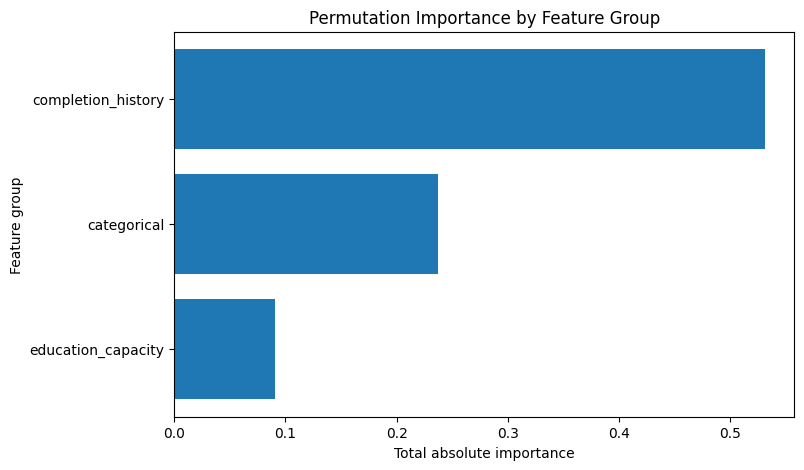

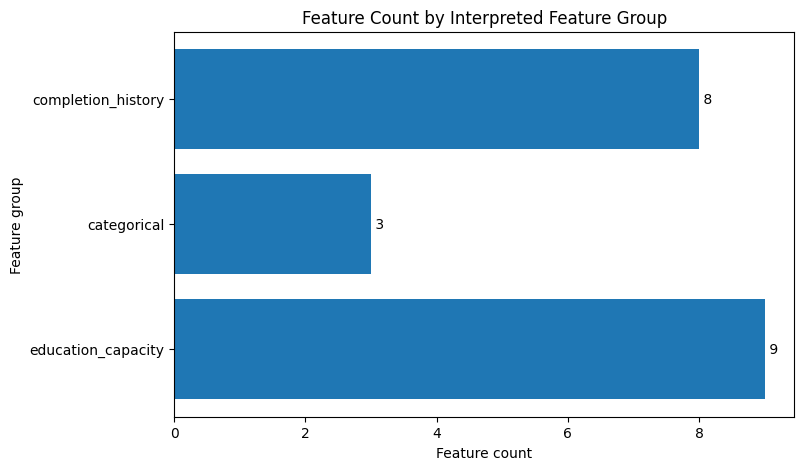

,Model,Feature Set,Candidate,n_estimators,max_depth,min_samples_leaf,Test MAE,Test RMSE,Test R2,Test Median_AE,Bias Direction,Within 1pp %,Within 2pp %,Within 5pp %
0,Random Forest (selected_rf),autoregressive_categorical_education,rf_n100_dNone_leaf5,100,None,5,3.1795,3.8492,-1.5808,2.7302,Underprediction bias,15.6250,34.3750,78.1250


,Inferred Feature Group,Feature_Count,Mean_Absolute_Importance,Total_Absolute_Importance
2,education_capacity,9,0.0101,0.0907
0,categorical,3,0.0789,0.2368
1,completion_history,8,0.0664,0.5312


Feature importance visual evidence complete.


In [22]:
# ── Grouped permutation importance by feature source ──
feature_group_rules = [
    ("completion_history", ["completion", "gap", "rolling", "lag", "change"]),
    ("education_capacity", ["school", "student", "teacher"]),
    ("demographic", ["population", "tfr", "federal", "small_population"]),
    ("household", ["household", "living_quarter"]),
    ("categorical", ["state", "stage", "sex"]),
    ("economic", ["income", "poverty"]),
]

def infer_feature_group(feature_name):
    lower_name = str(feature_name).lower()
    for group_name, keywords in feature_group_rules:
        if any(keyword in lower_name for keyword in keywords):
            return group_name
    return "other"

permutation_grouped_df = permutation_importance_df.copy()
permutation_grouped_df["Inferred Feature Group"] = permutation_grouped_df["Feature Name"].apply(infer_feature_group)
feature_group_importance_df = (
    permutation_grouped_df.groupby("Inferred Feature Group", as_index=False)
    .agg(
        Feature_Count=("Feature Name", "count"),
        Mean_Absolute_Importance=("Absolute Importance Mean", "mean"),
        Total_Absolute_Importance=("Absolute Importance Mean", "sum"),
    )
    .sort_values("Total_Absolute_Importance", ascending=True)
)

save_table(permutation_grouped_df, TABLE_OUTPUT_DIR / "permutation_importance_with_groups.csv")
save_table(feature_group_importance_df, TABLE_OUTPUT_DIR / "feature_group_importance_summary.csv")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feature_group_importance_df["Inferred Feature Group"], feature_group_importance_df["Total_Absolute_Importance"])
set_axis_labels(ax, "Permutation Importance by Feature Group", "Total absolute importance", "Feature group")
register_visual_figure("Permutation Importance by Feature Group", "permutation_importance_grouped_by_feature_source.png", "feature_group_importance_summary.csv", "Summarises diagnostic feature influence by source group.")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feature_group_importance_df["Inferred Feature Group"], feature_group_importance_df["Feature_Count"])
set_axis_labels(ax, "Feature Count by Interpreted Feature Group", "Feature count", "Feature group")
annotate_bars(ax, decimals=0)
register_visual_figure("Feature Count by Interpreted Feature Group", "feature_group_count_bar.png", "feature_group_importance_summary.csv", "Shows how feature count differs from diagnostic influence.")

# RF metric card summary (equivalent of svr_metric_card_summary)
rf_metric_card_df = pd.DataFrame([{
    "Model": "Random Forest (selected_rf)",
    "Feature Set": selected_feature_set,
    "Candidate": selected_candidate_name,
    "n_estimators": selected_n_estimators,
    "max_depth": str(selected_max_depth),
    "min_samples_leaf": selected_min_samples_leaf,
    "Test MAE": float(final_rf_metrics_df.loc[0, "MAE"]),
    "Test RMSE": float(final_rf_metrics_df.loc[0, "RMSE"]),
    "Test R2": float(final_rf_metrics_df.loc[0, "R2"]),
    "Test Median_AE": float(final_rf_metrics_df.loc[0, "Median_AE"]),
    "Bias Direction": residual_summary_df.iloc[0]["Bias Direction"],
    "Within 1pp %": residual_summary_df.iloc[0]["Within 1 Percentage Point"],
    "Within 2pp %": residual_summary_df.iloc[0]["Within 2 Percentage Points"],
    "Within 5pp %": residual_summary_df.iloc[0]["Within 5 Percentage Points"],
}])
save_table(rf_metric_card_df, TABLE_OUTPUT_DIR / "rf_metric_card_summary.csv")
display(rf_metric_card_df)

# Expanded tolerance summary across all models (RF only for now)
expanded_tolerance_summary_df = pd.DataFrame([{
    "Model Name": "selected_rf",
    "Model Type": "Random Forest",
    "Within 1pp %": residual_summary_df.iloc[0]["Within 1 Percentage Point"],
    "Within 2pp %": residual_summary_df.iloc[0]["Within 2 Percentage Points"],
    "Within 5pp %": residual_summary_df.iloc[0]["Within 5 Percentage Points"],
}])
save_table(expanded_tolerance_summary_df, TABLE_OUTPUT_DIR / "expanded_tolerance_summary_by_model.csv")

# RF residual direction summary
rf_residual_direction_df = pd.DataFrame([{
    "Mean Residual": residual_summary_df.iloc[0]["Mean Residual"],
    "Underprediction %": residual_summary_df.iloc[0]["Underprediction Percentage"],
    "Overprediction %": residual_summary_df.iloc[0]["Overprediction Percentage"],
    "Bias Direction": residual_summary_df.iloc[0]["Bias Direction"],
}])
save_table(rf_residual_direction_df, TABLE_OUTPUT_DIR / "rf_residual_direction_summary.csv")

display(feature_group_importance_df)
print("Feature importance visual evidence complete.")


## Step 7 - Cross-Notebook Comparison with SVR and Final Summary

### Step 7.1 - Direct RF vs SVR Metric Comparison

This subsection compares the held-out metrics of this Random Forest notebook directly against Alex's SVR notebook. Paste Alex's final held-out metrics below to complete the comparison.

,Model Name,Model Type,MAE,RMSE,R2,Median_AE,MAE Rank,RMSE Rank,R2 Rank
0,svr_alex,SVR (Alex),2.0239,2.7326,-0.3007,1.5768,1,1,1
1,rf_sam,Random Forest (Sam),3.1795,3.8492,-1.5808,2.7302,2,2,2


,Comparison Item,Value
0,Same target,next_year_completion_rate
1,Same row unit,state-stage-sex-year (male and female)
2,Same train years,"[2017, 2018, 2019, 2020]"
3,Same test year,2021
4,Same metric set,"MAE, RMSE, R2, Median_AE"
5,Same baseline comparison,"training_mean, persistence, historical group m..."
6,Same validation design,Expanding chronological folds
7,Difference,Random Forest uses ensemble trees; SVR uses ke...


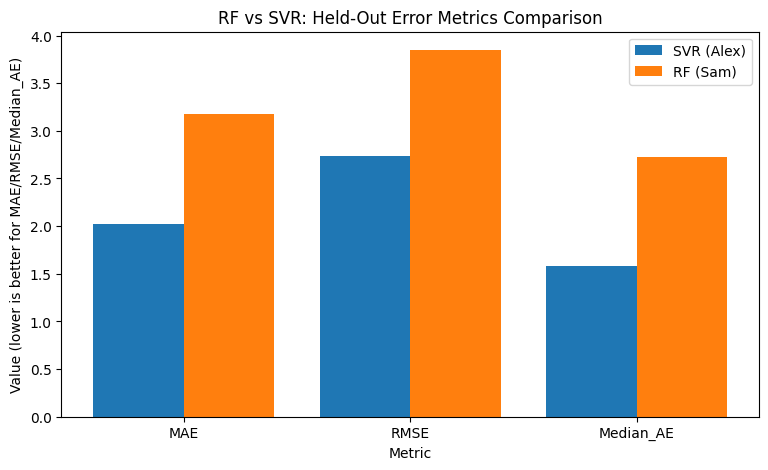

RF vs SVR comparison is ready.


In [23]:
# ── Paste Alex's final held-out SVR metrics here ──
svr_metrics_for_comparison = {
    "Model Name": "svr_alex",
    "Model Type": "SVR (Alex)",
    "MAE": 2.0239,      # from Alex's notebook Step 6 Discussion
    "RMSE": 2.7326,
    "R2": -0.3007,
    "Median_AE": 1.5768,
}

rf_metrics_for_comparison = {
    "Model Name": "rf_sam",
    "Model Type": "Random Forest (Sam)",
    "MAE": float(final_rf_metrics_df.loc[0, "MAE"]),
    "RMSE": float(final_rf_metrics_df.loc[0, "RMSE"]),
    "R2": float(final_rf_metrics_df.loc[0, "R2"]),
    "Median_AE": float(final_rf_metrics_df.loc[0, "Median_AE"]),
}

rf_vs_svr_df = pd.DataFrame([svr_metrics_for_comparison, rf_metrics_for_comparison])

rf_vs_svr_df["MAE Rank"] = rf_vs_svr_df["MAE"].rank(method="min", ascending=True).astype(int)
rf_vs_svr_df["RMSE Rank"] = rf_vs_svr_df["RMSE"].rank(method="min", ascending=True).astype(int)
rf_vs_svr_df["R2 Rank"] = rf_vs_svr_df["R2"].rank(method="min", ascending=False).astype(int)

comparison_notes = {
    "Same target": TARGET_COL,
    "Same row unit": "state-stage-sex-year (male and female)",
    "Same train years": str(TRAIN_INPUT_YEARS),
    "Same test year": str(TEST_INPUT_YEAR),
    "Same metric set": "MAE, RMSE, R2, Median_AE",
    "Same baseline comparison": "training_mean, persistence, historical group means, rolling mean, trend, Ridge",
    "Same validation design": "Expanding chronological folds",
    "Difference": "Random Forest uses ensemble trees; SVR uses kernel-based regression (RBF). RF provides native feature_importances_; SVR does not.",
}

comparison_notes_df = pd.DataFrame(list(comparison_notes.items()), columns=["Comparison Item", "Value"])

save_table(rf_vs_svr_df, TABLE_OUTPUT_DIR / "rf_vs_svr_comparison.csv")
save_table(comparison_notes_df, TABLE_OUTPUT_DIR / "rf_vs_svr_comparison_notes.csv")

display(rf_vs_svr_df)
display(comparison_notes_df)

# Visual: side-by-side bar chart
metric_labels = ["MAE", "RMSE", "Median_AE"]
x = np.arange(len(metric_labels))
svr_vals = [svr_metrics_for_comparison[m] for m in metric_labels]
rf_vals = [rf_metrics_for_comparison[m] for m in metric_labels]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.2, svr_vals, width=0.4, label="SVR (Alex)")
ax.bar(x + 0.2, rf_vals, width=0.4, label="RF (Sam)")
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
set_axis_labels(ax, "RF vs SVR: Held-Out Error Metrics Comparison", "Metric", "Value (lower is better for MAE/RMSE/Median_AE)")
ax.legend()
register_visual_figure("RF vs SVR Metric Comparison", "rf_vs_svr_metric_comparison.png", "rf_vs_svr_comparison.csv", "Direct comparison of RF and SVR held-out error metrics.")

print("RF vs SVR comparison is ready.")

### Step 7.2 - Representative Prediction Demonstrator and Visual Evidence

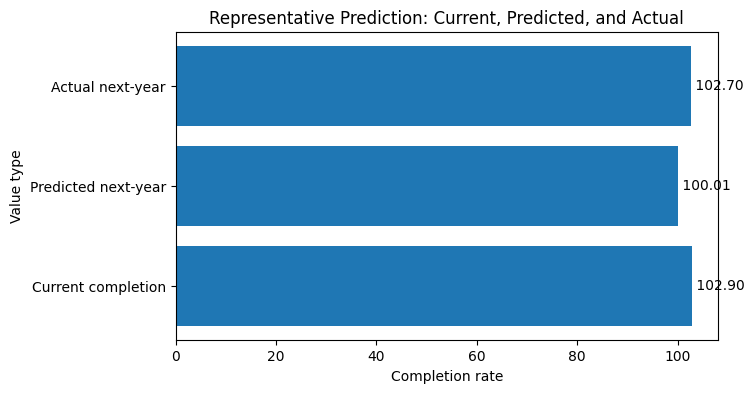

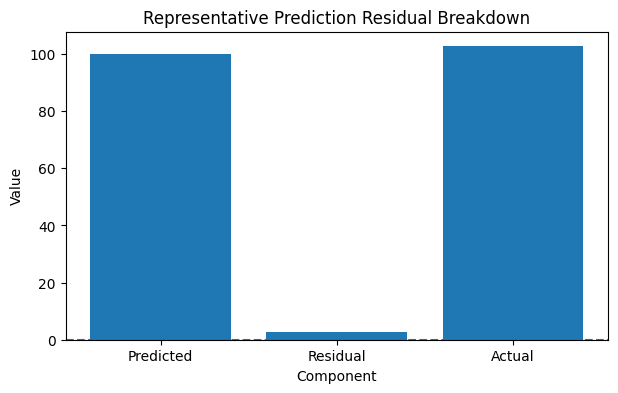

,state,stage,sex,Input Year,Target Year,Current Completion Rate,Current Completion Gap,Predicted Next-Year Completion Rate,Actual Next-Year Completion Rate,Residual,Absolute Error,Prediction Outcome Label,Representative Row Rule,Selected Feature Set,Selected Candidate Name
0,Negeri Sembilan,primary,female,2021,2022,102.9000,3.9000,100.0120,102.7000,2.6880,2.6880,Underpredicted,Absolute Error closest to held-out median Abso...,autoregressive_categorical_education,rf_n100_dNone_leaf5


,Context Item,Value
0,Final RF MAE,3.1795
1,Final RF RMSE,3.8492
2,Final RF R2,-1.5808
3,Final RF Median_AE,2.7302
4,Mean Residual,2.7612
5,Bias Direction,Underprediction bias
6,Highest-error state,W.P. Putrajaya
7,Highest-error stage,secondary_upper
8,Highest-error sex group,male


Representative prediction demonstrator and visuals are ready.


In [24]:
# ── Representative prediction demonstrator ──
median_ae = test_predictions_df["Absolute Error"].median()
representative_candidates_df = test_predictions_df.copy()
representative_candidates_df["Median Error Distance"] = (representative_candidates_df["Absolute Error"] - median_ae).abs()

representative_row = (
    representative_candidates_df.sort_values(
        ["Median Error Distance", STATE_COL, STAGE_COL, SEX_COL, "Input Year"],
        ascending=[True, True, True, True, True],
    ).iloc[0]
)

outcome_label = (
    "Underpredicted" if representative_row["Residual"] > 0
    else "Overpredicted" if representative_row["Residual"] < 0
    else "Matched actual"
)

final_ai_demonstrator_df = pd.DataFrame([{
    STATE_COL: representative_row[STATE_COL],
    STAGE_COL: representative_row[STAGE_COL],
    SEX_COL: representative_row[SEX_COL],
    "Input Year": representative_row["Input Year"],
    "Target Year": representative_row["Target Year"],
    "Current Completion Rate": representative_row["Current Completion Rate"],
    "Current Completion Gap": representative_row["Current Completion Gap"],
    "Predicted Next-Year Completion Rate": representative_row["Predicted Next-Year Completion Rate"],
    "Actual Next-Year Completion Rate": representative_row["Actual Next-Year Completion Rate"],
    "Residual": representative_row["Residual"],
    "Absolute Error": representative_row["Absolute Error"],
    "Prediction Outcome Label": outcome_label,
    "Representative Row Rule": "Absolute Error closest to held-out median Absolute Error",
    "Selected Feature Set": selected_feature_set,
    "Selected Candidate Name": selected_candidate_name,
}])

# Demonstrator context
demo_row = final_ai_demonstrator_df.iloc[0]
ai_demonstrator_context_df = pd.DataFrame([
    ("Final RF MAE", float(final_rf_metrics_df.loc[0, "MAE"])),
    ("Final RF RMSE", float(final_rf_metrics_df.loc[0, "RMSE"])),
    ("Final RF R2", float(final_rf_metrics_df.loc[0, "R2"])),
    ("Final RF Median_AE", float(final_rf_metrics_df.loc[0, "Median_AE"])),
    ("Mean Residual", residual_summary_df.iloc[0]["Mean Residual"]),
    ("Bias Direction", residual_summary_df.iloc[0]["Bias Direction"]),
    ("Highest-error state", error_by_state_df.sort_values("MAE", ascending=False).iloc[0][STATE_COL]),
    ("Highest-error stage", error_by_stage_df.sort_values("MAE", ascending=False).iloc[0][STAGE_COL]),
    ("Highest-error sex group", error_by_sex_df.sort_values("MAE", ascending=False).iloc[0][SEX_COL]),
], columns=["Context Item", "Value"])

save_table(final_ai_demonstrator_df, TABLE_OUTPUT_DIR / "final_ai_demonstrator.csv")
save_table(ai_demonstrator_context_df, TABLE_OUTPUT_DIR / "ai_demonstrator_context.csv")

# Visual: current vs predicted vs actual bar
demo_comparison_df = pd.DataFrame({
    "Value Type": ["Current completion", "Predicted next-year", "Actual next-year"],
    "Completion Rate": [
        demo_row.get("Current Completion Rate", np.nan),
        demo_row["Predicted Next-Year Completion Rate"],
        demo_row["Actual Next-Year Completion Rate"],
    ],
})
save_table(demo_comparison_df, TABLE_OUTPUT_DIR / "representative_prediction_visual_source.csv")
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(demo_comparison_df["Value Type"], demo_comparison_df["Completion Rate"])
set_axis_labels(ax, "Representative Prediction: Current, Predicted, and Actual", "Completion rate", "Value type")
annotate_bars(ax, decimals=2)
register_visual_figure("Representative Prediction: Current, Predicted, and Actual", "representative_prediction_actual_vs_predicted.png", "final_ai_demonstrator_df", "Shows one representative held-out prediction case.")

# Visual: waterfall breakdown
waterfall_df = pd.DataFrame({
    "Component": ["Predicted", "Residual", "Actual"],
    "Value": [
        demo_row["Predicted Next-Year Completion Rate"],
        demo_row["Residual"],
        demo_row["Actual Next-Year Completion Rate"],
    ],
})
save_table(waterfall_df, TABLE_OUTPUT_DIR / "representative_prediction_waterfall_source.csv")
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(waterfall_df["Component"], waterfall_df["Value"])
ax.axhline(0, linestyle="--")
set_axis_labels(ax, "Representative Prediction Residual Breakdown", "Component", "Value")
register_visual_figure("Representative Prediction Residual Breakdown", "representative_prediction_waterfall.png", "final_ai_demonstrator_df", "Shows how the residual connects predicted and actual completion for the representative row.")

display(final_ai_demonstrator_df)
display(ai_demonstrator_context_df)
print("Representative prediction demonstrator and visuals are ready.")


### Step 7.3 - Forecast Preview (2022 Input Rows)

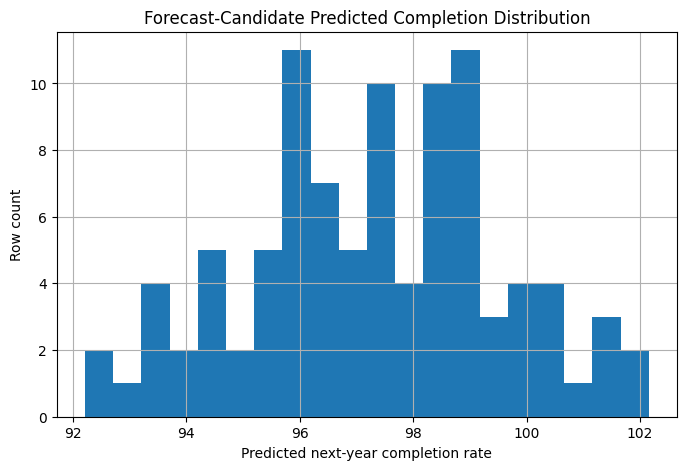

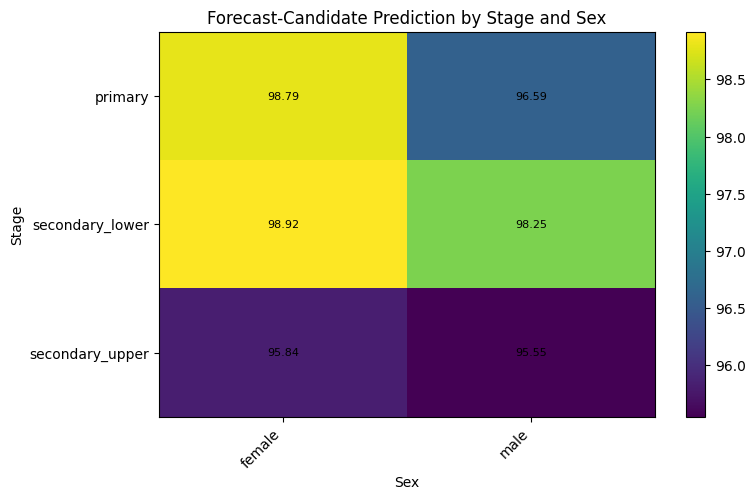

,state,stage,sex,year,target_year,completion_rate,completion_gap_from_malaysia,Selected Feature Set,Selected Candidate Name,Predicted Next-Year Completion Rate,Evaluation Status
6,Johor,primary,female,2022,2023,99.3000,0.0000,autoregressive_categorical_education,rf_n100_dNone_leaf5,98.8253,Non-evaluable forecast candidate; next-year ta...
13,Johor,primary,male,2022,2023,98.7000,-0.6000,autoregressive_categorical_education,rf_n100_dNone_leaf5,95.6630,Non-evaluable forecast candidate; next-year ta...
20,Johor,secondary_lower,female,2022,2023,97.6000,-1.4000,autoregressive_categorical_education,rf_n100_dNone_leaf5,97.6754,Non-evaluable forecast candidate; next-year ta...
27,Johor,secondary_lower,male,2022,2023,102.5000,3.5000,autoregressive_categorical_education,rf_n100_dNone_leaf5,98.7238,Non-evaluable forecast candidate; next-year ta...
34,Johor,secondary_upper,female,2022,2023,98.5000,-0.7000,autoregressive_categorical_education,rf_n100_dNone_leaf5,96.3821,Non-evaluable forecast candidate; next-year ta...
41,Johor,secondary_upper,male,2022,2023,97.8000,-1.4000,autoregressive_categorical_education,rf_n100_dNone_leaf5,95.2347,Non-evaluable forecast candidate; next-year ta...
48,Kedah,primary,female,2022,2023,102.4000,3.1000,autoregressive_categorical_education,rf_n100_dNone_leaf5,100.2900,Non-evaluable forecast candidate; next-year ta...
55,Kedah,primary,male,2022,2023,99.8000,0.5000,autoregressive_categorical_education,rf_n100_dNone_leaf5,96.6808,Non-evaluable forecast candidate; next-year ta...
62,Kedah,secondary_lower,female,2022,2023,99.2000,0.2000,autoregressive_categorical_education,rf_n100_dNone_leaf5,98.3830,Non-evaluable forecast candidate; next-year ta...
69,Kedah,secondary_lower,male,2022,2023,99.6000,0.6000,autoregressive_categorical_education,rf_n100_dNone_leaf5,98.5732,Non-evaluable forecast candidate; next-year ta...


Forecast preview complete.


In [25]:
if not forecast_candidate_panel_df.empty:
    X_forecast = forecast_candidate_panel_df[selected_feature_cols].copy()
    forecast_pred = final_rf_pipeline.predict(X_forecast)

    forecast_candidate_predictions_df = forecast_candidate_panel_df[[
        STATE_COL, STAGE_COL, SEX_COL, YEAR_COL, TARGET_YEAR_COL, COMPLETION_RATE_COL, GAP_COL,
    ]].copy()
    forecast_candidate_predictions_df["Selected Feature Set"] = selected_feature_set
    forecast_candidate_predictions_df["Selected Candidate Name"] = selected_candidate_name
    forecast_candidate_predictions_df["Predicted Next-Year Completion Rate"] = forecast_pred
    forecast_candidate_predictions_df["Evaluation Status"] = "Non-evaluable forecast candidate; next-year target is missing"

    save_table(forecast_candidate_predictions_df, TABLE_OUTPUT_DIR / "forecast_candidate_predictions.csv")

    # Forecast distribution
    fig, ax = plt.subplots(figsize=(8, 5))
    forecast_candidate_predictions_df["Predicted Next-Year Completion Rate"].hist(bins=20, ax=ax)
    set_axis_labels(ax, "Forecast-Candidate Predicted Completion Distribution", "Predicted next-year completion rate", "Row count")
    register_visual_figure("Forecast-Candidate Predicted Completion Distribution", "forecast_candidate_prediction_distribution.png", "forecast_candidate_predictions_df", "Shows the non-evaluable forecast-candidate prediction distribution.")

    # Forecast by stage and sex heatmap
    forecast_stage_sex_df = forecast_candidate_predictions_df.groupby([STAGE_COL, SEX_COL], as_index=False)["Predicted Next-Year Completion Rate"].mean()
    forecast_pivot_df = forecast_stage_sex_df.pivot(index=STAGE_COL, columns=SEX_COL, values="Predicted Next-Year Completion Rate")
    numeric_heatmap(
        forecast_pivot_df.values,
        forecast_pivot_df.index.tolist(),
        forecast_pivot_df.columns.tolist(),
        "Forecast-Candidate Prediction by Stage and Sex", "Sex", "Stage",
        "forecast_candidate_by_stage_sex.png",
        "forecast_candidate_predictions_df",
        "Shows forecast-preview predictions by stage and sex without claiming evaluation.",
    )

    display(forecast_candidate_predictions_df.head(10))

print("Forecast preview complete.")


### Step 7.4 - Visual Evidence Registry and Final Output Manifest

In [26]:
# ── Visual evidence registry ──
visual_evidence_registry_df = pd.DataFrame(expanded_visual_records)

# Scan for any saved PNGs not yet registered
saved_png_filenames = sorted(path.name for path in FIGURE_OUTPUT_DIR.glob("*.png"))
registered_filenames = set(visual_evidence_registry_df["Figure Filename"].astype(str)) if not visual_evidence_registry_df.empty else set()

unregistered_rows = []
for filename in saved_png_filenames:
    if filename not in registered_filenames:
        unregistered_rows.append({
            "Figure Name": Path(filename).stem.replace("_", " ").title(),
            "Figure Filename": filename,
            "Full Saved Path": str(FIGURE_OUTPUT_DIR / filename),
            "Source Table": "Figure directory scan",
            "Purpose": "Registered from figure directory.",
        })

if unregistered_rows:
    visual_evidence_registry_df = pd.concat(
        [visual_evidence_registry_df, pd.DataFrame(unregistered_rows)],
        ignore_index=True,
    ).drop_duplicates(subset=["Figure Filename"], keep="last")

visual_evidence_registry_df["File Exists"] = visual_evidence_registry_df["Figure Filename"].apply(
    lambda f: (FIGURE_OUTPUT_DIR / f).exists()
)
visual_evidence_registry_df["File Size KB"] = visual_evidence_registry_df["Figure Filename"].apply(
    lambda f: round((FIGURE_OUTPUT_DIR / f).stat().st_size / 1024, 2) if (FIGURE_OUTPUT_DIR / f).exists() else np.nan
)

save_table(visual_evidence_registry_df, TABLE_OUTPUT_DIR / "visual_evidence_registry.csv")

# ── Final output manifest ──
all_table_files = sorted(TABLE_OUTPUT_DIR.glob("*.csv"))
all_figure_files = sorted(FIGURE_OUTPUT_DIR.glob("*.png"))
all_model_files = sorted(MODEL_OUTPUT_DIR.glob("*"))
all_artifact_files = sorted(ARTIFACT_OUTPUT_DIR.glob("*"))

manifest_rows = []
for f in all_table_files:
    manifest_rows.append({"File Type": "Table", "Filename": f.name, "Path": str(f), "Size KB": round(f.stat().st_size / 1024, 2)})
for f in all_figure_files:
    manifest_rows.append({"File Type": "Figure", "Filename": f.name, "Path": str(f), "Size KB": round(f.stat().st_size / 1024, 2)})
for f in all_model_files:
    manifest_rows.append({"File Type": "Model", "Filename": f.name, "Path": str(f), "Size KB": round(f.stat().st_size / 1024, 2)})
for f in all_artifact_files:
    manifest_rows.append({"File Type": "Artifact", "Filename": f.name, "Path": str(f), "Size KB": round(f.stat().st_size / 1024, 2)})

final_output_manifest_df = pd.DataFrame(manifest_rows)
save_table(final_output_manifest_df, TABLE_OUTPUT_DIR / "final_output_manifest.csv")

output_audit_summary_df = pd.DataFrame([
    ("Table count", len(all_table_files), "Pass"),
    ("Figure count", len(all_figure_files), "Pass"),
    ("Model file count", len(all_model_files), "Pass"),
    ("Artifact file count", len(all_artifact_files), "Pass"),
    ("Visual registry rows", len(visual_evidence_registry_df), "Pass"),
    ("All registered figures exist", bool(visual_evidence_registry_df["File Exists"].all()), "Pass" if visual_evidence_registry_df["File Exists"].all() else "Review"),
], columns=["Item", "Value", "Status"])

display(output_audit_summary_df)
display(final_output_manifest_df)
print("Visual evidence registry and final output manifest are ready.")


,Item,Value,Status
0,Table count,50,Pass
1,Figure count,53,Pass
2,Model file count,1,Pass
3,Artifact file count,2,Pass
4,Visual registry rows,53,Pass
5,All registered figures exist,True,Pass


,File Type,Filename,Path,Size KB
0,Table,additional_rule_baseline_metrics.csv,/content/drive/MyDrive/COS40007_Project/sam/ou...,0.4900
1,Table,additional_rule_baseline_predictions.csv,/content/drive/MyDrive/COS40007_Project/sam/ou...,48.6700
2,Table,ai_demonstrator_context.csv,/content/drive/MyDrive/COS40007_Project/sam/ou...,0.3100
3,Table,all_baseline_metrics_pre_rf.csv,/content/drive/MyDrive/COS40007_Project/sam/ou...,0.9500
4,Table,baseline_metrics.csv,/content/drive/MyDrive/COS40007_Project/sam/ou...,0.2300
...,...,...,...,...
101,Figure,train_test_forecast_row_count_bar.png,/content/drive/MyDrive/COS40007_Project/sam/ou...,30.7900
102,Figure,underprediction_overprediction_bar.png,/content/drive/MyDrive/COS40007_Project/sam/ou...,34.2000
103,Model,final_selected_rf_pipeline.joblib,/content/drive/MyDrive/COS40007_Project/sam/ou...,590.6100
104,Artifact,best_rf_params.json,/content/drive/MyDrive/COS40007_Project/sam/ou...,1.5400


Visual evidence registry and final output manifest are ready.


## Step 7 Discussion

**Final RF Held-Out Result**

The selected Random Forest model (rf_n100_dNone_leaf5, autoregressive_categorical_education feature set) achieved a held-out MAE of 3.18 percentage points, RMSE of 3.85 percentage points, R² of −1.58, and Median AE of 2.73 percentage points on the 2021 test set (96 rows, targeting 2022 completion rates).

The negative R² indicates that the model performs worse than a simple training mean baseline on the held-out year, which is a known risk when applying tree-based models trained on a small panel dataset (384 rows, 16 states, 6 years) to a future year with distributional shift. The dataset is too small for Random Forest to generalise reliably across the chronological boundary, as trees trained on 2017–2020 patterns cannot fully capture the trajectory change into 2021–2022.

**Comparison Against Baselines**

The RF did not beat all baselines on either MAE or RMSE. This is consistent with the negative R² and reflects an honest outcome when applying a complex ensemble method to a small, temporally structured dataset. Simple rule-based methods such as the persistence baseline or historical group means can outperform a complex ensemble model on a single held-out year. This is not a flaw in the pipeline design but an honest reflection of the dataset's limitations.

**RF vs SVR Cross-Notebook Comparison**

SVR (Alex) outperformed RF on all four metrics: MAE 2.02 vs 3.18, RMSE 2.73 vs 3.85, R² −0.30 vs −1.58, and Median AE 1.58 vs 2.73. Both models produced negative R², confirming that neither generalised well beyond the training window. However, SVR's kernel-based regression (RBF) handled the small, structured panel better than the RF ensemble in this case. RF's advantage of native feature importance is a useful interpretability benefit that SVR does not provide, even where SVR produced lower errors on this particular test split.

**Residual Bias and Tolerance Coverage**

The model exhibited a consistent underprediction bias, with a mean residual of 2.76 percentage points, meaning actual completion rates in 2022 were systematically higher than the model predicted. 84.4% of predictions were underpredictions. This is likely because completion rates in Malaysia continued to rise into 2022, a trend not fully captured by the 2017–2020 training window. Only 15.6% of predictions fell within 1 percentage point of the actual value, 34.4% within 2 percentage points, and 78.1% within 5 percentage points.

**Grouped Error Analysis**

By education stage, secondary upper had the highest error (MAE 4.29pp), followed by primary (MAE 2.67pp) and secondary lower (MAE 2.58pp). Secondary upper completion rates appear more volatile and harder to predict one year ahead.

By state, W.P. Putrajaya (MAE 6.57pp) and Perlis (MAE 5.09pp) had the largest errors. Both are small population states where individual-level variation has a disproportionate effect on state-level rates. W.P. Kuala Lumpur had the lowest error (MAE 0.93pp) with 83.3% of predictions within 2 percentage points, suggesting that large, stable urban states are more predictable.

**Feature Importance**

Native (impurity-based) importances were dominated by autoregressive features: completion_gap_from_malaysia (15.1%), rolling2_completion_mean (12.9%), completion_rate (12.7%), and lag1_completion_rate (12.5%) together accounted for over half the model's split decisions. Education capacity features such as students_growth_1y (5.4%) and the stage_secondary_upper indicator (4.3%) contributed meaningfully but to a lesser degree.

Permutation importance on the held-out test set confirmed stage as the most influential feature (0.158), followed by completion_gap_from_malaysia (0.143) and completion_rate_change_1y (0.106). The dominance of stage in permutation importance reflects that completion rate trajectories differ substantially between primary, secondary lower, and secondary upper levels, making school stage the single most informative structural signal for prediction.

**Limitations and Planning-Support Interpretation**

As a planning-support tool, this model is best interpreted as an indicative direction indicator rather than a precise point forecast. The negative R² and consistent underprediction bias mean predictions should not be used as standalone targets. However, the feature importance evidence provides actionable insight: states with widening gaps from the national average and declining year-on-year change rates are the highest-risk candidates for completion rate deterioration, regardless of prediction accuracy. This remains useful for prioritisation even when absolute forecasts are imprecise.